In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyref.fitting as fit
from cycler import cycler
from scienceplots import scienceplots

from utils import read_ooc, read_xrr
from utils.helpers.plotting_helper import set_plotting_defaults
from utils.profile_slab import OrientationProfile

CPU_COUNT = os.cpu_count()
set_plotting_defaults()

ooc = read_ooc("dft.csv", material="znpc")

# Load the Data Files


(<Axes: ylabel='$R$'>, <Axes: xlabel='$q (\\AA^{-1})$'>)

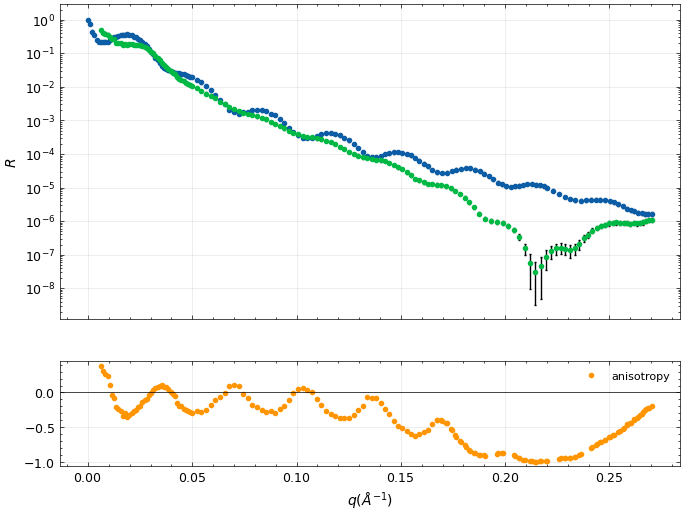

In [2]:
loaded_data = read_xrr("reflectivity_data", material="znpc")
loaded_data["283.7"].plot(label="283.7 eV data")

In [3]:
ens = [float(k) for k in loaded_data.keys()]
ens.sort()
ens

[250.0,
 275.0,
 280.0,
 281.0,
 281.2,
 281.4,
 281.6,
 281.8,
 282.0,
 282.3,
 282.5,
 282.7,
 282.9,
 283.1,
 283.3,
 283.5,
 283.7,
 284.2,
 285.1,
 287.0,
 289.0]

In [4]:
loaded_data

{'282.9': ReflectDataset(data=(array([0.0031227 , 0.00417354, 0.00521432, 0.00625503, 0.00729566,
        0.00833619, 0.00938662, 0.01042691, 0.01146707, 0.01250708,
        0.01354693, 0.01458659, 0.01562607, 0.01667533, 0.01771437,
        0.01875318, 0.01979175, 0.02083005, 0.02187806, 0.0229158 ,
        0.02395324, 0.02499036, 0.02602715, 0.0270636 , 0.02809969,
        0.02914537, 0.0301807 , 0.03121564, 0.03225016, 0.03328426,
        0.03432786, 0.03536107, 0.0363938 , 0.03742606, 0.03845783,
        0.03948909, 0.04051983, 0.04155993, 0.04258958, 0.04361867,
        0.04464719, 0.04567512, 0.04671232, 0.04773902, 0.04876509,
        0.04979052, 0.05202643, 0.05426889, 0.05649811, 0.05872378,
        0.06094576, 0.06317367, 0.06538785, 0.06759791, 0.06980373,
        0.07201486, 0.07421176, 0.0031227 , 0.00417354, 0.00521432,
        0.00625503, 0.00729566, 0.00833494, 0.00833619, 0.00938537,
        0.00938662, 0.01042566, 0.01042691, 0.01146582, 0.01146707,
        0.01250583

In [5]:
import pickle

from utils import models_root

with open(models_root / "xrr/znpc/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constrained = pickle.load(f)
with open(models_root / "xrr/znpc/free/free_en_offset_init_2.pkl", "rb") as f:
    exp_constrained = pickle.load(f)

In [6]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils.helpers.fitting_helper import reduced_chi2


def rxr(x, model, pol):
    _pol = model.pol
    model.pol = pol
    y = model(x)
    model.pol = _pol
    return y


def anisotropy(x, model):
    r_s = rxr(x, model, "s")
    r_p = rxr(x, model, "p")
    return (r_p - r_s) / (r_p + r_s)


In [7]:
import numpy as np
from scipy.interpolate import Akima1DInterpolator


def collapse_q_clusters(
    q,
    y,
    dq_tol: float = 1e-4,
):
    """
    Merge reflectivity samples whose q values differ by less than ``dq_tol``.

    Cubic interpolators treat micro-spaced pairs (dq ~ 1e-6, different R) as
    near-vertical jumps and ring on a dense evaluation grid. Binning at 1e-4
    preserves experimental resolution while removing that artifact.
    """
    q_arr = np.asarray(q, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    order = np.argsort(q_arr)
    q_arr = q_arr[order]
    y_arr = y_arr[order]

    q_out: list[float] = [float(q_arr[0])]
    y_out: list[float] = [float(y_arr[0])]
    n_in_cluster = 1

    for i in range(1, q_arr.size):
        if q_arr[i] - q_out[-1] < dq_tol:
            y_out[-1] += float(y_arr[i])
            n_in_cluster += 1
        else:
            if n_in_cluster > 1:
                y_out[-1] /= n_in_cluster
            q_out.append(float(q_arr[i]))
            y_out.append(float(y_arr[i]))
            n_in_cluster = 1

    if n_in_cluster > 1:
        y_out[-1] /= n_in_cluster

    return np.asarray(q_out, dtype=np.float64), np.asarray(y_out, dtype=np.float64)


def interp_reflectivity_makima(q, y, q_grid, *, dq_tol: float = 1e-4, log_space: bool = True):
    """
    MAKima interpolation on a collapsed q axis; optional log(R) domain.
    """
    q_c, y_c = collapse_q_clusters(q, y, dq_tol=dq_tol)
    if log_space:
        y_c = np.log(np.clip(y_c, 1e-30, None))
    interpolator = Akima1DInterpolator(q_c, y_c, method="makima", extrapolate=False)
    out = np.asarray(interpolator(q_grid), dtype=np.float64)
    if log_space:
        out = np.exp(out)
    return out


def theta(q, e):
    lam = 12.3984197 / e
    return np.arcsin(q * lam / 4 / np.pi)


q_min = -np.inf
q_max = np.inf
npnts = 0
for ds in loaded_data.values():
    for pol in ["s", "p"]:
        pol_data = getattr(ds, pol)
        q_min = max(q_min, pol_data.x.min())
        q_max = min(q_max, pol_data.x.max())
        npnts = max(npnts, len(pol_data.x))

common_q = np.linspace(q_min, q_max, 1000)
energies = sorted(float(k) for k in loaded_data if float(k) <= 283.7)
s_grid = np.zeros((len(common_q), len(energies)))
p_grid = np.zeros_like(s_grid)

for i, E in enumerate(energies):
    ds = loaded_data[str(E)]
    s_grid[:, i] = interp_reflectivity_makima(ds.s.x, ds.s.y, common_q)
    p_grid[:, i] = interp_reflectivity_makima(ds.p.x, ds.p.y, common_q)

a_grid = (p_grid - s_grid) / (p_grid + s_grid)

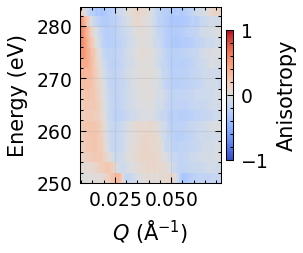

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes
from matplotlib.cm import ScalarMappable


def plot_q_energy_map(
    ax: Axes,
    grid,
    q,
    energies,
    *,
    diverging: bool = True,
    cmap: str | None = None,
    vmin: float | None = None,
    vmax: float | None = None,
    cbar: bool = True,
    cbar_label: str | None = None,
) -> ScalarMappable:
    """
    Draw a q (x) vs energy (y) heatmap on ``ax``.

    Parameters
    ----------
    ax
        Target matplotlib axes.
    grid
        Array with shape ``(len(q), len(energies))`` as built by the interpolation
        cells above.
    q
        Common q grid in inverse angstrom (horizontal axis).
    energies
        Energy values in eV (vertical axis).
    diverging
        If True, use a seaborn diverging palette centered on zero when limits are
        symmetric; otherwise use the ``mako`` sequential map for reflectivity.
    cmap
        Seaborn colormap name passed to :func:`seaborn.color_palette`. Defaults to
        ``icefire`` when ``diverging`` is True, else ``mako``.
    vmin, vmax
        Color scale limits. When both are None and ``diverging`` is True, uses
        ``[-L, L]`` with ``L = max(|finite grid|)``.
    cbar
        Attach a colorbar to the parent figure.
    cbar_label
        Colorbar label; defaults to ``cbar_label`` or empty.
    panel_label
        Optional panel tag such as ``(a)`` drawn in the upper-left corner.

    Returns
    -------
    ScalarMappable
        The image artist for further styling.
    """
    grid_arr = np.asarray(grid, dtype=np.float64)
    q_arr = np.asarray(q, dtype=np.float64)
    energy_arr = np.asarray(energies, dtype=np.float64)

    if grid_arr.shape != (q_arr.size, energy_arr.size):
        raise ValueError(
            f"grid shape {grid_arr.shape} must be (len(q), len(energies)) "
            f"= ({q_arr.size}, {energy_arr.size})."
        )

    finite = grid_arr[np.isfinite(grid_arr)]
    if diverging and vmin is None and vmax is None:
        if finite.size == 0:
            vmin, vmax = -1.0, 1.0
        else:
            lim = float(np.nanmax(np.abs(finite)))
            vmin, vmax = -lim, lim
    elif vmin is None or vmax is None:
        if finite.size == 0:
            vmin, vmax = 0.0, 1.0
        else:
            vmin = float(np.nanmin(finite)) if vmin is None else vmin
            vmax = float(np.nanmax(finite)) if vmax is None else vmax

    cmap_name = cmap or ("icefire" if diverging else "mako")
    colormap = sns.color_palette(cmap_name, as_cmap=True)

    image = grid_arr.T
    extent = (
        float(q_arr[0]),
        float(q_arr[-1]),
        float(energy_arr[0]),
        float(energy_arr[-1]),
    )
    mappable = ax.imshow(
        image,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=colormap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        rasterized=True,
    )
    ax.set_xlabel(r"$Q$ ($\mathrm{\AA}^{-1}$)")
    ax.set_ylabel("Energy (eV)")

    if cbar:
        cbar_obj = ax.figure.colorbar(
            mappable,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            shrink=0.92,
        )
        if cbar_label is not None:
            cbar_obj.set_label(cbar_label)

    return mappable


fig, axes = plt.subplots(
    ncols=1,
    figsize=(2, 3.35/2),
    dpi=150,
    constrained_layout=True,
)
plot_q_energy_map(
    axes, a_grid, common_q, energies,
    diverging=True, vmin=-1.0, vmax=1.0,
    cbar_label="Anisotropy",
    cmap="coolwarm"
)

plt.show()


In [9]:

def plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data, title, offset_scale=-1.5, exp_corrections=True
    ):
    """
    Helper function to plot multiple energies with vertical offsets.
    """
    from matplotlib import cm

    # Create color map
    cmap = plt.colormaps.get_cmap('tab20')
    xdata = np.linspace(0.0005, 0.27, 1000)
    for idx, E in enumerate(energies):
        if E not in exp_objectives:
            continue

        o_exp = exp_objectives[E]
        o_dft = dft_objectives[E]
        data = loaded_data[str(E)]

        # Vertical offset (powers of 10)
        offset = 10 ** (offset_scale * idx)
        # Plot data points (smaller markers)
        for pol, marker_style in [("s", "o"), ("p", "s")]:
            pol_data = getattr(data, pol)
            color = cmap(2*idx % 20) if pol == "s" else cmap((2*idx+1)%20)
            ax.errorbar(
                pol_data.x,
                pol_data.y * offset,
                yerr=pol_data.y_err * offset,
                lw=0,
                color=color,
                capsize=.5,
                # ecolor="k",
                marker="o",
                elinewidth=.5,
                markersize=.5,
                markerfacecolor=color,
                markevery=2,
                errorevery=2,
            )

        # Plot fits
        for pol in ["s", "p"]:
            pol_data = getattr(data, pol)
            # if not exp_corrections:
            #     for o in [o_exp, o_dft]:
            #         o.model.bkg.value = 0.0
            #         o.model.theta_offset_s.value = 0.0
            #         o.model.theta_offset_p.value = 0.0
            #         o.model.scale_s.value = 1.0
            #         o.model.scale_p.value = 1.0

            # Free fit (exp_constrained) - solid line
            y_exp = rxr(xdata, o_exp.model, pol)
            ax.plot(xdata, y_exp * offset, color="k" if pol == "s" else "dimgrey", lw=.5, ls="-", zorder=-10)

            # DFT constrained fit - dashed line
            y_dft = rxr(xdata, o_dft.model, pol)
            ax.plot(xdata, y_dft * offset, color="k" if pol == "s" else "dimgrey", lw=.5, ls="--", zorder=-10)

    # Configure axes
    ax.set_yscale("log")
    ax.set_ylabel(r"Reflectivity (Vertically Offset)")
    ax.set_xlim(0.002, 0.07)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(offset * pol_data.y.min(), 1)
    ax.set_xticks([ 0.03, 0.06])
    ax.set_xticklabels([r"$3$", r"$6$"])
    # No legend in bottom panels - will be consolidated in top panel


def plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None
):
    """
    Plot all results in a single figure matching the target layout:
    - Top: 250 eV and 283.7 eV spanning two columns
    - Bottom left: non-resonant energies (between 250 and 283.7 eV)
    - Bottom right: resonant energies (greater than 283.7 eV)
    """
    import matplotlib.gridspec as gs

    # Create figure and gridspec (single column)
    fig_width = 3.35
    fig_height = 4.5
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)
    grid = gs.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.2], hspace=0.05, wspace=0.01)

    # Top panel spans both columns
    ax_top = fig.add_subplot(grid[0, :])

    # Bottom panels
    ax_bottom_left = fig.add_subplot(grid[1, 0])
    ax_bottom_right = fig.add_subplot(grid[1, 1])

    # Set axis label fontsize and tick label size
    for ax in [ax_top, ax_bottom_left, ax_bottom_right]:
        ax.tick_params(axis='both', labelsize=9)
        ax.xaxis.label.set_size(10)
        ax.yaxis.label.set_size(10)

    # ===== TOP PANEL: 250 eV and 283.7 eV =====
    comparison_energies = np.array([250.0, 283.7])
    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    cmap = plt.colormaps.get_cmap('tab20')
    cols = []
    for i, E in enumerate(comparison_energies):
        o_exp = exp_objectives[E]
        o_dft = dft_objectives[E]
        data = loaded_data[str(E)]
        scale = 10**(-3 *i)  # No vertical offset for top panel

        def _clip_low(arr):
            return np.clip(arr, 1e-12, None)

        # Plot data points with error bands
        for pol, marker_style in [("s", "o"), ("p", "s")]:
            col = cmap(2*i) if pol == "s" else cmap(2*i+1)
            if pol == "s":
                cols.append(col)
            pol_data = getattr(data, pol)
            # Plot regular errorbars: colored dots, black T error bars
            ax_top.errorbar(
                pol_data.x,
                pol_data.y * scale,
                yerr=pol_data.y_err * scale,
                lw=0,
                color=col,
                capsize=.5,
                # ecolor="k",
                marker="o",
                elinewidth=.5,
                markersize=.5,
                markerfacecolor=col,
            )

        # Plot fits
        for pol in ["s", "p"]:
            pol_data = getattr(data, pol)
            # Experimental model fit (solid line)
            y_exp = rxr(pol_data.x, o_exp.model, pol)
            ax_top.plot(pol_data.x, y_exp * scale, color="k", lw=.5, zorder=10)

            # DFT model fit (dashed line)
            y_dft = rxr(pol_data.x, o_dft.model, pol)
            ax_top.plot(pol_data.x, y_dft * scale, color="k", lw=.5, ls="--", zorder=10)

    # Configure top panel
    ax_top.set_xlim(0.002, 0.27)
    ax_top.set_xticklabels([])
    ax_top.set_yscale("log")
    ax_top.set_yticklabels([])
    ax_top.set_xticks([0.002, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18, 0.21, 0.24])
    ax_top.minorticks_on()
    ax_top.grid(True, alpha=0.3)
    ax_top.set_ylim(scale * pol_data.y.min(), 1)
    # Set font size for offset text (y-axis offset text)
    if ax_top.yaxis.offsetText.get_text():
        ax_top.yaxis.offsetText.set_fontsize(10)

    # Consolidated legend for top panel
    from matplotlib.lines import Line2D

    # Create all legend handles
    legend_handles = [
        # Model lines
        Line2D([], [], color="k", lw=1, ls="-", label=r"Free Slab"),
        Line2D([], [], color="k", lw=1, ls="--", label=r"DFT Slab"),
    ]

    # Add energy color indicators
    for E, col in zip(comparison_energies, cols):
        # Show energy point as dot and errorbar in the legend
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        legend_handles.append(
            Line2D(
                [], [],
                color=col,
                marker='o',
                markersize=1,
                markerfacecolor=col,
                linestyle="None",
                label=f"{E:.1f} eV"
            )
        )

    # Place consolidated legend
    ax_top.legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=8,
        ncols=2,
        handlelength=1.2,
        columnspacing=1.0,
        framealpha=0,
        fancybox=False,
    )

    # ===== BOTTOM PANELS: Non-resonant and Resonant Energies =====
    all_energies = sorted([obj.model.energy for obj in exp_constrained.objectives])

    # Split energies
    non_resonant = [e for e in all_energies if 250.0 < e < 283.7]
    resonant = [e for e in all_energies if e > 283.7]

    # Plot non-resonant energies (bottom left)
    plot_vertically_offset_energies(
        ax_bottom_left, non_resonant, exp_objectives, dft_objectives,
        loaded_data, "Non-Resonant Energies", offset_scale=-0.5,
        exp_corrections=True
    )

    # Plot resonant energies (bottom right)
    plot_vertically_offset_energies(
        ax_bottom_right, resonant, exp_objectives, dft_objectives,
        loaded_data, "Resonant Energies", offset_scale=-2.5,
        exp_corrections=True
    )

    # Set font size for offset text (y-axis offset text) in bottom panels
    if ax_bottom_left.yaxis.offsetText.get_text():
        ax_bottom_left.yaxis.offsetText.set_fontsize(10)
    if ax_bottom_right.yaxis.offsetText.get_text():
        ax_bottom_right.yaxis.offsetText.set_fontsize(10)

    ax_bottom_left.set_ylabel("")
    ax_bottom_left.set_yticklabels([])
    ax_bottom_right.set_ylabel("")
    ax_bottom_right.set_yticklabels([])

    ax_top.minorticks_on()
    ax_bottom_left.minorticks_on()
    ax_bottom_right.minorticks_on()

    #  Add figure common y-axis label
    fig.text(0.05, 0.5, r"Reflectivity (log scale)", va="center", rotation="vertical", fontsize=10)
    #  Add a figure common x-axis label
    fig.text(0.5, 0.05, r"$Q$ ($\AA^{-1}\times 10^3$)", ha="center", va="center", fontsize=10)

    # Tight layout
    # Panel labels
    for ax, lbl in zip([ax_top, ax_bottom_left, ax_bottom_right], ["(a)", "(b)", "(c)"]):
        ax.text(
            0.02, .02, lbl,
            transform=ax.transAxes,
            va="bottom", ha="left",
            fontsize=10,
        )


    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.close(fig)
    else:
        plt.show()

    return fig


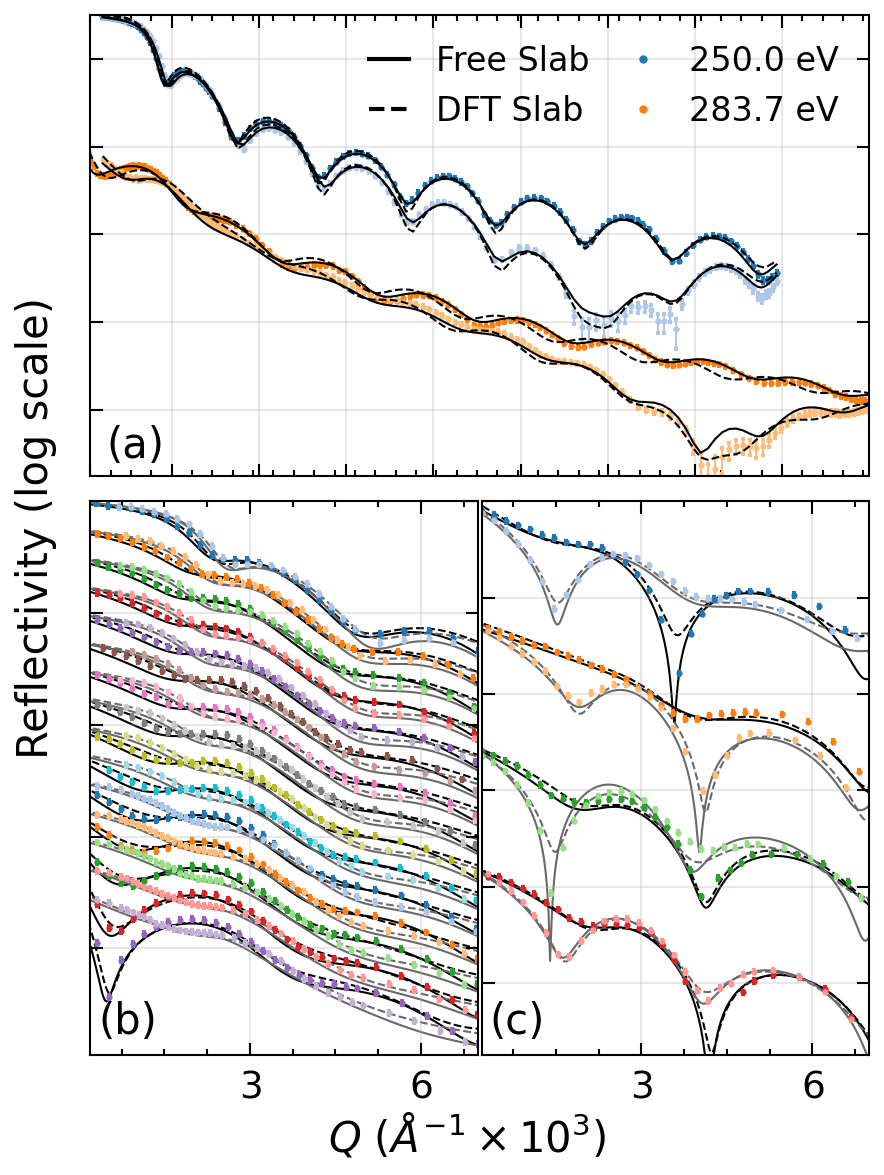

In [10]:
_ = plot_all_results(exp_constrained, dft_constrained, loaded_data,
    save_path=None,
    # save_path="xrr_model_comparison.png"
)

In [11]:
"""
Main-text fit-result figure, single PRL column.

Layout
    (a)  R(Q) at 250 eV and 283.7 eV, full Q, Free Slab and DFT Slab
    (b)  short-Q waterfall, pre-edge energies (250 < E < 283.7 eV)
    (c)  short-Q waterfall, post-edge resonant energies (E > 283.7 eV)
    (d)  A(Q, E) map from loaded data via MAKima interpolation
    (e)  A(Q, E) map from the DFT Slab fit
    (f)  A(Q, E) map from the Free Slab fit

Panels (d), (e), and (f) share a single thin colorbar. Only (d) shows
y-tick labels (Energy in eV). All four lower panels (b, c, d, e, f) and the
top panel (a) show x-tick labels in the same `Å^-1 x 10^3` convention used
elsewhere in the manuscript.
"""

from __future__ import annotations

from collections.abc import Sequence
from pathlib import Path

import matplotlib.gridspec as gs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import patheffects as pe
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.interpolate import Akima1DInterpolator

# ---------------------------------------------------------------------------
# model helper
# ---------------------------------------------------------------------------


def rxr(x, model, pol):
    _pol = model.pol
    model.pol = pol
    try:
        y = model(x)
    finally:
        model.pol = _pol
    return y


# ---------------------------------------------------------------------------
# interpolation pipeline for the data anisotropy map
# ---------------------------------------------------------------------------


def collapse_q_clusters(q, y, dq_tol: float = 1e-4):
    q_arr = np.asarray(q, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    order = np.argsort(q_arr)
    q_arr = q_arr[order]
    y_arr = y_arr[order]

    q_out: list[float] = [float(q_arr[0])]
    y_out: list[float] = [float(y_arr[0])]
    n_in_cluster = 1
    for i in range(1, q_arr.size):
        if q_arr[i] - q_out[-1] < dq_tol:
            y_out[-1] += float(y_arr[i])
            n_in_cluster += 1
        else:
            if n_in_cluster > 1:
                y_out[-1] /= n_in_cluster
            q_out.append(float(q_arr[i]))
            y_out.append(float(y_arr[i]))
            n_in_cluster = 1
    if n_in_cluster > 1:
        y_out[-1] /= n_in_cluster
    return np.asarray(q_out, dtype=np.float64), np.asarray(y_out, dtype=np.float64)


def interp_reflectivity_makima(
    q, y, q_grid, *, dq_tol: float = 1e-4, log_space: bool = True
):
    q_c, y_c = collapse_q_clusters(q, y, dq_tol=dq_tol)
    if log_space:
        y_c = np.log(np.clip(y_c, 1e-30, None))
    interpolator = Akima1DInterpolator(q_c, y_c, method="makima", extrapolate=False)
    out = np.asarray(interpolator(q_grid), dtype=np.float64)
    if log_space:
        out = np.exp(out)
    return out


def _build_common_q_axis(loaded_data, energies, n_pts: int = 1000):
    q_min = -np.inf
    q_max = np.inf
    for energy in energies:
        ds = loaded_data[str(energy)]
        for pol in ("s", "p"):
            pol_data = getattr(ds, pol)
            q_min = max(q_min, float(pol_data.x.min()))
            q_max = min(q_max, float(pol_data.x.max()))
    if not np.isfinite(q_min) or not np.isfinite(q_max) or q_max <= q_min:
        raise ValueError("Could not establish a common Q range across energies.")
    return np.linspace(q_min, q_max, n_pts)


def _anisotropy_grid_from_data(loaded_data, energies, common_q):
    """Shape (len(common_q), len(energies)) from raw data."""
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        ds = loaded_data[str(energy)]
        s_grid[:, i] = interp_reflectivity_makima(ds.s.x, ds.s.y, common_q)
        p_grid[:, i] = interp_reflectivity_makima(ds.p.x, ds.p.y, common_q)
    return (p_grid - s_grid) / (p_grid + s_grid)


def _anisotropy_grid_from_model(objectives, energies, common_q):
    """Shape (len(common_q), len(energies)) from a fitted model."""
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        model = objectives[energy].model
        s_grid[:, i] = rxr(common_q, model, "s")
        p_grid[:, i] = rxr(common_q, model, "p")
    denom = s_grid + p_grid
    denom = np.where(np.abs(denom) > 0, denom, np.nan)
    return (p_grid - s_grid) / denom


# ---------------------------------------------------------------------------
# panel renderers
# ---------------------------------------------------------------------------


def _plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data,
    offset_scale=-1.5, q_xlim=(0.002, 0.07),
):
    cmap = plt.colormaps.get_cmap("tab20")
    xdata = np.linspace(0.0005, 0.27, 1000)

    offset = 1.0
    last_y_min = 1e-12
    for idx, energy in enumerate(energies):
        if energy not in exp_objectives:
            continue
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        offset = 10 ** (offset_scale * idx)
        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            color = (
                cmap(2 * idx % 20) if pol == "s" else cmap((2 * idx + 1) % 20)
            )
            ax.errorbar(
                pol_data.x, pol_data.y * offset, yerr=pol_data.y_err * offset,
                lw=0, color=color, capsize=0.5,
                marker="o", elinewidth=0.5, markersize=0.5,
                markerfacecolor=color, markevery=2, errorevery=2,
            )
        for pol in ("s", "p"):
            line_color = "k" if pol == "s" else "dimgrey"
            y_exp = rxr(xdata, o_exp.model, pol)
            y_dft = rxr(xdata, o_dft.model, pol)
            ax.plot(xdata, y_exp * offset, color=line_color, lw=0.5, ls="-", zorder=-10)
            ax.plot(xdata, y_dft * offset, color=line_color, lw=0.5, ls="--", zorder=-10)
        last_y_min = offset * pol_data.y.min()

    ax.set_yscale("log")
    ax.set_xlim(*q_xlim)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)
    ax.set_xticks([0.03, 0.06])
    ax.set_xticklabels([r"$3$", r"$6$"])


def _plot_reference_pair(
    ax,
    comparison_energies,
    exp_objectives,
    dft_objectives,
    loaded_data,
    *,
    branch_label_q: float = 0.12,
    energy_label_q: float = 0.028,
    show_pol_labels: bool = True,
    show_energy_labels: bool = True,
):
    cmap = plt.colormaps.get_cmap("tab20")
    last_y_min = 1e-12
    for i, energy in enumerate(comparison_energies):
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        scale = 10 ** (-3 * i)
        energy_col = cmap(2 * i)
        for pol in ("s", "p"):
            col = cmap(2 * i) if pol == "s" else cmap(2 * i + 1)
            pol_data = getattr(data, pol)
            ax.errorbar(
                pol_data.x, pol_data.y * scale, yerr=pol_data.y_err * scale,
                lw=0, color=col, capsize=0.5, marker="o",
                elinewidth=0.5, markersize=0.5, markerfacecolor=col,
            )
        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            y_exp = rxr(pol_data.x, o_exp.model, pol)
            y_dft = rxr(pol_data.x, o_dft.model, pol)
            ax.plot(pol_data.x, y_exp * scale, color="k", lw=0.5, zorder=10)
            ax.plot(pol_data.x, y_dft * scale, color="k", lw=0.5, ls="--", zorder=10)
        last_y_min = scale * pol_data.y.min()

        if show_pol_labels or show_energy_labels:
            s_data = data.s
            p_data = data.p
            if show_energy_labels:
                i_el = int(np.argmin(np.abs(s_data.x - energy_label_q)))
                ax.annotate(
                    f"{_format_energy_tick_label(float(energy))} eV",
                    (float(s_data.x[i_el]), float(s_data.y[i_el] * scale)),
                    textcoords="offset points",
                    xytext=(-10, 0),
                    ha="right",
                    va="center",
                    color=energy_col,
                    fontsize=7,
                )
            if show_pol_labels:
                i_s = int(np.argmin(np.abs(s_data.x - branch_label_q)))
                ax.annotate(
                    "s",
                    (float(s_data.x[i_s]), float(s_data.y[i_s] * scale)),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha="center",
                    va="center",
                    color="0.3",
                    fontsize=7,
                )
                if i == len(comparison_energies) - 1:
                    m_brew = p_data.x >= 0.15
                    if np.any(m_brew):
                        brew_idx = int(np.argmin(p_data.y[m_brew]))
                        i_p = int(np.flatnonzero(m_brew)[brew_idx])
                    else:
                        i_p = int(np.argmin(p_data.y))
                    ax.annotate(
                        "p",
                        (float(p_data.x[i_p]), float(p_data.y[i_p] * scale)),
                        textcoords="offset points",
                        xytext=(0, 0),
                        ha="center",
                        va="center",
                        color="0.3",
                        fontsize=7,
                    )
                else:
                    i_p = int(np.argmin(np.abs(p_data.x - branch_label_q)))
                    ax.annotate(
                        "p",
                        (float(p_data.x[i_p]), float(p_data.y[i_p] * scale)),
                        textcoords="offset points",
                        xytext=(0, -20),
                        ha="center",
                        va="center",
                        color="0.3",
                        fontsize=7,
                    )

    ax.set_xlim(0.002, 0.27)
    ax.set_yscale("log")
    ax.set_yticklabels([])

    # x-tick labels under (a), matching the existing × 10^3 convention used
    # elsewhere in the figure.
    ax.set_xticks([0.0, 0.06, 0.12, 0.18, 0.24])
    ax.set_xticklabels([r"$0$", r"$6$", r"$12$", r"$18$", r"$24$"])
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)

    handles = [
        Line2D([], [], color="k", lw=1, ls="-", label="Free Slab"),
        Line2D([], [], color="k", lw=1, ls="--", label="DFT Slab"),
    ]
    ax.legend(
        handles=handles, loc="upper right", fontsize=7, ncols=1,
        handlelength=1.2, columnspacing=1.0,
        framealpha=0, fancybox=False,
    )


def _format_energy_tick_label(energy: float) -> str:
    """Format one anisotropy-map energy tick label in eV."""
    rounded = round(energy)
    if np.isclose(energy, rounded, rtol=0.0, atol=1e-6):
        return f"{int(rounded)}"
    text = f"{energy:.1f}"
    if "." in text:
        text = text.rstrip("0").rstrip(".")
    return text


def _anisotropy_y_tick_positions(
    energies: Sequence[float],
    tick_energies: Sequence[float],
    *,
    match_atol: float = 0.35,
) -> tuple[np.ndarray, list[str]]:
    """Map requested energy major ticks to scan-index y positions."""
    e_arr = np.asarray(energies, dtype=np.float64)
    if e_arr.size == 0:
        return e_arr, []

    positions: list[float] = []
    labels: list[str] = []
    used_indices: set[int] = set()
    for tick_e in tick_energies:
        idx = int(np.argmin(np.abs(e_arr - float(tick_e))))
        if idx in used_indices:
            continue
        if abs(float(e_arr[idx]) - float(tick_e)) > match_atol:
            continue
        used_indices.add(idx)
        positions.append(float(idx))
        labels.append(_format_energy_tick_label(float(tick_e)))

    order = np.argsort(positions)
    sorted_positions = np.asarray(positions, dtype=np.float64)[order]
    sorted_labels = [labels[i] for i in order]
    return sorted_positions, sorted_labels


def _plot_anisotropy_map(
    ax, grid, q, energies, cmap, norm, panel_label, show_yticks=True,
):
    grid_arr = np.asarray(grid, dtype=np.float64)
    q_arr = np.asarray(q, dtype=np.float64)
    e_arr = np.asarray(energies, dtype=np.float64)
    if grid_arr.shape != (q_arr.size, e_arr.size):
        raise ValueError(
            f"grid shape {grid_arr.shape} != (len(q), len(energies)) "
            f"= ({q_arr.size}, {e_arr.size})."
        )

    n_scan = int(e_arr.size)
    y_lo, y_hi = -0.5, n_scan - 0.5
    ax.set_facecolor("#ECECEC")
    mappable = ax.imshow(
        grid_arr.T,
        origin="lower",
        aspect="auto",
        extent=(float(q_arr[0]), float(q_arr[-1]), y_lo, y_hi),
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        rasterized=True,
    )
    ax.set_xlim(float(q_arr[0]), float(q_arr[-1]))
    ax.set_ylim(y_lo, y_hi)
    ax.set_autoscale_on(False)
    ax.tick_params(axis="both", labelsize=8)
    if not show_yticks:
        ax.tick_params(labelleft=False)
    txt = ax.text(
        0.05, 0.96, panel_label,
        transform=ax.transAxes, va="top", ha="left",
        fontsize=9, color="white", fontweight="bold",
    )
    txt.set_path_effects(
        [pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()]
    )
    return mappable


# ---------------------------------------------------------------------------
# main entry point
# ---------------------------------------------------------------------------


def plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    aniso_energy_max: float = 283.7,
    n_q_aniso: int = 1000,
    aniso_cmap: str = "coolwarm",
    vmax_aniso: float | None = None,
    aniso_y_ticks: Sequence[float] = (280.0, 281.0, 282.0, 283.0),
    reference_energies: Sequence[float] = (250.0, 283.7),
    branch_label_q: float = 0.12,
    energy_label_q: float = 0.028,
    show_pol_labels: bool = True,
    show_energy_labels: bool = True,
):
    """
    Build the main-text fit-result figure.

    Parameters
    ----------
    exp_constrained, dft_constrained
        Fitted objective containers.
    loaded_data
        Mapping of `str(energy)` to a data record with `.s`, `.p`,
        `.anisotropy`.
    save_path
        If provided, write at 300 dpi with transparent background.
    aniso_energy_max
        Upper cutoff for the energies included in the anisotropy maps.
    n_q_aniso
        Number of points in the common Q axis used for the maps.
    aniso_cmap
        Diverging colormap name. matplotlib or seaborn names are resolved.
    vmax_aniso
        Symmetric color limit. If None, set from the joint 99th percentile
        of |A| over all three maps.
    aniso_y_ticks
        Energy values (eV) for major y ticks on panel (d). Each value is
        snapped to the nearest scan in the map; ticks are placed at that
        scan's index on the index-uniform y axis.
    reference_energies
        Energies plotted in panel (a).
    branch_label_q
        Q location (Å⁻¹) for s/p branch annotations in panel (a).
    energy_label_q
        Low-Q anchor (Å⁻¹) for on-plot energy labels in panel (a).
    show_pol_labels, show_energy_labels
        Toggle on-plot s/p and energy annotations in panel (a).
    """
    fig_width = 3.35
    fig_height = 5.8
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)

    outer = gs.GridSpec(
        3, 1, figure=fig,
        height_ratios=[1.0, 1.2, 0.45],
        hspace=0.15,
        left=0.13, right=0.93, top=0.97, bottom=0.08,
    )

    ax_top = fig.add_subplot(outer[0])

    inner_mid = outer[1].subgridspec(1, 2, wspace=0.04)
    ax_bl = fig.add_subplot(inner_mid[0])
    ax_br = fig.add_subplot(inner_mid[1])

    # Bottom row: three side-by-side maps + a thin shared colorbar.
    inner_bot = outer[2].subgridspec(
        1, 4,
        width_ratios=[1.0, 1.0, 1.0, 0.06],
        wspace=0.04,
    )
    ax_d = fig.add_subplot(inner_bot[0])
    ax_e = fig.add_subplot(inner_bot[1], sharey=ax_d)
    ax_f = fig.add_subplot(inner_bot[2], sharey=ax_d)
    cax = fig.add_subplot(inner_bot[3])

    for ax in (ax_top, ax_bl, ax_br, ax_d, ax_e, ax_f):
        ax.tick_params(axis="both", labelsize=8)
        ax.xaxis.label.set_size(9)
        ax.yaxis.label.set_size(9)

    # ----- objectives keyed by energy -----
    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    # ----- (a) reference pair -----
    _plot_reference_pair(
        ax_top, np.asarray(reference_energies, dtype=np.float64),
        exp_objectives, dft_objectives, loaded_data,
        branch_label_q=branch_label_q,
        energy_label_q=energy_label_q,
        show_pol_labels=show_pol_labels,
        show_energy_labels=show_energy_labels,
    )

    # ----- (b), (c) waterfalls -----
    non_resonant = [e for e in common_energies if 250.0 < e < 283.7]
    resonant = [e for e in common_energies if e > 283.7]
    _plot_vertically_offset_energies(
        ax_bl, non_resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-0.5,
    )
    _plot_vertically_offset_energies(
        ax_br, resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-2.5,
    )
    for ax in (ax_bl, ax_br):
        ax.set_ylabel("")
        ax.set_yticklabels([])

    # ----- (d), (e), (f) anisotropy maps -----
    aniso_energies = sorted(
        e for e in common_energies
        if e <= aniso_energy_max and str(e) in loaded_data
    )
    if len(aniso_energies) < 2:
        raise ValueError(
            "Need at least two energies <= aniso_energy_max for the maps."
        )

    common_q = _build_common_q_axis(loaded_data, aniso_energies, n_pts=n_q_aniso)
    a_data = _anisotropy_grid_from_data(loaded_data, aniso_energies, common_q)
    a_dft = _anisotropy_grid_from_model(dft_objectives, aniso_energies, common_q)
    a_free = _anisotropy_grid_from_model(exp_objectives, aniso_energies, common_q)

    if vmax_aniso is None:
        finite = np.concatenate(
            [
                np.abs(a_data[np.isfinite(a_data)]).ravel(),
                np.abs(a_dft[np.isfinite(a_dft)]).ravel(),
                np.abs(a_free[np.isfinite(a_free)]).ravel(),
            ]
        )
        if finite.size == 0:
            vmax_aniso = 1.0
        else:
            vmax_aniso = float(np.nanpercentile(finite, 99.0))
            vmax_aniso = float(np.clip(vmax_aniso, 1e-3, 1.0))

    norm = TwoSlopeNorm(vmin=-vmax_aniso, vcenter=0.0, vmax=vmax_aniso)

    try:
        cmap_obj = plt.get_cmap(aniso_cmap)
    except ValueError:
        cmap_obj = sns.color_palette(aniso_cmap, as_cmap=True)
    cmap_obj.set_bad("#ECECEC")

    mesh = _plot_anisotropy_map(
        ax_d, a_data, common_q, aniso_energies, cmap_obj, norm, "(d) data"
    )
    _plot_anisotropy_map(
        ax_e, a_dft, common_q, aniso_energies, cmap_obj, norm,
        "(e) DFT", show_yticks=False,
    )
    _plot_anisotropy_map(
        ax_f, a_free, common_q, aniso_energies, cmap_obj, norm,
        "(f) Free", show_yticks=False,
    )

    n_scan = len(aniso_energies)
    y_lo, y_hi = -0.5, n_scan - 0.5
    tick_positions, tick_labels = _anisotropy_y_tick_positions(
        aniso_energies, aniso_y_ticks,
    )
    for ax in (ax_d, ax_e, ax_f):
        ax.set_ylim(y_lo, y_hi)
    ax_d.set_yticks(tick_positions)
    ax_d.set_yticklabels(tick_labels, rotation=-45)
    ax_d.tick_params(axis="y", labelleft=True, labelsize=8)
    ax_e.tick_params(axis="y", labelleft=False)
    ax_f.tick_params(axis="y", labelleft=False)

    ax_d.set_ylabel("Energy (eV)")
    for ax in (ax_d, ax_e, ax_f):
        ax.set_xlim(float(common_q[0]), float(common_q[-1]))
        ax.set_xticks([0.03, 0.06])
        ax.set_xticklabels([r"$3$", r"$6$"])

    cb = fig.colorbar(mesh, cax=cax, extend="both")
    cb.set_label(r"Anisotropy", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    cb.set_ticks([-.25, 0, .25])
    cb.set_ticklabels([r"$-1/4$", r"$0$", r"$1/4$"])
    cb.outline.set_linewidth(0.5)

    # ----- figure-wide labels -----
    fig.text(
        0.04, 0.68, "Reflectivity (log scale)",
        va="center", rotation="vertical", fontsize=9,
    )
    fig.text(
        0.5, 0.04, r"$Q$ ($\AA^{-1} \times 10^3$)",
        ha="center", va="center", fontsize=9,
    )

    for ax, lbl in zip([ax_top, ax_bl, ax_br], ["(a)", "(b)", "(c)"]):
        ax.text(
            0.02, 0.02, lbl,
            transform=ax.transAxes, va="bottom", ha="left", fontsize=9,
        )

    fig.align_labels()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.close(fig)
    else:
        plt.show()

    return fig

In [12]:
"""
Main-text fit-result figure, single PRL column.

Layout
    (a)  R(Q) at 250 eV and 283.7 eV, full Q, Free Slab and DFT Slab
    (b)  short-Q waterfall, pre-edge energies (250 < E < 283.7 eV)
    (c)  short-Q waterfall, post-edge resonant energies (E > 283.7 eV)
    (d)  A(Q, E) map from loaded data via MAKima interpolation
    (e)  A(Q, E) map from the DFT Slab fit
    (f)  A(Q, E) map from the Free Slab fit

Panels (d), (e), (f) share a single thin colorbar.

v8 changes
    - Legend s/p swatches now use a neutral dark/light gray pair so the
      darker-shade-is-s convention reads without committing to a hue.
    - Both s and p model traces in the waterfall panels are black, matching
      panel (a). The dimgrey p-pol trace introduced earlier is removed.
    - Critical-angle visualization rewritten. For each polarization the
      Q_c locus is drawn as `x` markers on the DFT trace connected by a
      thin line. s-pol uses δ_xx with a dashed connector, p-pol uses δ_zz
      with a dotted connector. Each polarization has an independent toggle.
"""

from __future__ import annotations

from collections.abc import Sequence
from pathlib import Path

import matplotlib.gridspec as gs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import patheffects as pe
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.interpolate import Akima1DInterpolator

_HC_EV_ANG = 12398.4198  # hc in eV * Å


# ---------------------------------------------------------------------------
# model helpers
# ---------------------------------------------------------------------------


def rxr(x, model, pol):
    _pol = model.pol
    model.pol = pol
    try:
        y = model(x)
    finally:
        model.pol = _pol
    return y


def _q_critical(objective, pol: str = "s") -> float | None:
    """
    Q at the critical angle for a single objective and polarization.

    s-polarization uses the in-plane decrement δ_xx, p-polarization uses the
    out-of-plane decrement δ_zz. Both come from the third layer of the
    objective's structure tensor. Returns None when the layer is not present
    or the decrement is non-physical.
    """
    try:
        energy = float(objective.model.energy)
        if pol == "s":
            d = float(objective.model.structure[2].sld.tensor[0, 0].real)
        elif pol == "p":
            d = float(objective.model.structure[2].sld.tensor[2, 2].real)
        else:
            raise ValueError(f"Unknown pol: {pol!r}")
    except (AttributeError, IndexError, TypeError):
        return None
    if not np.isfinite(d) or d <= 0:
        return None
    lam_ang = _HC_EV_ANG / energy
    theta_c = float(np.sqrt(2.0 * d))
    return float(4.0 * np.pi * np.sin(theta_c) / lam_ang)


# ---------------------------------------------------------------------------
# interpolation pipeline for the data anisotropy map
# ---------------------------------------------------------------------------


def collapse_q_clusters(q, y, dq_tol: float = 1e-4):
    q_arr = np.asarray(q, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    order = np.argsort(q_arr)
    q_arr = q_arr[order]
    y_arr = y_arr[order]

    q_out: list[float] = [float(q_arr[0])]
    y_out: list[float] = [float(y_arr[0])]
    n_in_cluster = 1
    for i in range(1, q_arr.size):
        if q_arr[i] - q_out[-1] < dq_tol:
            y_out[-1] += float(y_arr[i])
            n_in_cluster += 1
        else:
            if n_in_cluster > 1:
                y_out[-1] /= n_in_cluster
            q_out.append(float(q_arr[i]))
            y_out.append(float(y_arr[i]))
            n_in_cluster = 1
    if n_in_cluster > 1:
        y_out[-1] /= n_in_cluster
    return np.asarray(q_out, dtype=np.float64), np.asarray(y_out, dtype=np.float64)


def interp_reflectivity_makima(
    q, y, q_grid, *, dq_tol: float = 1e-4, log_space: bool = True
):
    q_c, y_c = collapse_q_clusters(q, y, dq_tol=dq_tol)
    if log_space:
        y_c = np.log(np.clip(y_c, 1e-30, None))
    interpolator = Akima1DInterpolator(q_c, y_c, method="makima", extrapolate=False)
    out = np.asarray(interpolator(q_grid), dtype=np.float64)
    if log_space:
        out = np.exp(out)
    return out


def _build_common_q_axis(loaded_data, energies, n_pts: int = 1000):
    q_min = -np.inf
    q_max = np.inf
    for energy in energies:
        ds = loaded_data[str(energy)]
        for pol in ("s", "p"):
            pol_data = getattr(ds, pol)
            q_min = max(q_min, float(pol_data.x.min()))
            q_max = min(q_max, float(pol_data.x.max()))
    if not np.isfinite(q_min) or not np.isfinite(q_max) or q_max <= q_min:
        raise ValueError("Could not establish a common Q range across energies.")
    return np.linspace(q_min, q_max, n_pts)


def _anisotropy_grid_from_data(loaded_data, energies, common_q):
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        ds = loaded_data[str(energy)]
        s_grid[:, i] = interp_reflectivity_makima(ds.s.x, ds.s.y, common_q)
        p_grid[:, i] = interp_reflectivity_makima(ds.p.x, ds.p.y, common_q)
    return (p_grid - s_grid) / (p_grid + s_grid)


def _anisotropy_grid_from_model(objectives, energies, common_q):
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        model = objectives[energy].model
        s_grid[:, i] = rxr(common_q, model, "s")
        p_grid[:, i] = rxr(common_q, model, "p")
    denom = s_grid + p_grid
    denom = np.where(np.abs(denom) > 0, denom, np.nan)
    return (p_grid - s_grid) / denom


# ---------------------------------------------------------------------------
# small label helpers
# ---------------------------------------------------------------------------


def _format_energy_tick_label(energy: float) -> str:
    rounded = round(energy)
    if np.isclose(energy, rounded, rtol=0.0, atol=1e-6):
        return f"{int(rounded)}"
    text = f"{energy:.1f}"
    if "." in text:
        text = text.rstrip("0").rstrip(".")
    return text


def _anisotropy_y_tick_positions(
    energies: Sequence[float],
    tick_energies: Sequence[float],
    *,
    match_atol: float = 0.35,
) -> tuple[np.ndarray, list[str]]:
    e_arr = np.asarray(energies, dtype=np.float64)
    if e_arr.size == 0:
        return e_arr, []

    positions: list[float] = []
    labels: list[str] = []
    used_indices: set[int] = set()
    for tick_e in tick_energies:
        idx = int(np.argmin(np.abs(e_arr - float(tick_e))))
        if idx in used_indices:
            continue
        if abs(float(e_arr[idx]) - float(tick_e)) > match_atol:
            continue
        used_indices.add(idx)
        positions.append(float(idx))
        labels.append(_format_energy_tick_label(float(tick_e)))

    order = np.argsort(positions)
    sorted_positions = np.asarray(positions, dtype=np.float64)[order]
    sorted_labels = [labels[i] for i in order]
    return sorted_positions, sorted_labels


_LABEL_HALO = [pe.withStroke(linewidth=1.6, foreground="white")]


def _annotate_above_curve(
    ax, q_anchor, y_anchor, text, *, color, fontsize=7, offset_pts=5,
    weight="normal",
):
    ann = ax.annotate(
        text,
        (float(q_anchor), float(y_anchor)),
        xytext=(0, offset_pts),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=color,
        fontsize=fontsize,
        fontweight=weight,
    )
    ann.set_path_effects(_LABEL_HALO)
    return ann


def _resolve_per_energy_q(
    value: float | Sequence[float],
    n_energies: int,
    name: str,
) -> list[float]:
    if np.isscalar(value):
        return [float(value)] * n_energies
    arr = list(value)
    if len(arr) != n_energies:
        raise ValueError(
            f"{name} has length {len(arr)} but reference_energies has "
            f"length {n_energies}."
        )
    return [float(v) for v in arr]


# ---------------------------------------------------------------------------
# panel renderers
# ---------------------------------------------------------------------------


def _plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data,
    *,
    offset_scale: float = -1.5,
    q_xlim: tuple[float, float] = (0.002, 0.07),
    show_qc_s: bool = True,
    show_qc_p: bool = True,
    qc_color: str = "k",
    qc_s_marker: str = "x",
    qc_p_marker: str = "x",
    qc_s_linestyle: str = "--",
    qc_p_linestyle: str = ":",
    qc_markersize: float = 2.0,
    qc_linewidth: float = 0.6,
    qc_markeredgewidth: float = 0.8,
):
    """
    Vertically-offset waterfall of s/p reflectivity for each energy. The
    critical-angle locus is overlaid as markers on the DFT traces at Q_c,s
    and Q_c,p, connected across energies by a thin line per polarization.
    """
    cmap = plt.colormaps.get_cmap("tab20")
    xdata = np.linspace(0.0005, 0.27, 1000)

    offset = 1.0
    last_y_min = 1e-12
    qc_s_pts: list[tuple[float, float]] = []
    qc_p_pts: list[tuple[float, float]] = []

    for idx, energy in enumerate(energies):
        if energy not in exp_objectives:
            continue
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        offset = 10 ** (offset_scale * idx)

        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            color = (
                cmap(2 * idx % 20) if pol == "s" else cmap((2 * idx + 1) % 20)
            )
            ax.errorbar(
                pol_data.x, pol_data.y * offset, yerr=pol_data.y_err * offset,
                lw=0, color=color, capsize=0.5,
                marker="o", elinewidth=0.5, markersize=0.5,
                markerfacecolor=color, markevery=2, errorevery=2,
            )
        # Both s and p model traces in black.
        for pol in ("s", "p"):
            y_exp = rxr(xdata, o_exp.model, pol)
            y_dft = rxr(xdata, o_dft.model, pol)
            ax.plot(xdata, y_exp * offset, color="k", lw=0.5, ls="-", zorder=-10)
            ax.plot(xdata, y_dft * offset, color="k", lw=0.5, ls="--", zorder=-10)
        last_y_min = offset * pol_data.y.min()

        if show_qc_s:
            q_c_s = _q_critical(o_dft, pol="s")
            if q_c_s is not None and q_xlim[0] <= q_c_s <= q_xlim[1]:
                y_qc_s = float(rxr(np.array([q_c_s]), o_dft.model, "s")[0]) * offset
                qc_s_pts.append((q_c_s, y_qc_s))

        if show_qc_p:
            q_c_p = _q_critical(o_dft, pol="p")
            if q_c_p is not None and q_xlim[0] <= q_c_p <= q_xlim[1]:
                y_qc_p = float(rxr(np.array([q_c_p]), o_dft.model, "p")[0]) * offset
                qc_p_pts.append((q_c_p, y_qc_p))

    if qc_s_pts:
        xs, ys = zip(*qc_s_pts)
        ax.plot(
            xs, ys,
            marker=qc_s_marker, markersize=qc_markersize,
            markeredgewidth=qc_markeredgewidth, markerfacecolor="none",
            linestyle=qc_s_linestyle, linewidth=qc_linewidth,
            color=qc_color, zorder=8,
        )
    if qc_p_pts:
        xs, ys = zip(*qc_p_pts)
        ax.plot(
            xs, ys,
            marker=qc_p_marker, markersize=qc_markersize,
            markeredgewidth=qc_markeredgewidth, markerfacecolor="none",
            linestyle=qc_p_linestyle, linewidth=qc_linewidth,
            color=qc_color, zorder=8,
        )

    ax.set_yscale("log")
    ax.set_xlim(*q_xlim)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)
    ax.set_xticks([0.03, 0.06])
    ax.set_xticklabels([r"$3$", r"$6$"])


def _plot_reference_pair(
    ax,
    comparison_energies,
    exp_objectives,
    dft_objectives,
    loaded_data,
    *,
    energy_label_q,
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    s_swatch: str = "0.20",
    p_swatch: str = "0.65",
):
    """
    Panel (a). Data and model traces for each energy plus an energy label
    placed above the Free Slab s-pol trace at the caller-specified Q anchor.
    The legend carries the s/p convention as a dark/light gray swatch pair.
    """
    cmap = plt.colormaps.get_cmap("tab20")
    last_y_min = 1e-12

    q_anchors = _resolve_per_energy_q(
        energy_label_q, len(comparison_energies), "energy_label_q",
    )

    for i, energy in enumerate(comparison_energies):
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        scale = 10 ** (-3 * i)
        energy_col = cmap(2 * i)

        for pol in ("s", "p"):
            col = cmap(2 * i) if pol == "s" else cmap(2 * i + 1)
            pol_data = getattr(data, pol)
            ax.errorbar(
                pol_data.x, pol_data.y * scale, yerr=pol_data.y_err * scale,
                lw=0, color=col, capsize=0.5, marker="o",
                elinewidth=0.5, markersize=0.5, markerfacecolor=col,
            )
        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            y_exp = rxr(pol_data.x, o_exp.model, pol)
            y_dft = rxr(pol_data.x, o_dft.model, pol)
            ax.plot(pol_data.x, y_exp * scale, color="k", lw=0.5, zorder=10)
            ax.plot(pol_data.x, y_dft * scale, color="k", lw=0.5, ls="--", zorder=10)
        last_y_min = scale * pol_data.y.min()

        if show_energy_labels:
            q_anchor = q_anchors[i]
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * scale
            _annotate_above_curve(
                ax, q_anchor, y_e,
                f"{_format_energy_tick_label(float(energy))} eV",
                color=energy_col,
                fontsize=7,
                offset_pts=label_offset_pts,
                weight="bold",
            )

    ax.set_xlim(0.002, 0.27)
    ax.set_yscale("log")
    ax.set_yticklabels([])

    ax.set_xticks([0.0, 0.06, 0.12, 0.18, 0.24])
    ax.set_xticklabels([r"$0$", r"$6$", r"$12$", r"$18$", r"$24$"])
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)

    # Neutral dark/light gray pair conveys "darker shade is s, lighter is p"
    # without anchoring the convention to a specific hue.
    handles = [
        Line2D([], [], color="k", lw=1, ls="-", label="Free Slab"),
        Line2D([], [], color="k", lw=1, ls="--", label="DFT Slab"),
        Line2D(
            [], [], color=s_swatch, marker="o", markersize=3,
            markerfacecolor=s_swatch, linestyle="None", label=r"$s$",
        ),
        Line2D(
            [], [], color=p_swatch, marker="o", markersize=3,
            markerfacecolor=p_swatch, linestyle="None", label=r"$p$",
        ),
    ]
    ax.legend(
        handles=handles, loc="upper right", fontsize=7, ncols=2,
        handlelength=1.2, columnspacing=1.0,
        framealpha=0, fancybox=False,
    )


def _plot_anisotropy_map(
    ax, grid, q, energies, cmap, norm, panel_label, show_yticks=True,
):
    grid_arr = np.asarray(grid, dtype=np.float64)
    q_arr = np.asarray(q, dtype=np.float64)
    e_arr = np.asarray(energies, dtype=np.float64)
    if grid_arr.shape != (q_arr.size, e_arr.size):
        raise ValueError(
            f"grid shape {grid_arr.shape} != (len(q), len(energies)) "
            f"= ({q_arr.size}, {e_arr.size})."
        )

    n_scan = int(e_arr.size)
    y_lo, y_hi = -0.5, n_scan - 0.5
    ax.set_facecolor("#ECECEC")
    mappable = ax.imshow(
        grid_arr.T,
        origin="lower",
        aspect="auto",
        extent=(float(q_arr[0]), float(q_arr[-1]), y_lo, y_hi),
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        rasterized=True,
    )
    ax.set_xlim(float(q_arr[0]), float(q_arr[-1]))
    ax.set_ylim(y_lo, y_hi)
    ax.set_autoscale_on(False)
    ax.tick_params(axis="both", labelsize=8)
    if not show_yticks:
        ax.tick_params(labelleft=False)
    txt = ax.text(
        0.05, 0.96, panel_label,
        transform=ax.transAxes, va="top", ha="left",
        fontsize=9, color="white", fontweight="bold",
    )
    txt.set_path_effects(
        [pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()]
    )
    return mappable


# ---------------------------------------------------------------------------
# main entry point
# ---------------------------------------------------------------------------


def plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    aniso_energy_max: float = 283.7,
    n_q_aniso: int = 1000,
    aniso_cmap: str = "coolwarm",
    vmax_aniso: float | None = None,
    aniso_y_ticks: Sequence[float] = (280.0, 281.0, 282.0, 283.0),
    reference_energies: Sequence[float] = (250.0, 283.7),
    energy_label_q: float | Sequence[float] = (0.07, 0.025),
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    legend_s_swatch: str = "0.20",
    legend_p_swatch: str = "0.65",
    # Critical-angle markers, independent per panel and per polarization.
    show_qc_s_in_b: bool = True,
    show_qc_p_in_b: bool = True,
    show_qc_s_in_c: bool = False,
    show_qc_p_in_c: bool = False,
    qc_color: str = "k",
    qc_s_marker: str = "x",
    qc_p_marker: str = "x",
    qc_s_linestyle: str = "--",
    qc_p_linestyle: str = ":",
    qc_markersize: float = 2.0,
    qc_linewidth: float = 0.6,
    qc_markeredgewidth: float = 0.8,
):
    """
    Build the main-text fit-result figure.

    Parameters new or modified in v8
    --------------------------------
    legend_s_swatch, legend_p_swatch
        Colors for the s/p swatches in the panel (a) legend. Defaults to a
        neutral dark/light gray pair so the dark-shade-is-s convention reads
        independent of any specific energy color.
    show_qc_s_in_b, show_qc_p_in_b, show_qc_s_in_c, show_qc_p_in_c
        Toggle the critical-angle markers per panel and per polarization.
        s-pol uses δ_xx, p-pol uses δ_zz from the third layer of the DFT
        structure tensor.
    qc_color, qc_s_marker, qc_p_marker, qc_s_linestyle, qc_p_linestyle,
    qc_markersize, qc_linewidth, qc_markeredgewidth
        Styling of the Q_c markers and their connecting lines.
    """
    fig_width = 3.35
    fig_height = 5.8
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=600)

    outer = gs.GridSpec(
        3, 1, figure=fig,
        height_ratios=[1.0, 1.2, 0.45],
        hspace=0.15,
        left=0.13, right=0.93, top=0.97, bottom=0.08,
    )

    ax_top = fig.add_subplot(outer[0])

    inner_mid = outer[1].subgridspec(1, 2, wspace=0.04)
    ax_bl = fig.add_subplot(inner_mid[0])
    ax_br = fig.add_subplot(inner_mid[1])

    inner_bot = outer[2].subgridspec(
        1, 4,
        width_ratios=[1.0, 1.0, 1.0, 0.06],
        wspace=0.04,
    )
    ax_d = fig.add_subplot(inner_bot[0])
    ax_e = fig.add_subplot(inner_bot[1], sharey=ax_d)
    ax_f = fig.add_subplot(inner_bot[2], sharey=ax_d)
    cax = fig.add_subplot(inner_bot[3])

    for ax in (ax_top, ax_bl, ax_br, ax_d, ax_e, ax_f):
        ax.tick_params(axis="both", labelsize=8)
        ax.xaxis.label.set_size(9)
        ax.yaxis.label.set_size(9)

    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    _plot_reference_pair(
        ax_top, np.asarray(reference_energies, dtype=np.float64),
        exp_objectives, dft_objectives, loaded_data,
        energy_label_q=energy_label_q,
        label_offset_pts=label_offset_pts,
        show_energy_labels=show_energy_labels,
        s_swatch=legend_s_swatch,
        p_swatch=legend_p_swatch,
    )

    qc_style_kwargs = dict(
        qc_color=qc_color,
        qc_s_marker=qc_s_marker,
        qc_p_marker=qc_p_marker,
        qc_s_linestyle=qc_s_linestyle,
        qc_p_linestyle=qc_p_linestyle,
        qc_markersize=qc_markersize,
        qc_linewidth=qc_linewidth,
        qc_markeredgewidth=qc_markeredgewidth,
    )

    non_resonant = [e for e in common_energies if 250.0 < e < 283.7]
    resonant = [e for e in common_energies if e > 283.7]
    _plot_vertically_offset_energies(
        ax_bl, non_resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-0.5,
        show_qc_s=show_qc_s_in_b,
        show_qc_p=show_qc_p_in_b,
        **qc_style_kwargs,
    )
    _plot_vertically_offset_energies(
        ax_br, resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-2.5,
        show_qc_s=show_qc_s_in_c,
        show_qc_p=show_qc_p_in_c,
        **qc_style_kwargs,
    )
    for ax in (ax_bl, ax_br):
        ax.set_ylabel("")
        ax.set_yticklabels([])

    aniso_energies = sorted(
        e for e in common_energies
        if e <= aniso_energy_max and str(e) in loaded_data
    )
    if len(aniso_energies) < 2:
        raise ValueError(
            "Need at least two energies <= aniso_energy_max for the maps."
        )

    common_q = _build_common_q_axis(loaded_data, aniso_energies, n_pts=n_q_aniso)
    a_data = _anisotropy_grid_from_data(loaded_data, aniso_energies, common_q)
    a_dft = _anisotropy_grid_from_model(dft_objectives, aniso_energies, common_q)
    a_free = _anisotropy_grid_from_model(exp_objectives, aniso_energies, common_q)

    if vmax_aniso is None:
        finite = np.concatenate(
            [
                np.abs(a_data[np.isfinite(a_data)]).ravel(),
                np.abs(a_dft[np.isfinite(a_dft)]).ravel(),
                np.abs(a_free[np.isfinite(a_free)]).ravel(),
            ]
        )
        if finite.size == 0:
            vmax_aniso = 1.0
        else:
            vmax_aniso = float(np.nanpercentile(finite, 99.0))
            vmax_aniso = float(np.clip(vmax_aniso, 1e-3, 1.0))

    norm = TwoSlopeNorm(vmin=-vmax_aniso, vcenter=0.0, vmax=vmax_aniso)

    try:
        cmap_obj = plt.get_cmap(aniso_cmap)
    except ValueError:
        cmap_obj = sns.color_palette(aniso_cmap, as_cmap=True)
    cmap_obj.set_bad("#ECECEC")

    mesh = _plot_anisotropy_map(
        ax_d, a_data, common_q, aniso_energies, cmap_obj, norm, "(d) data"
    )
    _plot_anisotropy_map(
        ax_e, a_dft, common_q, aniso_energies, cmap_obj, norm,
        "(e) DFT", show_yticks=False,
    )
    _plot_anisotropy_map(
        ax_f, a_free, common_q, aniso_energies, cmap_obj, norm,
        "(f) Free", show_yticks=False,
    )

    n_scan = len(aniso_energies)
    y_lo, y_hi = -0.5, n_scan - 0.5
    tick_positions, tick_labels = _anisotropy_y_tick_positions(
        aniso_energies, aniso_y_ticks,
    )
    for ax in (ax_d, ax_e, ax_f):
        ax.set_ylim(y_lo, y_hi)
    ax_d.set_yticks(tick_positions)
    ax_d.set_yticklabels(tick_labels, rotation=-45)
    ax_d.tick_params(axis="y", labelleft=True, labelsize=8)
    ax_e.tick_params(axis="y", labelleft=False)
    ax_f.tick_params(axis="y", labelleft=False)

    ax_d.set_ylabel("Energy (eV)")
    for ax in (ax_d, ax_e, ax_f):
        ax.set_xlim(float(common_q[0]), float(common_q[-1]))
        ax.set_xticks([0.03, 0.06])
        ax.set_xticklabels([r"$3$", r"$6$"])

    cb = fig.colorbar(mesh, cax=cax, extend="both")
    cb.set_label(r"Anisotropy", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    cb.set_ticks([-0.25, 0.0, 0.25])
    cb.set_ticklabels([r"$-1/4$", r"$0$", r"$1/4$"])
    cb.outline.set_linewidth(0.5)

    fig.text(
        0.04, 0.68, "Reflectivity (log scale)",
        va="center", rotation="vertical", fontsize=9,
    )
    fig.text(
        0.5, 0.04, r"$Q$ ($\AA^{-1} \times 10^3$)",
        ha="center", va="center", fontsize=9,
    )

    for ax, lbl in zip([ax_top, ax_bl, ax_br], ["(a)", "(b)", "(c)"]):
        ax.text(
            0.02, 0.02, lbl,
            transform=ax.transAxes, va="bottom", ha="left", fontsize=9,
        )

    fig.align_labels()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.close(fig)
    else:
        plt.show()

    return fig

In [13]:
_ = plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    show_energy_labels=True,
    aniso_y_ticks=(281.0, 282.0, 283.0, 284),
    show_qc_s_in_b=True,
    show_qc_p_in_b=True,
    show_qc_s_in_c=False,
    show_qc_p_in_c=False,
    qc_color="blue",
    save_path="fig2_xrr_model_comparison.png"
)

In [14]:
"""
Main-text fit-result figure, single PRL column.

Layout
    (a)  R(Q) at 250 eV and 283.7 eV, full Q, Free Slab and DFT Slab
    (b)  short-Q waterfall, pre-edge energies (250 < E < 283.7 eV)
    (c)  short-Q waterfall, post-edge resonant energies (E > 283.7 eV)
    (d)  A(Q, E) map from loaded data via MAKima interpolation
    (e)  A(Q, E) map from the DFT Slab fit
    (f)  A(Q, E) map from the Free Slab fit

Panels (d), (e), (f) share a single thin colorbar.

v9 changes
    - The critical-angle locus is removed from the waterfall panels by
      default. The waterfall y axis is offset reflectivity, so Q_c(E) is
      only implicitly parameterized there and the dashed/dotted connector
      contrast does not survive column-width reproduction.
    - Q_c(E) now lives on the anisotropy maps, where energy is an explicit
      axis and the locus is a genuine curve. Panel (e) carries the DFT
      model loci, panel (f) the Free model loci. The p-pol curve terminates
      at the energy where delta_zz crosses zero, so the disappearance of
      the p-pol total-external-reflection condition is a visible endpoint.
    - Panel (d) carries a model-free empirical locus extracted per energy
      row from the steepest descent of log R(Q). Agreement between (d) and
      (e)/(f) is then model-independent evidence, replacing the circular
      comparison of the model against its own delta.
    - s and p are distinguished by marker shape and fill (s filled
      triangle, p open circle), not by linestyle, so the distinction
      survives grayscale and small reproduction. The optional in-waterfall
      markers (off by default) use the same shape convention.

v9.1 changes
    - empirical_qc_from_rows thresholds are adaptive per row by default.
      The v9.0 absolute defaults (q_start=0.004, min_span=0.004,
      slope_thresh=200) implicitly assumed an edge near Q ~ 0.02 Å^-1 and
      rejected nearly every row of data whose plateau ends near
      0.005 Å^-1. Each row now thresholds against its own strongest
      descent and noise floor; q_max bounds the search so high-Q noise
      cannot inflate the reference. qc_extraction_report renders a
      per-row diagnostic for tuning on real data.
    - qc_overlay_style="contour" draws the loci as level-set contours of
      per-row plateau-normalized R_s (solid) and R_p (dashed) instead of
      extracted markers/curves. Note the contour never terminates where
      the edge vanishes; it collapses toward low Q instead, so the
      detection-based overlay remains the default for the disappearance
      claim.
    - Waterfall Q_c markers can again be threaded with connecting lines
      via qc_s_connect / qc_p_connect linestyle options.
    - Waterfall Q_c markers accept waterfall_qc_source="model"|"empirical"
      so the same panels can show either the DFT-tensor critical angle or
      the measured-R empirical edge without changing the extractor.
"""

from __future__ import annotations

from collections.abc import Sequence
from pathlib import Path

import matplotlib.gridspec as gs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import patheffects as pe
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.interpolate import Akima1DInterpolator
from scipy.signal import find_peaks, savgol_filter

_HC_EV_ANG = 12398.4198  # hc in eV * Å


# ---------------------------------------------------------------------------
# model helpers
# ---------------------------------------------------------------------------


def rxr(x, model, pol):
    _pol = model.pol
    model.pol = pol
    try:
        y = model(x)
    finally:
        model.pol = _pol
    return y


def _q_critical(objective, pol: str = "s") -> float | None:
    """
    Q at the critical angle for a single objective and polarization.

    s-polarization uses the in-plane decrement delta_xx, p-polarization the
    out-of-plane decrement delta_zz, both from the third layer of the
    objective's structure tensor. Returns None when the layer is absent or
    the decrement is non-physical (the p branch returning None above the
    delta_zz zero crossing is what terminates the p locus on the maps).
    """
    try:
        energy = float(objective.model.energy)
        if pol == "s":
            d = float(objective.model.structure[2].sld.tensor[0, 0].real)
        elif pol == "p":
            d = float(objective.model.structure[2].sld.tensor[2, 2].real)
        else:
            raise ValueError(f"Unknown pol: {pol!r}")
    except (AttributeError, IndexError, TypeError):
        return None
    if not np.isfinite(d) or d <= 0:
        return None
    lam_ang = _HC_EV_ANG / energy
    theta_c = float(np.sqrt(2.0 * d))
    return float(4.0 * np.pi * np.sin(theta_c) / lam_ang)


def _model_qc_loci(objectives, energies) -> tuple[np.ndarray, np.ndarray]:
    """Arrays of Q_c,s(E) and Q_c,p(E) for sorted energies; NaN where absent."""
    qc_s = np.full(len(energies), np.nan)
    qc_p = np.full(len(energies), np.nan)
    for i, energy in enumerate(energies):
        obj = objectives.get(energy)
        if obj is None:
            continue
        v_s = _q_critical(obj, pol="s")
        v_p = _q_critical(obj, pol="p")
        if v_s is not None:
            qc_s[i] = v_s
        if v_p is not None:
            qc_p[i] = v_p
    return qc_s, qc_p


# ---------------------------------------------------------------------------
# empirical critical-edge extraction (model-free, per energy row)
# ---------------------------------------------------------------------------


def empirical_qc_from_rows(
    r_grid: np.ndarray,
    q: np.ndarray,
    *,
    method: str = "halffall",
    level: float = 0.5,
    sharpness: float = 1.2,
    hump_prominence: float = 0.05,
    q_start: float | None = None,
    q_max: float | None = None,
    min_span: float | None = None,
    persistence: int = 7,
    smooth_pts: int = 25,
) -> np.ndarray:
    """
    Model-free critical-edge locus from a reflectivity grid R[q, E].

    Two feature definitions are available, selected by `method`.

    "halffall" (default). The edge is the first Q at which the smoothed R
    falls below `level` times its plateau value (the median of the
    leading samples) and stays there for `persistence` samples. The
    detection is accepted only if the fall is edge-like, judged by two
    scale-free tests: a plateau of at least min_span in Q must precede
    the crossing, and the local slope of log R at the crossing must
    exceed `sharpness` times the mean slope from the start of the row to
    the crossing. Gradual absorption-dominated decay has local slope
    comparable to its mean slope and is rejected. Appropriate when the
    traces show a genuine total-reflection plateau.

    "hump". The edge feature is the first local maximum of smoothed
    log R with prominence at least hump_prominence (in nats). Appropriate
    when the film is too thin or too transparent to sustain a flat
    plateau and the critical region instead appears as an interference
    hump or shoulder riding on a decaying background, as in the present
    ZnPc campaign. The hump prominence fades continuously as the TER
    condition vanishes, so the locus terminates at the detection limit.

    In both modes rows failing the tests return NaN, terminating the
    locus. Note the termination row is a detection limit, not the
    delta = 0 crossing itself: absorption rounds the edge feature away
    shortly before the decrement actually changes sign, so the extracted
    locus is expected to end one or two rows below the model zero
    crossing. The criteria are scale-free in Q and R and transfer across
    datasets; quote the chosen method and thresholds with the figure, and
    use qc_extraction_report to inspect per-row behavior on the real
    reduced data before trusting the overlay.

    Parameters
    ----------
    r_grid
        Reflectivity on a common Q grid, shape (len(q), n_energies).
    q
        Common Q axis, Å^-1.
    method
        "halffall" or "hump", as above.
    level
        halffall: fraction of the plateau value defining the crossing,
        R = level * R_plateau. 0.5 is the classic half-fall criterion.
    sharpness
        halffall: minimum ratio of local to mean log-slope at the
        crossing. 1 accepts anything that crosses; larger values demand a
        flatter plateau and a sharper fall. The edge ratio decays
        continuously toward 1 as absorption rounds the edge, so this
        parameter sets where along that continuum the locus ends.
    hump_prominence
        hump: minimum prominence of the local maximum, in nats of log R.
    q_start
        Q below which the rows are ignored. None starts just past the
        Savitzky-Golay half window, i.e. as early as the smoothed row is
        trustworthy.
    q_max
        Upper Q bound for the search. None searches the full grid.
    min_span
        halffall: minimum plateau extent in Q (Å^-1) required to call a
        detection. None uses one smoothing-window length, smooth_pts * dq.
    persistence
        halffall: number of consecutive samples the crossing must
        persist, so a single noise excursion cannot trigger a detection.
    smooth_pts
        Savitzky-Golay window (odd) applied to log R before the search.
    """
    if method not in ("halffall", "hump"):
        raise ValueError(f"method must be 'halffall' or 'hump', got {method!r}")
    q = np.asarray(q, dtype=np.float64)
    r_grid = np.asarray(r_grid, dtype=np.float64)
    n_e = r_grid.shape[1]
    dq = float(np.mean(np.diff(q)))
    out = np.full(n_e, np.nan)
    if smooth_pts % 2 == 0:
        smooth_pts += 1

    guard = smooth_pts // 2
    if q_start is None:
        i0 = guard
    else:
        i0 = max(int(np.searchsorted(q, q_start)), guard)
    i_max = q.size if q_max is None else int(np.searchsorted(q, q_max))
    i_max = min(i_max, q.size)
    if min_span is None:
        min_span = smooth_pts * dq
    log_level = float(np.log(level))

    for j in range(n_e):
        r = r_grid[:, j]
        good = np.isfinite(r) & (r > 0)
        if good.sum() < smooth_pts + 2:
            continue
        logr = np.log(np.clip(r, 1e-30, None))
        logr = np.where(good, logr, np.nan)
        # fill isolated NaNs by interpolation so savgol stays defined
        if np.isnan(logr).any():
            idx = np.arange(q.size)
            fin = np.isfinite(logr)
            logr = np.interp(idx, idx[fin], logr[fin])
        smooth = savgol_filter(logr, smooth_pts, 2)

        if method == "hump":
            seg = smooth[i0:i_max]
            peaks, _ = find_peaks(seg, prominence=hump_prominence)
            if peaks.size == 0:
                continue
            out[j] = q[i0 + peaks[0]]
            continue

        d = savgol_filter(logr, smooth_pts, 2, deriv=1, delta=dq)
        plateau = float(np.median(smooth[i0:i0 + smooth_pts]))
        target = plateau + log_level
        below = smooth < target
        k = None
        for i in range(i0, min(i_max, q.size - persistence)):
            if below[i] and bool(np.all(below[i:i + persistence])):
                k = i
                break
        if k is None:
            continue
        span = q[k] - q[i0]
        if span < min_span:
            continue  # no resolvable plateau precedes the fall
        mean_slope = (smooth[k] - smooth[i0]) / span  # < 0 by construction
        local_slope = d[k]
        if not (local_slope < sharpness * mean_slope):
            continue  # gradual decay, not an edge
        out[j] = q[k]
    return out


def qc_extraction_report(
    r_grid: np.ndarray,
    q: np.ndarray,
    energies: Sequence[float],
    save_path: Path | str | None = None,
    **extractor_kwargs,
):
    """
    Diagnostic figure for tuning empirical_qc_from_rows on real data.

    One panel per energy row: log R(Q) with the detected edge marked, so
    threshold choices can be checked against visual inspection before the
    locus goes on the maps. Forwards extractor_kwargs to the extractor.
    """
    qc = empirical_qc_from_rows(r_grid, q, **extractor_kwargs)
    n = len(energies)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(2.2 * ncols, 1.6 * nrows),
        sharex=True, squeeze=False,
    )
    for j, energy in enumerate(energies):
        ax = axes[j // ncols][j % ncols]
        r = np.clip(r_grid[:, j], 1e-30, None)
        ax.semilogy(q, r, lw=0.7, color="0.3")
        if np.isfinite(qc[j]):
            ax.axvline(qc[j], color="crimson", lw=0.8)
        ax.set_title(
            f"{energy:g} eV"
            + ("" if np.isfinite(qc[j]) else "  (no edge)"),
            fontsize=7,
        )
        ax.tick_params(labelsize=6)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(Path(save_path), dpi=200, bbox_inches="tight")
        plt.close(fig)
    return fig, qc


# ---------------------------------------------------------------------------
# interpolation pipeline for the data anisotropy map
# ---------------------------------------------------------------------------


def collapse_q_clusters(q, y, dq_tol: float = 1e-4):
    q_arr = np.asarray(q, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    order = np.argsort(q_arr)
    q_arr = q_arr[order]
    y_arr = y_arr[order]

    q_out: list[float] = [float(q_arr[0])]
    y_out: list[float] = [float(y_arr[0])]
    n_in_cluster = 1
    for i in range(1, q_arr.size):
        if q_arr[i] - q_out[-1] < dq_tol:
            y_out[-1] += float(y_arr[i])
            n_in_cluster += 1
        else:
            if n_in_cluster > 1:
                y_out[-1] /= n_in_cluster
            q_out.append(float(q_arr[i]))
            y_out.append(float(y_arr[i]))
            n_in_cluster = 1
    if n_in_cluster > 1:
        y_out[-1] /= n_in_cluster
    return np.asarray(q_out, dtype=np.float64), np.asarray(y_out, dtype=np.float64)


def interp_reflectivity_makima(
    q, y, q_grid, *, dq_tol: float = 1e-4, log_space: bool = True
):
    q_c, y_c = collapse_q_clusters(q, y, dq_tol=dq_tol)
    if log_space:
        y_c = np.log(np.clip(y_c, 1e-30, None))
    interpolator = Akima1DInterpolator(q_c, y_c, method="makima", extrapolate=False)
    out = np.asarray(interpolator(q_grid), dtype=np.float64)
    if log_space:
        out = np.exp(out)
    return out


def _build_common_q_axis(loaded_data, energies, n_pts: int = 1000):
    q_min = -np.inf
    q_max = np.inf
    for energy in energies:
        ds = loaded_data[str(energy)]
        for pol in ("s", "p"):
            pol_data = getattr(ds, pol)
            q_min = max(q_min, float(pol_data.x.min()))
            q_max = min(q_max, float(pol_data.x.max()))
    if not np.isfinite(q_min) or not np.isfinite(q_max) or q_max <= q_min:
        raise ValueError("Could not establish a common Q range across energies.")
    return np.linspace(q_min, q_max, n_pts)


def _reflectivity_grids_from_data(loaded_data, energies, common_q):
    """Interpolated R_s and R_p grids on the common Q axis."""
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        ds = loaded_data[str(energy)]
        s_grid[:, i] = interp_reflectivity_makima(ds.s.x, ds.s.y, common_q)
        p_grid[:, i] = interp_reflectivity_makima(ds.p.x, ds.p.y, common_q)
    return s_grid, p_grid


def _anisotropy_from_grids(s_grid, p_grid):
    denom = s_grid + p_grid
    denom = np.where(np.abs(denom) > 0, denom, np.nan)
    return (p_grid - s_grid) / denom


def _reflectivity_grids_from_model(objectives, energies, common_q):
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        model = objectives[energy].model
        s_grid[:, i] = rxr(common_q, model, "s")
        p_grid[:, i] = rxr(common_q, model, "p")
    return s_grid, p_grid


# ---------------------------------------------------------------------------
# small label helpers
# ---------------------------------------------------------------------------


def _format_energy_tick_label(energy: float) -> str:
    rounded = round(energy)
    if np.isclose(energy, rounded, rtol=0.0, atol=1e-6):
        return f"{int(rounded)}"
    text = f"{energy:.1f}"
    if "." in text:
        text = text.rstrip("0").rstrip(".")
    return text


def _anisotropy_y_tick_positions(
    energies: Sequence[float],
    tick_energies: Sequence[float],
    *,
    match_atol: float = 0.35,
) -> tuple[np.ndarray, list[str]]:
    e_arr = np.asarray(energies, dtype=np.float64)
    if e_arr.size == 0:
        return e_arr, []

    positions: list[float] = []
    labels: list[str] = []
    used_indices: set[int] = set()
    for tick_e in tick_energies:
        idx = int(np.argmin(np.abs(e_arr - float(tick_e))))
        if idx in used_indices:
            continue
        if abs(float(e_arr[idx]) - float(tick_e)) > match_atol:
            continue
        used_indices.add(idx)
        positions.append(float(idx))
        labels.append(_format_energy_tick_label(float(tick_e)))

    order = np.argsort(positions)
    sorted_positions = np.asarray(positions, dtype=np.float64)[order]
    sorted_labels = [labels[i] for i in order]
    return sorted_positions, sorted_labels


_LABEL_HALO = [pe.withStroke(linewidth=1.6, foreground="white")]


def _annotate_above_curve(
    ax, q_anchor, y_anchor, text, *, color, fontsize=7, offset_pts=5,
    weight="normal",
):
    ann = ax.annotate(
        text,
        (float(q_anchor), float(y_anchor)),
        xytext=(0, offset_pts),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=color,
        fontsize=fontsize,
        fontweight=weight,
    )
    ann.set_path_effects(_LABEL_HALO)
    return ann


def _resolve_per_energy_q(
    value: float | Sequence[float],
    n_energies: int,
    name: str,
) -> list[float]:
    if np.isscalar(value):
        return [float(value)] * n_energies
    arr = list(value)
    if len(arr) != n_energies:
        raise ValueError(
            f"{name} has length {len(arr)} but reference_energies has "
            f"length {n_energies}."
        )
    return [float(v) for v in arr]


# s and p marker convention used everywhere a Q_c locus is drawn.
_QC_S_MARKER = dict(marker="v", markerfacecolor="k", markeredgecolor="k")
_QC_P_MARKER = dict(marker="o", markerfacecolor="none", markeredgecolor="k")
_QC_HALO = [pe.withStroke(linewidth=2.2, foreground="white")]


def _waterfall_qc_point(
    pol: str,
    *,
    qc_source: str,
    o_dft,
    pol_data,
    offset: float,
    q_xlim: tuple[float, float],
    empirical_qc_kwargs: dict | None,
) -> tuple[float, float] | None:
    """
    Resolve one waterfall Q_c marker as ``(Q, R * offset)``.

    Parameters
    ----------
    pol
        Polarization channel, ``"s"`` or ``"p"``.
    qc_source
        ``"model"`` uses the DFT-tensor critical angle from
        :func:`_q_critical` and places the marker on the DFT reflectivity
        curve. ``"empirical"`` runs :func:`empirical_qc_from_rows` on the
        measured ``R(Q)`` for that polarization and places the marker on
        the measured curve via linear interpolation in Q.
    o_dft
        DFT objective at the energy of interest; used only for
        ``qc_source="model"``.
    pol_data
        Measured polarized reflectivity with ``.x`` / ``.y`` arrays; used
        only for ``qc_source="empirical"``.
    offset
        Vertical waterfall scale factor applied to reflectivity.
    q_xlim
        Inclusive Q window; markers outside it are dropped.
    empirical_qc_kwargs
        Forwarded to :func:`empirical_qc_from_rows` when
        ``qc_source="empirical"``.

    Returns
    -------
    tuple of float or None
        ``(q_c, y_qc)`` when a finite in-window edge is found, else
        ``None``.

    Raises
    ------
    ValueError
        If ``qc_source`` is not ``"model"`` or ``"empirical"`` (the
        common misspelling ``"emperical"`` is accepted as empirical).
    """
    source = str(qc_source).strip().lower()
    if source == "emperical":
        source = "empirical"
    if source == "model":
        q_c = _q_critical(o_dft, pol=pol)
        if q_c is None or not (q_xlim[0] <= q_c <= q_xlim[1]):
            return None
        y_qc = float(rxr(np.asarray([q_c]), o_dft.model, pol)[0]) * offset
        return float(q_c), y_qc
    if source == "empirical":
        q = np.asarray(pol_data.x, dtype=np.float64)
        r = np.asarray(pol_data.y, dtype=np.float64)
        if q.size < 3 or r.size != q.size:
            return None
        eq_kwargs = dict(empirical_qc_kwargs or {})
        qc_arr = empirical_qc_from_rows(r[:, None], q, **eq_kwargs)
        q_c = float(qc_arr[0])
        if not np.isfinite(q_c) or not (q_xlim[0] <= q_c <= q_xlim[1]):
            return None
        y_r = float(np.interp(q_c, q, r))
        return q_c, y_r * offset
    raise ValueError(
        f"qc_source must be 'model' or 'empirical', got {qc_source!r}."
    )


# ---------------------------------------------------------------------------
# panel renderers
# ---------------------------------------------------------------------------


def _plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data,
    *,
    offset_scale: float = -1.5,
    q_xlim: tuple[float, float] = (0.002, 0.07),
    show_qc_s: bool = False,
    show_qc_p: bool = False,
    qc_source: str = "model",
    empirical_qc_kwargs: dict | None = None,
    qc_markersize: float = 3.0,
    qc_s_connect: str | None = None,
    qc_p_connect: str | None = None,
    qc_connect_linewidth: float = 0.6,
    plot_energy_labels: bool = False,
    energy_label_pad_frac: float = 0.04,
    smarker: str = "o",
    pmarker: str = "^",
    every: int = 4
):
    """
    Vertically-offset waterfall of s/p reflectivity for each energy.

    The Q_c locus is off by default in v9; the maps carry it instead. When
    toggled on, s and p are distinguished by marker shape and fill (filled
    triangle vs open circle). qc_s_connect / qc_p_connect take a linestyle
    string ("--", ":", "-", "-.") to thread a thin connecting line through
    the markers across energies; None leaves the markers unconnected.

    qc_source selects the waterfall Q_c definition: "model" uses the DFT
    tensor critical angle (_q_critical); "empirical" uses
    empirical_qc_from_rows on the measured reflectivity. empirical_qc_kwargs
    is forwarded only for the empirical branch.

    plot_energy_labels places a per-energy label inside the right edge of
    the panel, sitting just above the s-pol Free Slab trace, colored to
    match that energy's s swatch and haloed for legibility over the model
    curves. energy_label_pad_frac sets the inset from the right axis edge
    as a fraction of the panel Q width.
    """
    cmap = plt.colormaps.get_cmap("tab20")
    xdata = np.linspace(0.0005, 0.27, 1000)

    offset = 1.0
    last_y_min = 1e-12
    qc_pts: dict[str, list[tuple[float, float]]] = {"s": [], "p": []}

    for idx, energy in enumerate(energies):
        if energy not in exp_objectives:
            continue
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        offset = 10 ** (offset_scale * idx)

        if plot_energy_labels:
            # Inside the right edge, above the s-pol Free Slab trace. The
            # anchor must stay inside the axes: an anchor at the axis edge
            # with a further outward text offset lands the whole text box
            # outside the axes and clip_on removes it silently.
            pad = energy_label_pad_frac * (q_xlim[1] - q_xlim[0])
            q_anchor = q_xlim[1] - pad
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * offset
            ann = ax.annotate(
                f"{_format_energy_tick_label(float(energy))} eV",
                xy=(q_anchor, y_e),
                xytext=(0, 3),
                textcoords="offset points",
                ha="right",
                va="bottom",
                color=cmap(2 * idx % 20),
                fontsize=6.5,
                fontweight="bold",
                zorder=11,
            )
            ann.set_path_effects(_LABEL_HALO)

        for pol, m in (("s", smarker), ("p", pmarker)):
            pol_data = getattr(data, pol)
            color = (
                cmap(2 * idx % 20) if pol == "s" else cmap((2 * idx + 1) % 20)
            )
            ax.errorbar(
                pol_data.x, pol_data.y * offset, yerr=pol_data.y_err * offset,
                lw=0, color=color, capsize=0.5,
                marker=m, elinewidth=0.5, markersize=1,
                markerfacecolor=color, markevery=every, errorevery=every,
            )
        for pol in ("s", "p"):
            y_exp = rxr(xdata, o_exp.model, pol)
            y_dft = rxr(xdata, o_dft.model, pol)
            ax.plot(xdata, y_exp * offset, color="k", lw=0.5, ls="-", zorder=-10)
            ax.plot(xdata, y_dft * offset, color="k", lw=0.5, ls="--", zorder=-10)
        last_y_min = offset * pol_data.y.min()
        smark = _QC_S_MARKER | {"marker": smarker}
        pmark = _QC_P_MARKER | {"marker": pmarker}
        for pol, show, style in (
            ("s", show_qc_s, smark),
            ("p", show_qc_p, pmark),
        ):
            if not show:
                continue
            pt = _waterfall_qc_point(
                pol,
                qc_source=qc_source,
                o_dft=o_dft,
                pol_data=getattr(data, pol),
                offset=offset,
                q_xlim=q_xlim,
                empirical_qc_kwargs=empirical_qc_kwargs,
            )
            if pt is None:
                continue
            q_c, y_qc = pt
            qc_pts[pol].append((q_c, y_qc))
            line, = ax.plot(
                [q_c], [y_qc], linestyle="None",
                markersize=qc_markersize, markeredgewidth=0.7,
                zorder=9, **style,
            )
            line.set_path_effects(_QC_HALO)

    for pol, connect in (("s", qc_s_connect), ("p", qc_p_connect)):
        if connect is None or len(qc_pts[pol]) < 2:
            continue
        xs, ys = zip(*qc_pts[pol])
        conn, = ax.plot(
            xs, ys, linestyle=connect, linewidth=qc_connect_linewidth,
            color="k", marker="None", zorder=8,
        )
        conn.set_path_effects(_QC_HALO)

    ax.set_yscale("log")
    ax.set_xlim(*q_xlim)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)
    ax.set_xticks([0.03, 0.06])
    ax.set_xticklabels([r"$3$", r"$6$"])


def _plot_reference_pair(
    ax,
    comparison_energies,
    exp_objectives,
    dft_objectives,
    loaded_data,
    *,
    energy_label_q,
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    s_swatch: str = "0.20",
    p_swatch: str = "0.65",
    smarker="o",
    pmarker="^",
    every=4
):
    """
    Panel (a). Data and model traces for each energy plus an energy label
    placed above the Free Slab s-pol trace at the caller-specified Q anchor.
    The legend carries the s/p convention as a dark/light gray swatch pair.
    """
    cmap = plt.colormaps.get_cmap("tab20")
    last_y_min = 1e-12

    q_anchors = _resolve_per_energy_q(
        energy_label_q, len(comparison_energies), "energy_label_q",
    )

    for i, energy in enumerate(comparison_energies):
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        scale = 10 ** (-3 * i)
        energy_col = cmap(2 * i)

        for pol, m in (("s", smarker), ("p", pmarker)):
            col = cmap(2 * i) if pol == "s" else cmap(2 * i + 1)
            pol_data = getattr(data, pol)
            ax.errorbar(
                pol_data.x, pol_data.y * scale, yerr=pol_data.y_err * scale,
                lw=0, color=col, capsize=0.5, marker=m,
                elinewidth=0.5, markersize=1, markerfacecolor=col, markevery=every,
                errorevery=every
            )
        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            y_exp = rxr(pol_data.x, o_exp.model, pol)
            y_dft = rxr(pol_data.x, o_dft.model, pol)
            ax.plot(pol_data.x, y_exp * scale, color="k", lw=0.5, zorder=10)
            ax.plot(pol_data.x, y_dft * scale, color="k", lw=0.5, ls="--", zorder=10)
        last_y_min = scale * pol_data.y.min()

        if show_energy_labels:
            q_anchor = q_anchors[i]
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * scale
            _annotate_above_curve(
                ax, q_anchor, y_e,
                f"{_format_energy_tick_label(float(energy))} eV",
                color=energy_col,
                fontsize=7,
                offset_pts=label_offset_pts,
                weight="bold",
            )

    ax.set_xlim(0.002, 0.27)
    ax.set_yscale("log")
    ax.set_yticklabels([])

    ax.set_xticks([0.0, 0.06, 0.12, 0.18, 0.24])
    ax.set_xticklabels([r"$0$", r"$6$", r"$12$", r"$18$", r"$24$"])
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)

    handles = [
        Line2D([], [], color="k", lw=1, ls="-", label="Free Slab"),
        Line2D([], [], color="k", lw=1, ls="--", label="DFT Slab"),
        Line2D(
            [], [], color=s_swatch, marker=smarker, markersize=3,
            markerfacecolor=s_swatch, linestyle="None", label=r"$s$",
        ),
        Line2D(
            [], [], color=p_swatch, marker=pmarker, markersize=3,
            markerfacecolor=p_swatch, linestyle="None", label=r"$p$",
        ),
    ]
    ax.legend(
        handles=handles, loc="lower center", fontsize=7, ncols=2,
        handlelength=1.2, columnspacing=1.0,
        framealpha=0, fancybox=False, bbox_to_anchor=(0.3, 0),
    )


def _plot_anisotropy_map(
    ax, grid, q, energies, cmap, norm, panel_label, show_yticks=True,
):
    grid_arr = np.asarray(grid, dtype=np.float64)
    q_arr = np.asarray(q, dtype=np.float64)
    e_arr = np.asarray(energies, dtype=np.float64)
    if grid_arr.shape != (q_arr.size, e_arr.size):
        raise ValueError(
            f"grid shape {grid_arr.shape} != (len(q), len(energies)) "
            f"= ({q_arr.size}, {e_arr.size})."
        )

    n_scan = int(e_arr.size)
    y_lo, y_hi = -0.5, n_scan - 0.5
    ax.set_facecolor("#ECECEC")
    mappable = ax.imshow(
        grid_arr.T,
        origin="lower",
        aspect="auto",
        extent=(float(q_arr[0]), float(q_arr[-1]), y_lo, y_hi),
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        rasterized=True,
    )
    ax.set_xlim(float(q_arr[0]), float(q_arr[-1]))
    ax.set_ylim(y_lo, y_hi)
    ax.set_autoscale_on(False)
    ax.tick_params(axis="both", labelsize=8)
    if not show_yticks:
        ax.tick_params(labelleft=False)
    txt = ax.text(
        0.05, 0.96, panel_label,
        transform=ax.transAxes, va="top", ha="left",
        fontsize=9, color="white", fontweight="bold",
    )
    txt.set_path_effects(
        [pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()]
    )
    return mappable


def _overlay_qc_contours(
    ax,
    s_grid: np.ndarray,
    p_grid: np.ndarray,
    q: np.ndarray,
    *,
    level: float = 0.5,
    n_plateau: int = 25,
    linewidth: float = 0.8,
    label_ends: bool = False,
    label_fontsize: float = 7.0,
):
    """
    Critical-edge loci drawn as level-set contours of per-row-normalized
    reflectivity, an alternative to the extracted marker/curve overlay.

    Each energy row of R_s and R_p is normalized by its plateau level
    (median of the first n_plateau samples) and the contour at
    R/R_plateau = level is drawn: s solid, p dashed, both black with a
    white halo. Because R always decays through the level eventually,
    this locus never terminates the way the detection-based overlay does;
    where the TER condition vanishes it instead collapses smoothly toward
    low Q. Cleaner to read, but it does not encode edge existence, so
    prefer the marker overlay when the disappearance of the p edge is the
    claim being made.
    """
    rows = np.arange(s_grid.shape[1], dtype=np.float64)
    specs = (
        (s_grid, "-", "s"),
        (p_grid, "--", "p"),
    )
    label_frac = {"s": 0.55, "p": 0.45}
    label_side = {"s": 1, "p": -1}
    for grid, ls, lbl in specs:
        plateau = np.nanmedian(grid[:n_plateau, :], axis=0)
        plateau = np.where(
            np.isfinite(plateau) & (plateau > 0), plateau, np.nan,
        )
        norm = grid / plateau[None, :]
        cs = ax.contour(
            q, rows, norm.T,
            levels=[level], colors="k",
            linewidths=linewidth, linestyles=ls, zorder=10,
        )
        try:  # matplotlib >= 3.8: ContourSet is itself a Collection
            cs.set_path_effects(_QC_HALO)
        except AttributeError:
            for coll in cs.collections:
                coll.set_path_effects(_QC_HALO)
        if label_ends:
            segs = [s for lev in cs.allsegs for s in lev if len(s) > 1]
            if not segs:
                continue
            seg = max(segs, key=len)
            target = label_frac[lbl] * (rows[-1] if rows.size else 0.0)
            i_lab = int(np.argmin(np.abs(seg[:, 1] - target)))
            side = label_side[lbl]
            txt = ax.annotate(
                rf"${lbl}$",
                (float(seg[i_lab, 0]), float(seg[i_lab, 1])),
                xytext=(4 * side, 0), textcoords="offset points",
                fontsize=label_fontsize, color="k",
                ha="left" if side > 0 else "right",
                va="center", style="italic",
            )
            txt.set_path_effects(_LABEL_HALO)


def _overlay_qc_on_map(
    ax,
    qc_s: np.ndarray,
    qc_p: np.ndarray,
    *,
    as_curve: bool = True,
    markersize: float = 2.6,
    linewidth: float = 0.8,
    label_ends: bool = False,
    label_fontsize: float = 7.0,
):
    """
    Draw Q_c,s(E) and Q_c,p(E) on an anisotropy map.

    The map y axis is energy index, so the locus is plotted against
    np.arange(n). NaNs break the curve; in particular the p locus
    terminates at the row where delta_zz (model) or the edge feature
    (empirical) vanishes. With as_curve=False only markers are drawn,
    used for the empirical locus on the data panel.

    Labels are anchored at mid-height to the right of each curve (s at
    55 % of the map height, p at 30 %) so they stay clear of the panel
    label band at the top.
    """
    n = qc_s.size
    rows = np.arange(n, dtype=np.float64)
    label_frac = {"s": 0.55, "p": 0.45}
    label_side = {"s": 1, "p": -1}

    for qc, style, lbl in ((qc_s, _QC_S_MARKER, "s"), (qc_p, _QC_P_MARKER, "p")):
        fin = np.isfinite(qc)
        if not fin.any():
            continue
        line, = ax.plot(
            qc, rows,
            linestyle="-" if as_curve else "None",
            linewidth=linewidth, color="k",
            markersize=markersize, markeredgewidth=0.7,
            markevery=2 if as_curve else 1, zorder=10, **style,
        )
        line.set_path_effects(_QC_HALO)
        if label_ends:
            fin_idx = np.where(fin)[0]
            target = label_frac[lbl] * (n - 1)
            i_lab = int(fin_idx[np.argmin(np.abs(fin_idx - target))])
            side = label_side[lbl]
            txt = ax.annotate(
                rf"${lbl}$",
                (float(qc[i_lab]), float(rows[i_lab])),
                xytext=(4 * side, 0), textcoords="offset points",
                fontsize=label_fontsize, color="k",
                ha="left" if side > 0 else "right",
                va="center", style="italic",
            )
            txt.set_path_effects(_LABEL_HALO)


# ---------------------------------------------------------------------------
# anisotropy-map row (panels d, e, f)
# ---------------------------------------------------------------------------


def _render_anisotropy_maps(
    fig, ax_d, ax_e, ax_f, cax,
    exp_objectives, dft_objectives, loaded_data, common_energies,
    *,
    aniso_energy_max,
    n_q_aniso,
    aniso_cmap,
    vmax_aniso,
    aniso_y_ticks,
    show_qc_on_maps,
    show_empirical_qc,
    show_delta_qc,
    qc_overlay_style,
    qc_contour_level,
    qc_contour_n_plateau,
    qc_map_markersize,
    qc_map_linewidth,
    empirical_qc_kwargs,
):
    """
    Render the data / DFT / Free anisotropy maps with the critical-angle
    overlays into the supplied axes and colorbar cax. Factored out of
    plot_all_results so the maps row can be omitted cleanly.
    """
    aniso_energies = sorted(
        e for e in common_energies
        if e <= aniso_energy_max and str(e) in loaded_data
    )
    if len(aniso_energies) < 2:
        raise ValueError(
            "Need at least two energies <= aniso_energy_max for the maps."
        )

    common_q = _build_common_q_axis(loaded_data, aniso_energies, n_pts=n_q_aniso)
    s_data, p_data = _reflectivity_grids_from_data(
        loaded_data, aniso_energies, common_q,
    )
    a_data = _anisotropy_from_grids(s_data, p_data)
    s_dft, p_dft = _reflectivity_grids_from_model(
        dft_objectives, aniso_energies, common_q,
    )
    a_dft = _anisotropy_from_grids(s_dft, p_dft)
    s_free, p_free = _reflectivity_grids_from_model(
        exp_objectives, aniso_energies, common_q,
    )
    a_free = _anisotropy_from_grids(s_free, p_free)

    if vmax_aniso is None:
        finite = np.concatenate(
            [
                np.abs(a_data[np.isfinite(a_data)]).ravel(),
                np.abs(a_dft[np.isfinite(a_dft)]).ravel(),
                np.abs(a_free[np.isfinite(a_free)]).ravel(),
            ]
        )
        if finite.size == 0:
            vmax_aniso = 1.0
        else:
            vmax_aniso = float(np.nanpercentile(finite, 99.0))
            vmax_aniso = float(np.clip(vmax_aniso, 1e-3, 1.0))

    norm = TwoSlopeNorm(vmin=-vmax_aniso, vcenter=0.0, vmax=vmax_aniso)

    try:
        cmap_obj = plt.get_cmap(aniso_cmap)
    except ValueError:
        cmap_obj = sns.color_palette(aniso_cmap, as_cmap=True)
    cmap_obj.set_bad("#ECECEC")

    mesh = _plot_anisotropy_map(
        ax_d, a_data, common_q, aniso_energies, cmap_obj, norm, "(d) data"
    )
    _plot_anisotropy_map(
        ax_e, a_dft, common_q, aniso_energies, cmap_obj, norm,
        "(e) DFT", show_yticks=False,
    )
    _plot_anisotropy_map(
        ax_f, a_free, common_q, aniso_energies, cmap_obj, norm,
        "(f) Free", show_yticks=False,
    )

    # --- v9: critical-angle evidence lives on the maps -------------------
    # The same plateau-end extractor runs on the measured grid (markers,
    # panel d) and on both model grids (curves, panels e and f), so all
    # three panels carry identically defined features and the comparison
    # is model-independent.
    eq_kwargs = dict(empirical_qc_kwargs or {})
    if qc_overlay_style not in ("markers", "contour", "none"):
        raise ValueError(
            f"qc_overlay_style must be 'markers', 'contour', or 'none', "
            f"got {qc_overlay_style!r}."
        )
    if qc_overlay_style == "markers":
        if show_empirical_qc:
            qc_s_emp = empirical_qc_from_rows(s_data, common_q, **eq_kwargs)
            qc_p_emp = empirical_qc_from_rows(p_data, common_q, **eq_kwargs)
            _overlay_qc_on_map(
                ax_d, qc_s_emp, qc_p_emp, as_curve=False,
                markersize=qc_map_markersize, linewidth=qc_map_linewidth,
            )
        if show_qc_on_maps:
            qc_s_dft = empirical_qc_from_rows(s_dft, common_q, **eq_kwargs)
            qc_p_dft = empirical_qc_from_rows(p_dft, common_q, **eq_kwargs)
            qc_s_free = empirical_qc_from_rows(s_free, common_q, **eq_kwargs)
            qc_p_free = empirical_qc_from_rows(p_free, common_q, **eq_kwargs)
            _overlay_qc_on_map(
                ax_e, qc_s_dft, qc_p_dft, as_curve=True,
                markersize=qc_map_markersize, linewidth=qc_map_linewidth,
                label_ends=True,
            )
            _overlay_qc_on_map(
                ax_f, qc_s_free, qc_p_free, as_curve=True,
                markersize=qc_map_markersize, linewidth=qc_map_linewidth,
            )
    elif qc_overlay_style == "contour":
        contour_kwargs = dict(
            level=qc_contour_level,
            n_plateau=qc_contour_n_plateau,
            linewidth=qc_map_linewidth,
        )
        if show_empirical_qc:
            _overlay_qc_contours(
                ax_d, s_data, p_data, common_q, **contour_kwargs,
            )
        if show_qc_on_maps:
            _overlay_qc_contours(
                ax_e, s_dft, p_dft, common_q,
                label_ends=True, **contour_kwargs,
            )
            _overlay_qc_contours(
                ax_f, s_free, p_free, common_q, **contour_kwargs,
            )
    if show_delta_qc:
        # Optional cross-check: the delta-derived Q_c from the fitted
        # tensors, drawn as thin dotted curves on the model panels. Where
        # these depart from the plateau-end curves the difference is the
        # absorption / roughness shift of the observable edge.
        for ax_m, objs in ((ax_e, dft_objectives), (ax_f, exp_objectives)):
            qd_s, qd_p = _model_qc_loci(objs, aniso_energies)
            rows = np.arange(len(aniso_energies), dtype=np.float64)
            for qd in (qd_s, qd_p):
                fin = np.isfinite(qd)
                if fin.any():
                    ax_m.plot(
                        qd, rows, ls=":", lw=0.6, color="k", zorder=9,
                        path_effects=_QC_HALO,
                    )

    n_scan = len(aniso_energies)
    y_lo, y_hi = -0.5, n_scan - 0.5
    tick_positions, tick_labels = _anisotropy_y_tick_positions(
        aniso_energies, aniso_y_ticks,
    )
    for ax in (ax_d, ax_e, ax_f):
        ax.set_ylim(y_lo, y_hi)
    ax_d.set_yticks(tick_positions)
    ax_d.set_yticklabels(tick_labels, rotation=-45)
    ax_d.tick_params(axis="y", labelleft=True, labelsize=8)
    ax_e.tick_params(axis="y", labelleft=False)
    ax_f.tick_params(axis="y", labelleft=False)

    ax_d.set_ylabel("Energy (eV)")
    for ax in (ax_d, ax_e, ax_f):
        ax.set_xlim(float(common_q[0]), float(common_q[-1]))
        ax.set_xticks([0.03, 0.06])
        ax.set_xticklabels([r"$3$", r"$6$"])

    cb = fig.colorbar(mesh, cax=cax, extend="both")
    cb.set_label(r"Anisotropy", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    cb.set_ticks([-0.25, 0.0, 0.25])
    cb.set_ticklabels([r"$-1/4$", r"$0$", r"$1/4$"])
    cb.outline.set_linewidth(0.5)


# ---------------------------------------------------------------------------
# main entry point
# ---------------------------------------------------------------------------


def plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    smarker="o",
    pmarker="^",
    aniso_energy_max: float = 283.7,
    n_q_aniso: int = 1000,
    aniso_cmap: str = "coolwarm",
    vmax_aniso: float | None = None,
    aniso_y_ticks: Sequence[float] = (280.0, 281.0, 282.0, 283.0),
    reference_energies: Sequence[float] = (250.0, 283.7),
    energy_label_q: float | Sequence[float] = (0.07, 0.025),
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    legend_s_swatch: str = "0.20",
    legend_p_swatch: str = "0.65",
    # Anisotropy-map row (panels d, e, f). Disable to drop the maps and
    # shrink the figure height to the (a)+(b,c) stack alone.
    show_anisotropy_maps: bool = True,
    # Q_c on the maps (v9 default home for the critical-angle evidence).
    show_qc_on_maps: bool = True,
    show_empirical_qc: bool = True,
    show_delta_qc: bool = False,
    qc_overlay_style: str = "markers",
    qc_contour_level: float = 0.5,
    qc_contour_n_plateau: int = 25,
    qc_map_markersize: float = 2.6,
    qc_map_linewidth: float = 0.8,
    empirical_qc_kwargs: dict | None = None,
    # Optional in-waterfall markers (off by default, shape convention).
    show_qc_s_in_b: bool = False,
    show_qc_p_in_b: bool = False,
    show_qc_s_in_c: bool = False,
    show_qc_p_in_c: bool = False,
    waterfall_qc_source: str = "model",
    qc_waterfall_markersize: float = 3.0,
    qc_s_connect: str | None = None,
    qc_p_connect: str | None = None,
    qc_connect_linewidth: float = 0.6,
    energy_labels_in_c: bool = True,
    energy_label_pad_frac: float = 0.04,
):
    """
    Build the main-text fit-result figure.

    Parameters new or modified in v9
    --------------------------------
    show_qc_on_maps
        Overlay the model Q_c,s(E) and Q_c,p(E) loci as curves on the DFT
        map (e) and the Free map (f). The p curve ends where delta_zz <= 0.
    show_empirical_qc
        Overlay a model-free critical-edge locus on the data map (d),
        extracted per energy row from the steepest descent of log R via
        empirical_qc_from_rows. s and p are extracted independently from
        the s and p reflectivity grids.
    empirical_qc_kwargs
        Forwarded to empirical_qc_from_rows for map overlays and for
        waterfall markers when waterfall_qc_source="empirical".
    show_qc_*_in_b / _in_c
        Optional per-panel waterfall markers, shape-differentiated
        (s filled triangle, p open circle).
    waterfall_qc_source
        Q_c definition for in-waterfall markers: "model" (DFT-tensor
        critical angle via _q_critical) or "empirical"
        (empirical_qc_from_rows on measured R).
    qc_s_connect, qc_p_connect, qc_connect_linewidth
        Linestyle strings ("--", ":", "-", "-.") threading a thin black
        connecting line through the waterfall Q_c markers across energies;
        None (default) leaves the markers unconnected.
    qc_overlay_style
        "markers" (default) draws the detection-based loci: extracted
        markers on (d), extracted curves on (e)/(f), terminating where the
        edge feature vanishes. "contour" instead draws level-set contours
        of per-row-normalized R_s (solid) and R_p (dashed) at
        qc_contour_level on all three panels; smoother to read, but the
        contour never terminates, so edge disappearance is encoded only
        as a collapse toward low Q. "none" disables the map overlays.
    qc_contour_level, qc_contour_n_plateau
        Contour mode: the R/R_plateau level to contour, and the number of
        leading Q samples defining each row's plateau normalization.
    show_anisotropy_maps
        When False, panels (d)-(f) and their colorbar are omitted and the
        figure height is reduced so the (a) reference panel and the (b),(c)
        waterfalls keep their on-maps physical dimensions; only the bottom
        margin is recovered.
    """
    fig_width = 3.35

    # Row height ratios and figure geometry. The maps-off height is chosen
    # so the per-ratio-unit inches, hence the physical size of panels (a),
    # (b), (c), are unchanged from the maps-on layout (see derivation in
    # the comment below). top/bottom are absolute fractions, so the bottom
    # margin is the only space recovered.
    _ROW_A, _ROW_BC, _ROW_MAP = 1.0, 1.2, 0.45
    _HSPACE = 0.15
    _TOP, _BOTTOM = 0.97, 0.08
    _EVERY = 3
    if show_anisotropy_maps:
        height_ratios = [_ROW_A, _ROW_BC, _ROW_MAP]
        fig_height = 5.8
    else:
        height_ratios = [_ROW_A, _ROW_BC]
        # Solve for fig_height keeping inches-per-ratio-unit constant.
        # usable = (top-bottom)*H; with N rows and N-1 gaps of size
        # hspace*mean_height, usable = (sum_r + (N-1)*hspace*mean_r)*u.
        # Match u between the two layouts.
        def _usable_per_unit(rows):
            s = sum(rows)
            mean = s / len(rows)
            gaps = (len(rows) - 1) * _HSPACE * mean
            return s + gaps  # usable / u, in ratio units
        u_on = (_TOP - _BOTTOM) * 5.8 / _usable_per_unit(
            [_ROW_A, _ROW_BC, _ROW_MAP]
        )
        fig_height = (
            u_on * _usable_per_unit(height_ratios) / (_TOP - _BOTTOM)
        )

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=600)

    outer = gs.GridSpec(
        len(height_ratios), 1, figure=fig,
        height_ratios=height_ratios,
        hspace=_HSPACE,
        left=0.13, right=0.93, top=_TOP, bottom=_BOTTOM,
    )

    ax_top = fig.add_subplot(outer[0])

    inner_mid = outer[1].subgridspec(1, 2, wspace=0.04)
    ax_bl = fig.add_subplot(inner_mid[0])
    ax_br = fig.add_subplot(inner_mid[1])

    if show_anisotropy_maps:
        inner_bot = outer[2].subgridspec(
            1, 4,
            width_ratios=[1.0, 1.0, 1.0, 0.06],
            wspace=0.04,
        )
        ax_d = fig.add_subplot(inner_bot[0])
        ax_e = fig.add_subplot(inner_bot[1], sharey=ax_d)
        ax_f = fig.add_subplot(inner_bot[2], sharey=ax_d)
        cax = fig.add_subplot(inner_bot[3])
        map_axes = (ax_d, ax_e, ax_f)
    else:
        ax_d = ax_e = ax_f = cax = None
        map_axes = ()

    for ax in (ax_top, ax_bl, ax_br, *map_axes):
        ax.tick_params(axis="both", labelsize=8)
        ax.xaxis.label.set_size(9)
        ax.yaxis.label.set_size(9)

    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    _plot_reference_pair(
        ax_top, np.asarray(reference_energies, dtype=np.float64),
        exp_objectives, dft_objectives, loaded_data,
        energy_label_q=energy_label_q,
        label_offset_pts=label_offset_pts,
        show_energy_labels=show_energy_labels,
        s_swatch=legend_s_swatch,
        p_swatch=legend_p_swatch,
        smarker=smarker,
        pmarker=pmarker,
        every=_EVERY
    )

    non_resonant = [e for e in common_energies if 250.0 < e < 283.7]
    resonant = [e for e in common_energies if e > 283.7]
    _plot_vertically_offset_energies(
        ax_bl, non_resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-0.5,
        show_qc_s=show_qc_s_in_b,
        show_qc_p=show_qc_p_in_b,
        qc_source=waterfall_qc_source,
        empirical_qc_kwargs=empirical_qc_kwargs,
        qc_markersize=qc_waterfall_markersize,
        qc_s_connect=qc_s_connect,
        qc_p_connect=qc_p_connect,
        qc_connect_linewidth=qc_connect_linewidth,
        every=_EVERY
    )
    _plot_vertically_offset_energies(
        ax_br, resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-2.5,
        show_qc_s=show_qc_s_in_c,
        show_qc_p=show_qc_p_in_c,
        qc_source=waterfall_qc_source,
        empirical_qc_kwargs=empirical_qc_kwargs,
        qc_markersize=qc_waterfall_markersize,
        qc_s_connect=qc_s_connect,
        qc_p_connect=qc_p_connect,
        qc_connect_linewidth=qc_connect_linewidth,
        plot_energy_labels=energy_labels_in_c,
        energy_label_pad_frac=energy_label_pad_frac,
        every=_EVERY
    )
    for ax in (ax_bl, ax_br):
        ax.set_ylabel("")
        ax.set_yticklabels([])

    if show_anisotropy_maps:
        _render_anisotropy_maps(
            fig, ax_d, ax_e, ax_f, cax,
            exp_objectives, dft_objectives, loaded_data,
            common_energies,
            aniso_energy_max=aniso_energy_max,
            n_q_aniso=n_q_aniso,
            aniso_cmap=aniso_cmap,
            vmax_aniso=vmax_aniso,
            aniso_y_ticks=aniso_y_ticks,
            show_qc_on_maps=show_qc_on_maps,
            show_empirical_qc=show_empirical_qc,
            show_delta_qc=show_delta_qc,
            qc_overlay_style=qc_overlay_style,
            qc_contour_level=qc_contour_level,
            qc_contour_n_plateau=qc_contour_n_plateau,
            qc_map_markersize=qc_map_markersize,
            qc_map_linewidth=qc_map_linewidth,
            empirical_qc_kwargs=empirical_qc_kwargs,
        )

    # Vertical Reflectivity label centered on the (a)+(b,c) stack. With
    # the maps present the stack occupies the upper portion of the figure,
    # so the anchor sits higher; without them it centers on the figure.
    refl_label_y = 0.68 if show_anisotropy_maps else 0.55
    fig.text(
        0.08, refl_label_y, "Reflectivity (log scale)",
        va="center", rotation="vertical", fontsize=9,
    )
    fig.text(
        0.5, 0.04, r"$Q$ ($\AA^{-1} \times 10^3$)",
        ha="center", va="center", fontsize=9,
    )

    for ax, lbl in zip([ax_top, ax_bl, ax_br], ["(b)", "(c)", "(d)"]):
        ax.text(
            0.02, 0.02, lbl,
            transform=ax.transAxes, va="bottom", ha="left", fontsize=9,
        )
    ax_bl.annotate(
        "",
        xy=(0.93, 0.78), xytext=(0.93, 0.98),
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>", color="0.30", lw=0.9,
            shrinkA=0, shrinkB=0, mutation_scale=8,
        ),
        annotation_clip=False,
    )
    ax_bl.text(
        0.86, 0.9, "Energy",
        transform=ax_bl.transAxes,
        rotation=90, ha="center", va="center",
        fontsize=6.5, color="0.30",
    )
    fig.align_labels()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.show()

    return fig


def plot_anisotropy_maps_si(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    aniso_energy_max: float = 283.7,
    n_q_aniso: int = 1000,
    aniso_cmap: str = "coolwarm",
    vmax_aniso: float | None = None,
    aniso_y_ticks: Sequence[float] = (280.0, 281.0, 282.0, 283.0),
    q_ticks: Sequence[float] = (0.02, 0.04, 0.06),
    fig_width: float = 3.35,
    panel_height: float = 0.85,
    panel_labels: Sequence[str] = ("(a) data", "(b) Free", "(c) DFT"),
    show_qc_on_maps: bool = True,
    show_empirical_qc: bool = True,
    show_delta_qc: bool = False,
    qc_overlay_style: str = "markers",
    qc_contour_level: float = 0.5,
    qc_contour_n_plateau: int = 25,
    qc_map_markersize: float = 2.6,
    qc_map_linewidth: float = 0.8,
    empirical_qc_kwargs: dict | None = None,
):
    """
    Standalone SI figure of the A(Q, E) anisotropy maps, single column.

    Three full-column-width panels stacked vertically in the order data,
    Free Slab, DFT Slab, sharing a thin vertical colorbar. Companion to
    the main-text figure when its maps are disabled; the grid pipeline,
    color normalization, and Q_c overlay machinery are identical, so the
    two figures stay consistent if extraction parameters change.

    Figure height responds to panel_height (inches per map); the default
    gives roughly 3.3 in total.

    Q_c overlays follow plot_all_results: with qc_overlay_style="markers"
    the data panel carries the extracted empirical locus as markers and
    the model panels carry extracted curves (s/p labels on the Free
    panel); "contour" draws plateau-normalized level sets on all three;
    "none" disables. empirical_qc_kwargs is forwarded to
    empirical_qc_from_rows.
    """
    if qc_overlay_style not in ("markers", "contour", "none"):
        raise ValueError(
            f"qc_overlay_style must be 'markers', 'contour', or 'none', "
            f"got {qc_overlay_style!r}."
        )

    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    aniso_energies = sorted(
        e for e in common_energies
        if e <= aniso_energy_max and str(e) in loaded_data
    )
    if len(aniso_energies) < 2:
        raise ValueError(
            "Need at least two energies <= aniso_energy_max for the maps."
        )

    common_q = _build_common_q_axis(loaded_data, aniso_energies, n_pts=n_q_aniso)
    s_data, p_data = _reflectivity_grids_from_data(
        loaded_data, aniso_energies, common_q,
    )
    s_free, p_free = _reflectivity_grids_from_model(
        exp_objectives, aniso_energies, common_q,
    )
    s_dft, p_dft = _reflectivity_grids_from_model(
        dft_objectives, aniso_energies, common_q,
    )
    a_data = _anisotropy_from_grids(s_data, p_data)
    a_free = _anisotropy_from_grids(s_free, p_free)
    a_dft = _anisotropy_from_grids(s_dft, p_dft)

    if vmax_aniso is None:
        finite = np.concatenate(
            [
                np.abs(a_data[np.isfinite(a_data)]).ravel(),
                np.abs(a_free[np.isfinite(a_free)]).ravel(),
                np.abs(a_dft[np.isfinite(a_dft)]).ravel(),
            ]
        )
        if finite.size == 0:
            vmax_aniso = 1.0
        else:
            vmax_aniso = float(np.nanpercentile(finite, 99.0))
            vmax_aniso = float(np.clip(vmax_aniso, 1e-3, 1.0))
    norm = TwoSlopeNorm(vmin=-vmax_aniso, vcenter=0.0, vmax=vmax_aniso)

    try:
        cmap_obj = plt.get_cmap(aniso_cmap)
    except ValueError:
        cmap_obj = sns.color_palette(aniso_cmap, as_cmap=True)
    cmap_obj.set_bad("#ECECEC")

    # --- layout: 3 stacked maps + one colorbar spanning the stack -------
    n_rows = 3
    fig_height = n_rows * panel_height + 0.85  # margins + x label
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=600)
    outer = gs.GridSpec(
        n_rows, 2, figure=fig,
        width_ratios=[1.0, 0.035],
        hspace=0.14, wspace=0.03,
        left=0.15, right=0.86,
        top=1.0 - 0.10 / fig_height,
        bottom=0.55 / fig_height,
    )
    ax_data = fig.add_subplot(outer[0, 0])
    ax_free = fig.add_subplot(outer[1, 0], sharex=ax_data)
    ax_dft = fig.add_subplot(outer[2, 0], sharex=ax_data)
    cax = fig.add_subplot(outer[:, 1])

    panels = (
        (ax_data, a_data),
        (ax_free, a_free),
        (ax_dft, a_dft),
    )
    mesh = None
    for (ax, grid), lbl in zip(panels, panel_labels):
        m = _plot_anisotropy_map(
            ax, grid, common_q, aniso_energies, cmap_obj, norm, lbl,
        )
        if mesh is None:
            mesh = m

    # --- Q_c overlays, same conventions as the main figure --------------
    eq_kwargs = dict(empirical_qc_kwargs or {})
    if qc_overlay_style == "markers":
        if show_empirical_qc:
            qc_s_emp = empirical_qc_from_rows(s_data, common_q, **eq_kwargs)
            qc_p_emp = empirical_qc_from_rows(p_data, common_q, **eq_kwargs)
            _overlay_qc_on_map(
                ax_data, qc_s_emp, qc_p_emp, as_curve=False,
                markersize=qc_map_markersize, linewidth=qc_map_linewidth,
            )
        if show_qc_on_maps:
            qc_s_free = empirical_qc_from_rows(s_free, common_q, **eq_kwargs)
            qc_p_free = empirical_qc_from_rows(p_free, common_q, **eq_kwargs)
            qc_s_dft = empirical_qc_from_rows(s_dft, common_q, **eq_kwargs)
            qc_p_dft = empirical_qc_from_rows(p_dft, common_q, **eq_kwargs)
            _overlay_qc_on_map(
                ax_free, qc_s_free, qc_p_free, as_curve=True,
                markersize=qc_map_markersize, linewidth=qc_map_linewidth,
                label_ends=True,
            )
            _overlay_qc_on_map(
                ax_dft, qc_s_dft, qc_p_dft, as_curve=True,
                markersize=qc_map_markersize, linewidth=qc_map_linewidth,
            )
    elif qc_overlay_style == "contour":
        contour_kwargs = dict(
            level=qc_contour_level,
            n_plateau=qc_contour_n_plateau,
            linewidth=qc_map_linewidth,
        )
        if show_empirical_qc:
            _overlay_qc_contours(
                ax_data, s_data, p_data, common_q, **contour_kwargs,
            )
        if show_qc_on_maps:
            _overlay_qc_contours(
                ax_free, s_free, p_free, common_q,
                label_ends=True, **contour_kwargs,
            )
            _overlay_qc_contours(
                ax_dft, s_dft, p_dft, common_q, **contour_kwargs,
            )
    if show_delta_qc:
        rows = np.arange(len(aniso_energies), dtype=np.float64)
        for ax_m, objs in ((ax_free, exp_objectives), (ax_dft, dft_objectives)):
            qd_s, qd_p = _model_qc_loci(objs, aniso_energies)
            for qd in (qd_s, qd_p):
                fin = np.isfinite(qd)
                if fin.any():
                    ax_m.plot(
                        qd, rows, ls=":", lw=0.6, color="k", zorder=9,
                        path_effects=_QC_HALO,
                    )

    # --- axes cosmetics --------------------------------------------------
    tick_positions, tick_labels = _anisotropy_y_tick_positions(
        aniso_energies, aniso_y_ticks,
    )
    # Same tick-label scale as the main figure, where 0.03 prints as "3".
    q_tick_labels = [rf"${int(round(qt * 100))}$" for qt in q_ticks]
    for ax in (ax_data, ax_free, ax_dft):
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels)
        ax.tick_params(axis="both", labelsize=8)
        ax.set_xticks(list(q_ticks))
    ax_dft.set_xticklabels(q_tick_labels)
    for ax in (ax_data, ax_free):
        ax.tick_params(labelbottom=False)

    ax_dft.set_xlabel(r"$Q$ ($\AA^{-1} \times 10^3$)", fontsize=9)
    fig.text(
        0.03, (outer.top + outer.bottom) / 2.0, "Energy (eV)",
        va="center", rotation="vertical", fontsize=9,
    )

    cb = fig.colorbar(mesh, cax=cax, extend="both")
    cb.set_label(r"Anisotropy", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    cb.set_ticks([-0.25, 0.0, 0.25])
    cb.set_ticklabels([r"$-1/4$", r"$0$", r"$1/4$"])
    cb.outline.set_linewidth(0.5)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.close(fig)
    else:
        plt.show()

    return fig

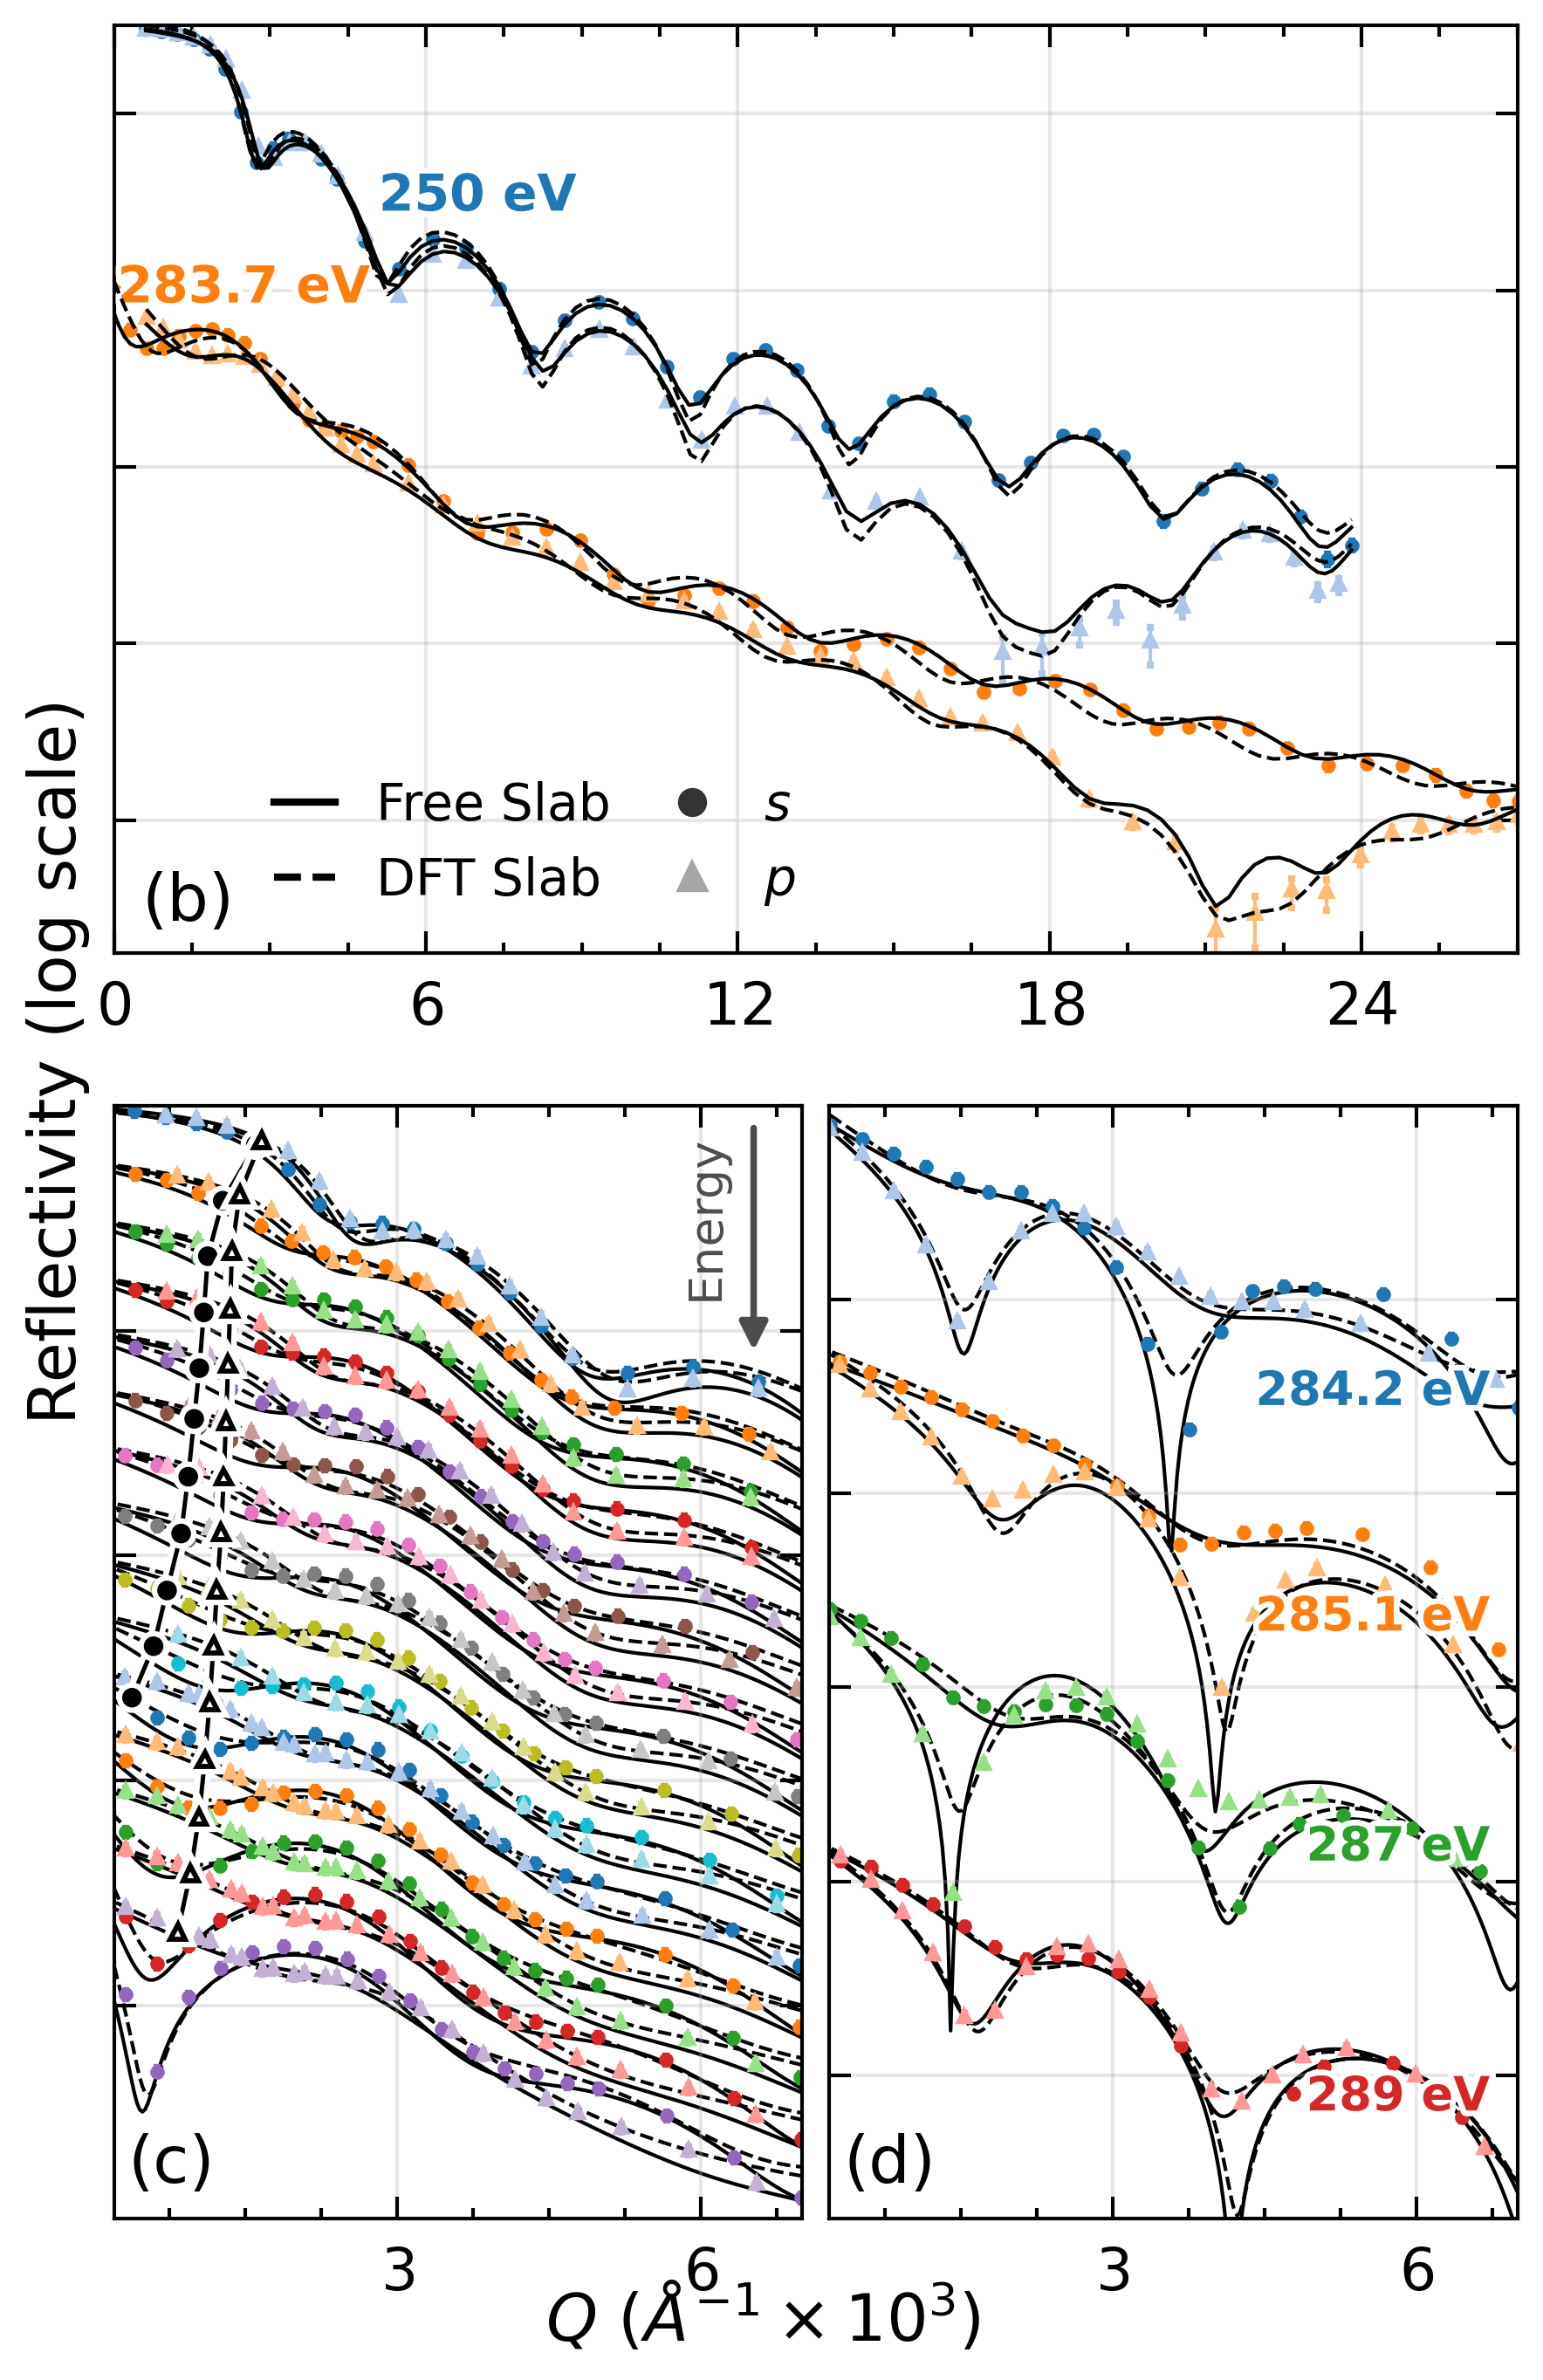

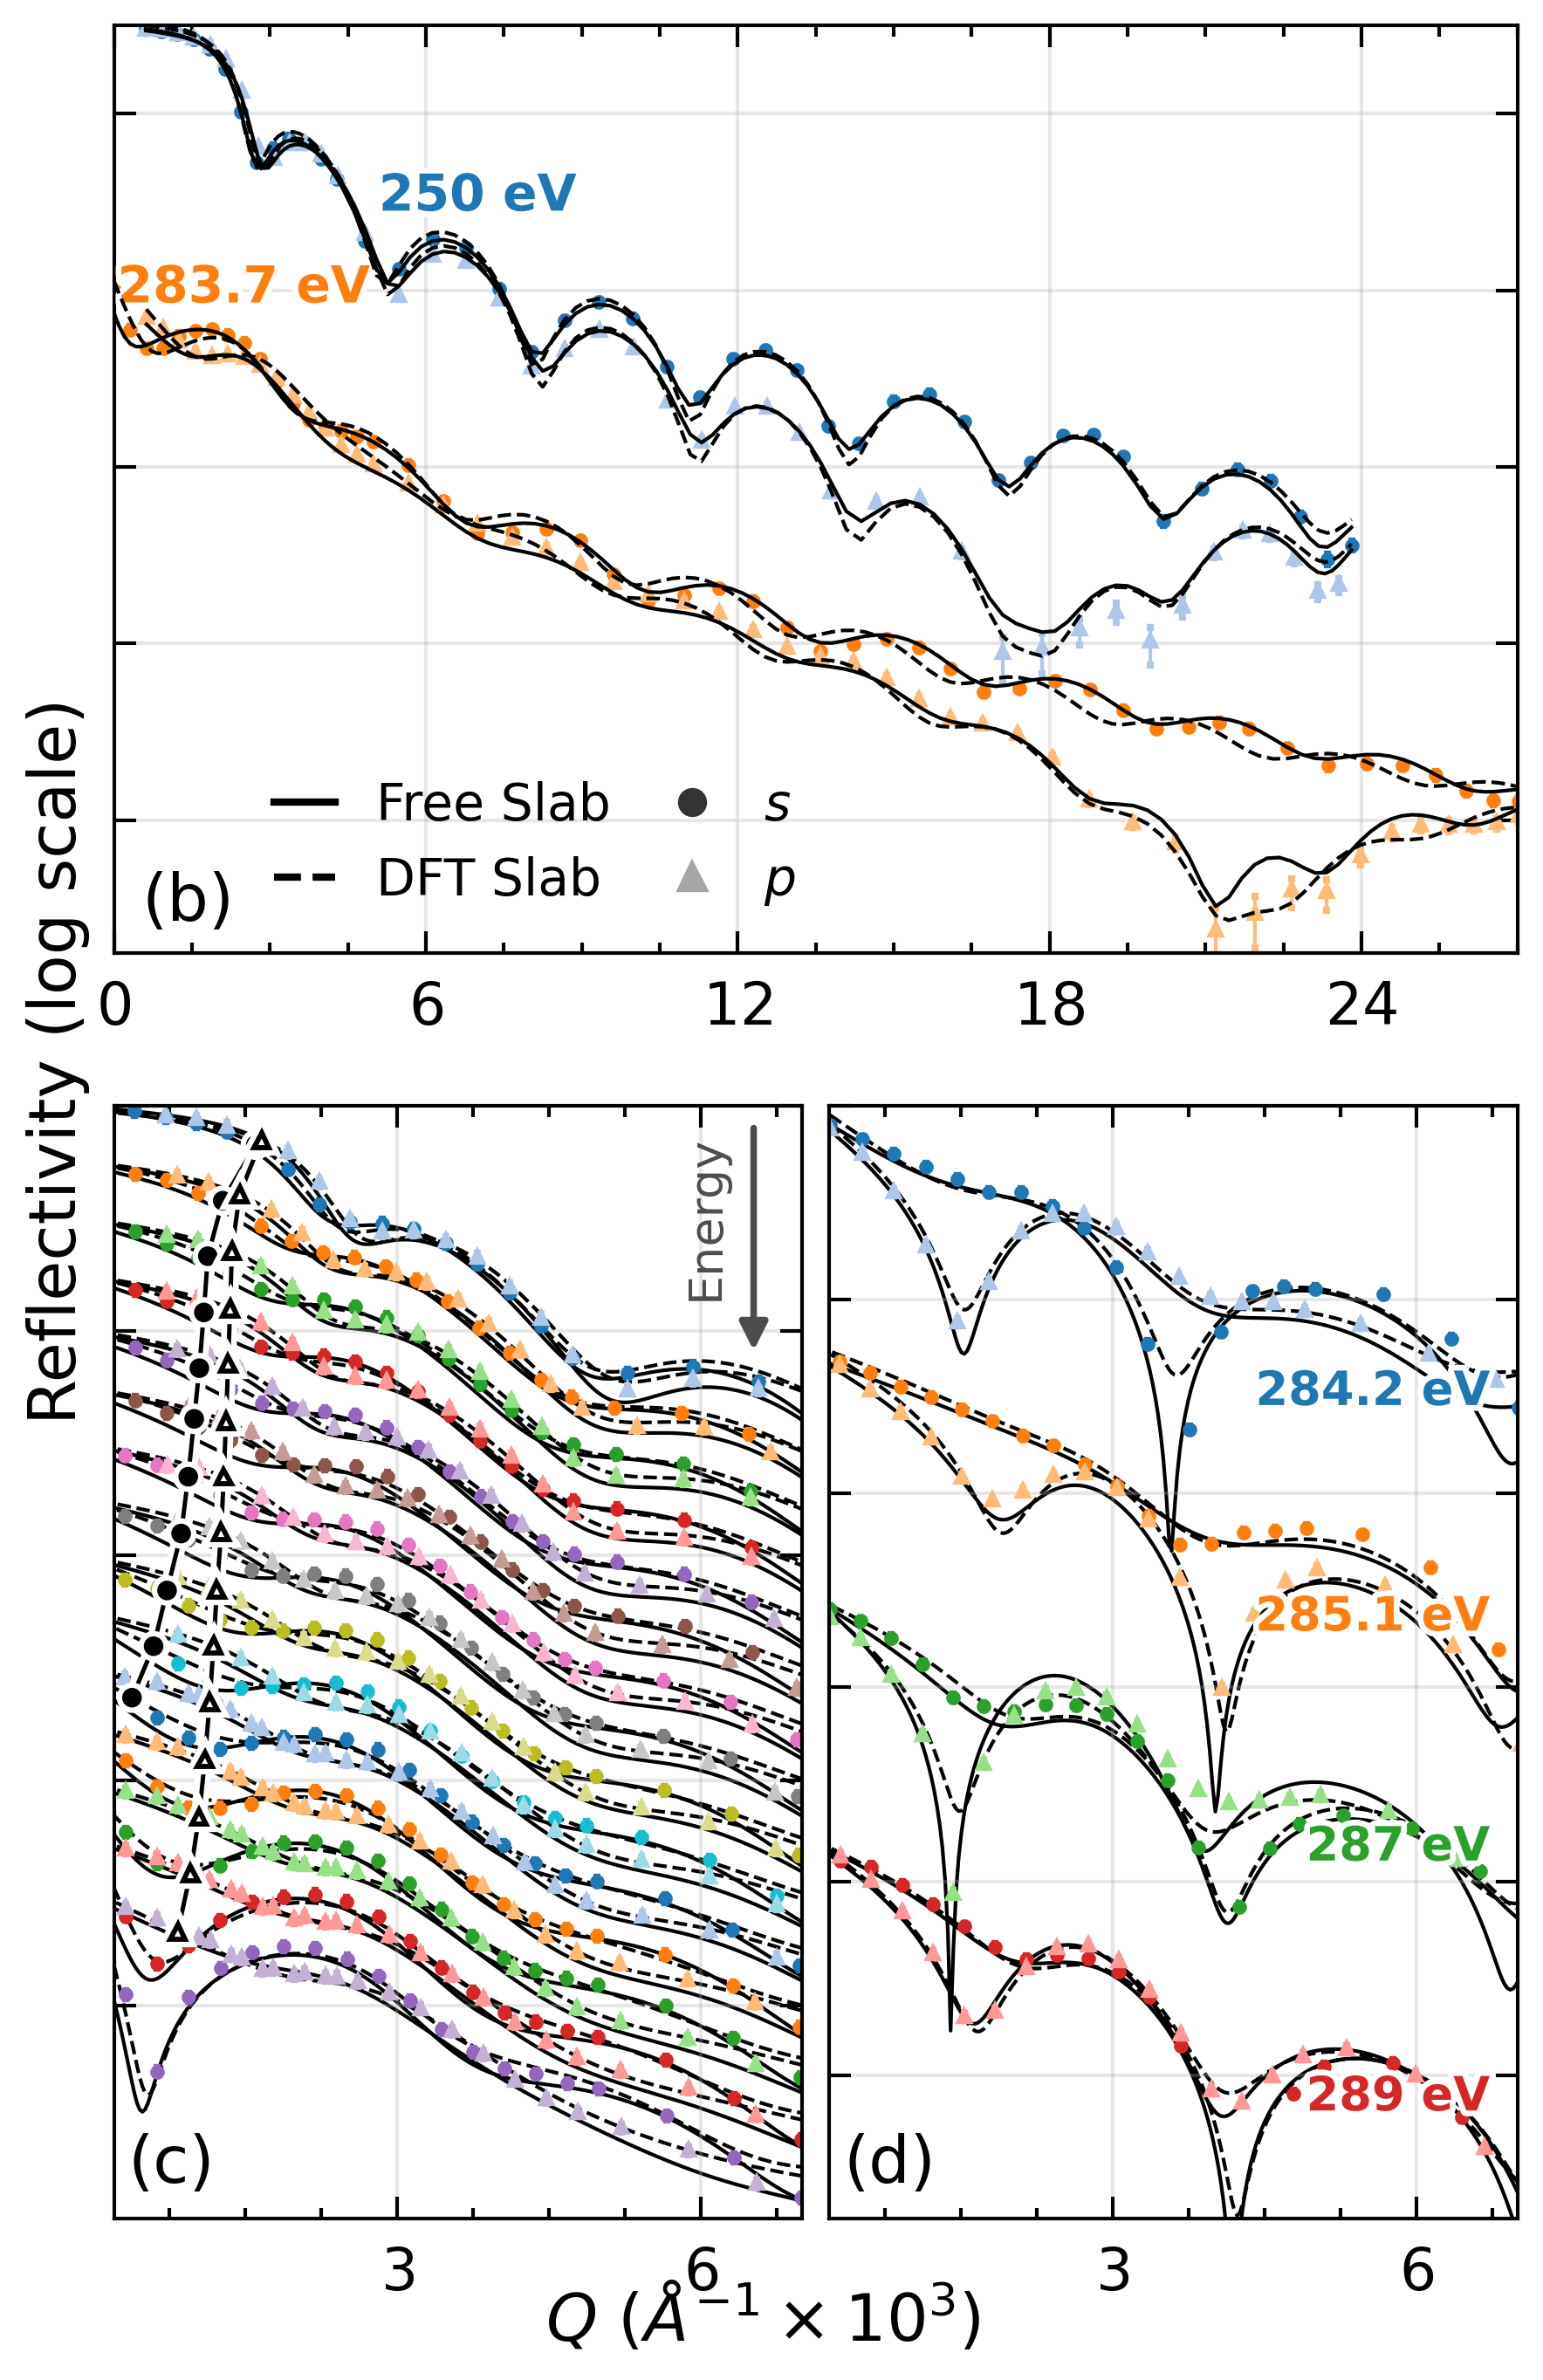

In [15]:
_common_kwargs = {
    "show_energy_labels": True,
    "aniso_y_ticks": (281.0, 282.0, 283.0, 284),
    "show_qc_s_in_b": True,
    "show_qc_p_in_b": True,
    "show_qc_s_in_c": False,
    "show_qc_p_in_c": False,
    "waterfall_qc_source": "model",
    "show_empirical_qc": True,
    "show_anisotropy_maps": False,
    "qc_s_connect": "-",
    "qc_p_connect": "-",
    "qc_connect_linewidth": 0.6,
    "qc_waterfall_markersize": 2,
    "qc_map_markersize": 1,
    "qc_overlay_style": "markers",
}

_ = plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path="fig2_xrr_model_comparison.png",
    **_common_kwargs,
)
fig = plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path="fig2_xrr_model_comparison.pdf",
    **_common_kwargs,
)


In [16]:
"""
Main-text fit-result figure, single PRL column.

Layout
    (a)  R(Q) at 250 eV and 283.7 eV, full Q, Free Slab and DFT Slab
    (b)  short-Q waterfall, pre-edge energies (250 < E < 283.7 eV)
    (c)  short-Q waterfall, post-edge resonant energies (E > 283.7 eV)
    (d)  A(Q, E) map from loaded data via MAKima interpolation
    (e)  A(Q, E) map from the DFT Slab fit
    (f)  A(Q, E) map from the Free Slab fit

Panels (d), (e), (f) share a single thin colorbar.

v10 changes
    - Critical-edge determination is now a fit, not a detection.
      `fresnel_edge_fit` refits the ZnPc decrement against a Parratt
      stack over the low-Q window with the oxide and substrate frozen at
      their globally fitted values. Q_c^2 = 8 k^2 delta is the fitted
      parameter, so it passes continuously through zero and there is no
      branch condition, no threshold, and no termination row set by a
      detector giving up. Each energy returns delta with a
      covariance-derived uncertainty.

      Motivation: the observed edge in this system is governed by the
      silicon substrate, not the film. At 283 eV Q_c(Si) ~ 0.031 A^-1
      against Q_c(ZnPc) ~ 0.013 A^-1, so any single-interface or
      threshold estimator reports the substrate or the first film fringe.
      The layered fit separates them.

    - `edge_zero_crossing` locates E where delta crosses zero by weighted
      regression over the sign change, returning a quotable uncertainty.
      This replaces "the locus terminates around here" with a number.

    - For s polarization on a uniaxial film whose optic axis lies along
      the surface normal, the s wave is a pure ordinary wave at every
      angle and sees only n_xx. The fitted delta is therefore delta_xx
      exactly, with no orientation assumption. p polarization mixes the
      ordinary and extraordinary indices, so `EdgeFit.delta` for p is an
      effective extraordinary decrement and is reported as qualitative.

    - `_q_critical` no longer hardcodes structure[2]. Total external
      reflection for a stack is governed by the largest decrement among
      the media, so the function now maximizes over the supplied layer
      indices.

    - Anisotropy maps use pcolormesh on a real energy axis. The former
      index-based imshow rendered unevenly spaced energies as evenly
      spaced rows, which distorts any locus drawn against arange(n) and
      misplaces a zero crossing read off the map.

    - Q axis labels corrected. Ticks were Q * 100 while the axis label
      read "x 10^3"; the label is now 10^-2 A^-1.

    - `empirical_qc_from_rows` retained for back-compatibility with two
      bugs fixed: the smoothing window now adapts to row length, so the
      raw-data path is no longer erased by a 25-point filter on a
      40-point curve, and NaN infilling no longer flat-extrapolates past
      the last finite sample, which previously manufactured a plateau and
      biased every downstream threshold.

    - `show_delta_qc` defaults True. The gap between the fitted Q_c and
      the tensor-derived Q_c is the absorption and roughness systematic
      and belongs in the SI, so it should be visible while developing.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass
from pathlib import Path

import matplotlib.gridspec as gs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import patheffects as pe
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.interpolate import Akima1DInterpolator
from scipy.optimize import least_squares
from scipy.signal import find_peaks, savgol_filter

_HC_EV_ANG = 12398.4198  # hc in eV * A

# Structure indices for the six-medium stack used throughout:
# 0 vacuum, 1 surface ZnPc, 2 bulk ZnPc, 3 interface ZnPc, 4 SiO2, 5 Si.
_ZNPC_LAYERS = (1, 2, 3)
_OXIDE_LAYER = 4
_SUBSTRATE_LAYER = 5


# ---------------------------------------------------------------------------
# model helpers
# ---------------------------------------------------------------------------


def rxr(x, model, pol):
    """Evaluate ``model`` at ``x`` under polarization ``pol``, restoring state."""
    _pol = model.pol
    model.pol = pol
    try:
        y = model(x)
    finally:
        model.pol = _pol
    return y


def _tensor_component(layer, pol: str) -> tuple[float, float] | None:
    """(delta, beta) for one layer under one polarization, or None."""
    idx = 0 if pol == "s" else 2
    try:
        t = layer.sld.tensor[idx, idx]
        return float(-t.real) if False else float(t.real), float(t.imag)
    except (AttributeError, IndexError, TypeError):
        return None


def _q_critical(
    objective,
    pol: str = "s",
    layer_indices: Sequence[int] = (_ZNPC_LAYERS + (_OXIDE_LAYER, _SUBSTRATE_LAYER)),
) -> float | None:
    """
    Q at the critical angle of the stack for one objective and polarization.

    Total external reflection persists until the wave propagates in *every*
    medium, so the stack critical angle is set by the largest decrement
    present, not by any single layer. The former implementation read
    ``structure[2]`` and therefore reported the bulk ZnPc even though the
    silicon substrate governs the observed edge in this system.

    s polarization uses the in-plane decrement, p the out-of-plane one.
    Returns None when no supplied layer has a positive decrement, which is
    the condition under which no total-external-reflection edge exists.
    """
    try:
        energy = float(objective.model.energy)
        structure = objective.model.structure
    except (AttributeError, TypeError):
        return None
    if pol not in ("s", "p"):
        raise ValueError(f"Unknown pol: {pol!r}")

    deltas: list[float] = []
    for i in layer_indices:
        try:
            comp = _tensor_component(structure[i], pol)
        except (IndexError, TypeError):
            continue
        if comp is None:
            continue
        d = comp[0]
        if np.isfinite(d) and d > 0:
            deltas.append(d)
    if not deltas:
        return None

    d_max = max(deltas)
    lam = _HC_EV_ANG / energy
    # sin(theta_c) = sqrt(2 delta - delta^2); the delta^2 term is retained
    # so the relation stays exact rather than small-angle.
    sin_tc = float(np.sqrt(max(2.0 * d_max - d_max ** 2, 0.0)))
    return float(4.0 * np.pi * sin_tc / lam)


def _model_qc_loci(objectives, energies, **kw) -> tuple[np.ndarray, np.ndarray]:
    """Arrays of Q_c,s(E) and Q_c,p(E) for sorted energies; NaN where absent."""
    qc_s = np.full(len(energies), np.nan)
    qc_p = np.full(len(energies), np.nan)
    for i, energy in enumerate(energies):
        obj = objectives.get(energy)
        if obj is None:
            continue
        for arr, pol in ((qc_s, "s"), (qc_p, "p")):
            v = _q_critical(obj, pol=pol, **kw)
            if v is not None:
                arr[i] = v
    return qc_s, qc_p


# ---------------------------------------------------------------------------
# Parratt edge fit: delta from the low-Q region, per energy, per polarization
# ---------------------------------------------------------------------------


@dataclass(frozen=True)
class EdgeStack:
    """
    Frozen stack description for the edge fit.

    Everything except the ZnPc decrement, its absorption, the top roughness,
    and an overall scale is held fixed at the globally fitted values, so the
    edge fit adds four free parameters against the low-Q points and inherits
    the substrate and oxide from the full refinement.

    Thicknesses and roughnesses in Angstroms; ``film_thick`` is the total
    ZnPc thickness.
    """

    film_thick: float
    film_beta: float
    film_sigma: float
    oxide_delta: float
    oxide_beta: float
    oxide_thick: float
    oxide_sigma: float
    sub_delta: float
    sub_beta: float
    sub_sigma: float


@dataclass(frozen=True)
class EdgeFit:
    """Result of one Parratt edge fit."""

    energy: float
    pol: str
    delta: float
    delta_err: float
    beta: float
    sigma: float
    scale: float
    q_c: float
    q_c_err: float
    redchi: float
    q_lo: float
    q_hi: float
    n_points: int


def stack_from_objective(
    objective,
    pol: str = "s",
    *,
    znpc_layers: Sequence[int] = _ZNPC_LAYERS,
    oxide_layer: int = _OXIDE_LAYER,
    substrate_layer: int = _SUBSTRATE_LAYER,
) -> EdgeStack | None:
    """
    Build an :class:`EdgeStack` from a fitted objective.

    The three ZnPc layers are collapsed to a single effective film, since the
    edge region cannot resolve them and the point of the fit is the decrement
    rather than the profile. Returns None if the structure cannot be read, in
    which case :func:`fresnel_edge_fit` falls back to the single-interface
    form and says so in its docstring.
    """
    try:
        structure = objective.model.structure
        thicks = [float(structure[i].thick.value) for i in znpc_layers]
        betas = []
        sigmas = []
        for i in znpc_layers:
            comp = _tensor_component(structure[i], pol)
            betas.append(0.0 if comp is None else comp[1])
            sigmas.append(float(structure[i].rough.value))
        ox = _tensor_component(structure[oxide_layer], pol)
        sub = _tensor_component(structure[substrate_layer], pol)
        if ox is None or sub is None:
            return None
        total = float(sum(thicks))
        w = np.asarray(thicks) / total if total > 0 else np.ones(len(thicks)) / len(thicks)
        return EdgeStack(
            film_thick=total,
            film_beta=float(np.dot(w, betas)),
            film_sigma=float(sigmas[-1]),
            oxide_delta=ox[0],
            oxide_beta=ox[1],
            oxide_thick=float(structure[oxide_layer].thick.value),
            oxide_sigma=float(structure[oxide_layer].rough.value),
            sub_delta=sub[0],
            sub_beta=sub[1],
            sub_sigma=float(structure[substrate_layer].rough.value),
        )
    except (AttributeError, IndexError, TypeError, ValueError):
        return None


def _kz(q: np.ndarray, k: float, delta: float, beta: float) -> np.ndarray:
    """Vertical wavevector in a medium, complex, valid through delta = 0."""
    return 0.5 * np.sqrt(
        np.asarray(q, dtype=np.complex128) ** 2
        - 8.0 * k ** 2 * delta
        + 8.0j * k ** 2 * beta
    )


def _parratt(
    q: np.ndarray,
    k: float,
    media: Sequence[tuple[float, float]],
    thicks: Sequence[float],
    sigmas: Sequence[float],
) -> np.ndarray:
    """
    Specular reflectivity by Parratt recursion with Nevot-Croce roughness.

    ``media`` runs vacuum first, substrate last, each entry ``(delta, beta)``.
    ``thicks`` has one entry per intermediate layer, ``sigmas`` one per
    interface. Complex arithmetic throughout, so any decrement may be
    negative without a branch condition.
    """
    kzs = [_kz(q, k, d, b) for d, b in media]
    x = np.zeros_like(kzs[0])
    for j in range(len(media) - 2, -1, -1):
        kz_a, kz_b = kzs[j], kzs[j + 1]
        r = (kz_a - kz_b) / (kz_a + kz_b)
        r = r * np.exp(-2.0 * kz_a * kz_b * sigmas[j] ** 2)
        if j + 1 <= len(thicks):
            phase = np.exp(2.0j * kz_b * thicks[j])
        else:
            phase = 1.0
        x = (r + x * phase) / (1.0 + r * x * phase)
    return np.abs(x) ** 2


def _edge_model(
    q: np.ndarray, k: float, stack: EdgeStack | None,
    qc2: float, qa2: float, sigma: float, scale: float,
) -> np.ndarray:
    """Reflectivity for the edge fit; layered when a stack is supplied."""
    norm = 8.0 * k ** 2
    delta, beta = qc2 / norm, qa2 / norm
    if stack is None:
        kz1 = _kz(q, k, 0.0, 0.0)
        kz2 = _kz(q, k, delta, beta)
        r = (kz1 - kz2) / (kz1 + kz2) * np.exp(-2.0 * kz1 * kz2 * sigma ** 2)
        return scale * np.abs(r) ** 2
    media = [
        (0.0, 0.0),
        (delta, beta),
        (stack.oxide_delta, stack.oxide_beta),
        (stack.sub_delta, stack.sub_beta),
    ]
    thicks = [stack.film_thick, stack.oxide_thick]
    sigmas = [sigma, stack.oxide_sigma, stack.sub_sigma]
    return scale * _parratt(q, k, media, thicks, sigmas)


def _window_upper(q: np.ndarray, r: np.ndarray, qc_guess: float,
                  q_hi_scale: float, min_points: int) -> float:
    """
    Upper bound of the fit window.

    The window stops at whichever comes first, the second interference
    minimum or ``q_hi_scale`` times the initial Q_c estimate, then relaxes
    outward if fewer than ``min_points`` measured points remain. Bounding the
    window keeps the fit on the edge rather than on the fringe train, where
    the frozen film thickness would start to dominate the residual.
    """
    logr = np.log(np.clip(r, 1e-30, None))
    d = np.diff(logr)
    minima = np.flatnonzero((d[:-1] < 0) & (d[1:] > 0)) + 1
    cap = q_hi_scale * qc_guess
    candidates = [cap]
    if minima.size >= 2:
        candidates.append(float(q[minima[1]]))
    elif minima.size == 1:
        candidates.append(float(q[minima[0]]))
    hi = min(candidates)
    if int(np.count_nonzero(q <= hi)) < min_points:
        hi = float(q[min(min_points, q.size) - 1])
    return float(hi)


def fresnel_edge_fit(
    q: np.ndarray,
    r: np.ndarray,
    r_err: np.ndarray | None,
    energy: float,
    *,
    pol: str = "s",
    stack: EdgeStack | None = None,
    sigma_init: float = 8.0,
    fix_sigma: bool = False,
    delta_guess: float = 1.0e-3,
    q_lo: float | None = None,
    q_hi: float | None = None,
    q_hi_scale: float = 3.0,
    min_points: int = 8,
    scale_bounds: tuple[float, float] = (0.3, 3.0),
) -> EdgeFit | None:
    """
    Recover the ZnPc decrement from the low-Q edge of one reflectivity curve.

    Fits ``Q_c^2 = 8 k^2 delta`` rather than ``Q_c`` so the parameter passes
    continuously through zero as ``delta`` changes sign. No total-external-
    reflection branch condition, no threshold, and no detection limit: where
    ``delta`` is negative the fit simply returns a negative value and
    ``q_c`` is NaN.

    When ``stack`` is supplied the forward model is a Parratt recursion over
    vacuum, film, oxide, and substrate with everything except the film
    decrement, film absorption, top roughness, and an overall scale frozen at
    the globally fitted values. This matters in the present system because the
    silicon substrate governs the observed edge; a single-interface fit
    returns the substrate rather than the film. Passing ``stack=None`` falls
    back to the single-interface form, which is appropriate only when the
    substrate decrement is smaller than the film's.

    For s polarization on a uniaxial film with the optic axis along the
    surface normal, the s wave is a pure ordinary wave at every angle, so the
    returned ``delta`` is ``delta_xx`` exactly and independently of any
    orientation model. For p polarization the extraordinary and ordinary
    indices mix and the returned value is an effective decrement; treat it as
    qualitative.

    Returns None when the window holds fewer than six points or the fit fails.
    """
    q = np.asarray(q, dtype=np.float64)
    r = np.asarray(r, dtype=np.float64)
    if r_err is None:
        r_err = 0.05 * r
    r_err = np.asarray(r_err, dtype=np.float64)

    k = 2.0 * np.pi * float(energy) / _HC_EV_ANG
    norm = 8.0 * k ** 2
    qc2_0 = norm * delta_guess
    qc_guess = float(np.sqrt(max(qc2_0, 1e-12)))

    good = np.isfinite(r) & (r > 0) & np.isfinite(q)
    if good.sum() < min_points:
        return None
    qg, rg, eg = q[good], r[good], r_err[good]

    lo = float(qg[0]) if q_lo is None else float(q_lo)
    hi = (
        _window_upper(qg, rg, qc_guess, q_hi_scale, min_points)
        if q_hi is None else float(q_hi)
    )
    m = (qg >= lo) & (qg <= hi)
    if m.sum() < 6:
        return None
    qm, rm, em = qg[m], rg[m], eg[m]
    wm = np.where(np.isfinite(em) & (em > 0), em / rm, 0.1)
    wm = np.clip(wm, 1e-3, None)  # fractional error, matching the log residual

    beta_0 = stack.film_beta if stack is not None else 0.2 * delta_guess
    p0 = np.array([qc2_0, max(norm * beta_0, 1e-9), sigma_init, 1.0])
    lo_b = np.array([-4.0 * qc2_0, 0.0, 0.0, scale_bounds[0]])
    hi_b = np.array([4.0 * qc2_0, 4.0 * qc2_0, 60.0, scale_bounds[1]])
    if fix_sigma:
        lo_b[2] = hi_b[2] = sigma_init
        p0[2] = sigma_init
    p0 = np.clip(p0, lo_b + 1e-12, hi_b - 1e-12)

    def resid(p: np.ndarray) -> np.ndarray:
        model = _edge_model(qm, k, stack, *p)
        return (np.log(np.clip(model, 1e-30, None)) - np.log(rm)) / wm

    try:
        sol = least_squares(resid, p0, bounds=(lo_b, hi_b), method="trf",
                            x_scale="jac", max_nfev=4000)
    except (ValueError, FloatingPointError):
        return None
    if not sol.success:
        return None

    dof = max(qm.size - sol.x.size, 1)
    redchi = float(2.0 * sol.cost / dof)
    try:
        _, sv, vt = np.linalg.svd(sol.jac, full_matrices=False)
        sv = np.where(sv > 1e-10 * sv[0], sv, np.inf)
        cov = (vt.T / sv ** 2) @ vt * redchi
        qc2_err = float(np.sqrt(abs(cov[0, 0])))
    except np.linalg.LinAlgError:
        qc2_err = np.nan

    qc2, qa2, sig, scale = (float(v) for v in sol.x)
    if qc2 > 0:
        q_c = float(np.sqrt(qc2))
        q_c_err = float(qc2_err / (2.0 * q_c)) if np.isfinite(qc2_err) else np.nan
    else:
        q_c = q_c_err = np.nan

    return EdgeFit(
        energy=float(energy), pol=pol,
        delta=qc2 / norm, delta_err=qc2_err / norm,
        beta=qa2 / norm, sigma=sig, scale=scale,
        q_c=q_c, q_c_err=q_c_err, redchi=redchi,
        q_lo=lo, q_hi=hi, n_points=int(qm.size),
    )


def delta_from_edges(
    loaded_data,
    energies: Sequence[float],
    *,
    pol: str = "s",
    objectives: dict | None = None,
    **kw,
) -> list[EdgeFit]:
    """
    Run :func:`fresnel_edge_fit` across energies for one polarization.

    When ``objectives`` is supplied the frozen stack is taken per energy from
    the corresponding fitted model, so the oxide and substrate follow the
    global refinement instead of tabulated guesses.
    """
    out: list[EdgeFit] = []
    for energy in energies:
        key = str(energy)
        if key not in loaded_data:
            continue
        d = getattr(loaded_data[key], pol)
        stack = kw.pop("stack", None)
        if stack is None and objectives is not None and energy in objectives:
            stack = stack_from_objective(objectives[energy], pol)
        fit = fresnel_edge_fit(
            d.x, d.y, getattr(d, "y_err", None), float(energy),
            pol=pol, stack=stack, **kw,
        )
        if fit is not None:
            out.append(fit)
    return out


def delta_from_model_edges(
    objectives: dict,
    loaded_data,
    energies: Sequence[float],
    *,
    pol: str = "s",
    **kw,
) -> list[EdgeFit]:
    """
    Apply the identical estimator to simulated reflectivity.

    The model is evaluated on the measured Q points and inherits the measured
    fractional errors, so the fit that runs on the data and the fit that runs
    on the model differ only in the reflectivity values. Any offset between
    the two loci is then attributable to the model, not to the estimator.
    """
    out: list[EdgeFit] = []
    for energy in energies:
        key = str(energy)
        if energy not in objectives or key not in loaded_data:
            continue
        d = getattr(loaded_data[key], pol)
        q = np.asarray(d.x, dtype=np.float64)
        r = np.asarray(rxr(q, objectives[energy].model, pol), dtype=np.float64)
        rel = np.asarray(getattr(d, "y_err", None), dtype=np.float64) / np.asarray(
            d.y, dtype=np.float64
        ) if getattr(d, "y_err", None) is not None else None
        err = None if rel is None else np.abs(rel) * r
        stack = kw.pop("stack", None) or stack_from_objective(
            objectives[energy], pol
        )
        fit = fresnel_edge_fit(
            q, r, err, float(energy), pol=pol, stack=stack, **kw,
        )
        if fit is not None:
            out.append(fit)
    return out


def edge_zero_crossing(
    fits: Sequence[EdgeFit], *, window: float = 1.5,
) -> tuple[float, float]:
    """
    Energy at which the fitted decrement crosses zero, with an uncertainty.

    Only fits within ``window`` eV of the sign change enter the weighted
    linear regression, so curvature away from the crossing does not bias the
    intercept. This is the quantity to quote in place of "the locus
    terminates between X and Y eV", which was a threshold artifact.
    """
    if len(fits) < 3:
        return float("nan"), float("nan")
    e = np.array([f.energy for f in fits], dtype=np.float64)
    d = np.array([f.delta for f in fits], dtype=np.float64)
    s = np.array([f.delta_err for f in fits], dtype=np.float64)
    s = np.where(np.isfinite(s) & (s > 0), s, np.nanmedian(np.abs(d)) or 1.0)
    i = int(np.nanargmin(np.abs(d)))
    m = np.abs(e - e[i]) <= window
    if m.sum() < 3:
        m = np.argsort(np.abs(e - e[i]))[:3]
        m = np.isin(np.arange(e.size), m)
    try:
        p, cov = np.polyfit(e[m], d[m], 1, w=1.0 / s[m], cov=True)
    except (np.linalg.LinAlgError, ValueError):
        return float("nan"), float("nan")
    slope, intercept = float(p[0]), float(p[1])
    if slope == 0.0:
        return float("nan"), float("nan")
    e0 = -intercept / slope
    var = (
        cov[1, 1] + (e0 ** 2) * cov[0, 0] + 2.0 * e0 * cov[0, 1]
    ) / slope ** 2
    return float(e0), float(np.sqrt(abs(var)))


def _edge_fit_arrays(
    fits: Sequence[EdgeFit], energies: Sequence[float],
) -> tuple[np.ndarray, np.ndarray]:
    """Align (q_c, q_c_err) from a list of EdgeFit onto ``energies``."""
    by_e = {round(float(f.energy), 6): f for f in fits}
    qc = np.full(len(energies), np.nan)
    qc_err = np.full(len(energies), np.nan)
    for i, e in enumerate(energies):
        f = by_e.get(round(float(e), 6))
        if f is not None:
            qc[i], qc_err[i] = f.q_c, f.q_c_err
    return qc, qc_err


def fresnel_edge_report(
    loaded_data,
    energies: Sequence[float],
    *,
    pol: str = "s",
    objectives: dict | None = None,
    save_path: Path | str | None = None,
    **kw,
):
    """
    Per-energy diagnostic for the edge fit.

    Shows the measured curve, the fitted window, and the fitted Parratt
    reflectivity, so a referee sees the fit rather than a vertical line.
    Prints the recovered decrement and the zero crossing.
    """
    fits = delta_from_edges(
        loaded_data, energies, pol=pol, objectives=objectives, **kw
    )
    by_e = {round(float(f.energy), 6): f for f in fits}
    n = len(energies)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(2.4 * ncols, 1.8 * nrows), squeeze=False,
    )
    for j, energy in enumerate(energies):
        ax = axes[j // ncols][j % ncols]
        key = str(energy)
        if key not in loaded_data:
            ax.set_visible(False)
            continue
        d = getattr(loaded_data[key], pol)
        ax.semilogy(d.x, np.clip(d.y, 1e-30, None), ".", ms=2, color="0.4")
        f = by_e.get(round(float(energy), 6))
        if f is not None:
            k = 2.0 * np.pi * f.energy / _HC_EV_ANG
            stack = (
                stack_from_objective(objectives[energy], pol)
                if objectives is not None and energy in objectives else None
            )
            qq = np.linspace(f.q_lo, f.q_hi, 300)
            yy = _edge_model(
                qq, k, stack, 8.0 * k ** 2 * f.delta,
                8.0 * k ** 2 * f.beta, f.sigma, f.scale,
            )
            ax.semilogy(qq, yy, "-", lw=1.0, color="crimson")
            ax.axvspan(f.q_lo, f.q_hi, color="crimson", alpha=0.08)
            ax.set_title(
                f"{energy:g} eV  $\\delta$={f.delta:.2e}\n"
                f"$\\chi^2_\\nu$={f.redchi:.2f}  n={f.n_points}",
                fontsize=6.5,
            )
        else:
            ax.set_title(f"{energy:g} eV  (fit failed)", fontsize=6.5)
        ax.tick_params(labelsize=6)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    fig.tight_layout()
    e0, e0_err = edge_zero_crossing(fits)
    print(f"delta_{pol} zero crossing: {e0:.3f} +/- {e0_err:.3f} eV")
    if save_path is not None:
        fig.savefig(Path(save_path), dpi=200, bbox_inches="tight")
        plt.close(fig)
    return fig, fits


def fringe_or_edge_table(
    loaded_data, energies: Sequence[float], *, pol: str = "s",
) -> np.ndarray:
    """
    Decide whether a low-Q hump is an interference fringe or a critical edge.

    Q is wavelength independent, so a film fringe sits at fixed Q across all
    energies while an edge moves with delta(E). Returns the first local
    maximum of log R per energy; a flat column means the feature is
    structural and any locus built from it reports the film thickness.
    """
    out = np.full(len(energies), np.nan)
    for i, energy in enumerate(energies):
        key = str(energy)
        if key not in loaded_data:
            continue
        d = getattr(loaded_data[key], pol)
        q = np.asarray(d.x, dtype=np.float64)
        lr = np.log(np.clip(np.asarray(d.y, dtype=np.float64), 1e-30, None))
        dd = np.diff(lr)
        top = np.flatnonzero((dd[:-1] > 0) & (dd[1:] < 0))
        if top.size:
            out[i] = q[top[0] + 1]
    spread = float(np.nanstd(out))
    print(f"hump Q spread across energies: {spread:.2e} A^-1")
    for e, v in zip(energies, out):
        print(f"  {e:8.2f}  {v:.5f}")
    return out


# ---------------------------------------------------------------------------
# legacy threshold extractor, retained for back-compatibility
# ---------------------------------------------------------------------------


def empirical_qc_from_rows(
    r_grid: np.ndarray,
    q: np.ndarray,
    *,
    method: str = "halffall",
    level: float = 0.5,
    sharpness: float = 1.2,
    hump_prominence: float = 0.05,
    q_start: float | None = None,
    q_max: float | None = None,
    min_span: float | None = None,
    persistence: int = 7,
    smooth_pts: int = 25,
) -> np.ndarray:
    """
    Threshold-based edge locus. Superseded by :func:`fresnel_edge_fit`.

    Retained so existing calls keep working, but the returned Q is where a
    heuristic fires, not an estimate of ``2 k sqrt(2 delta)``. The map between
    the two depends on ``beta/delta`` and therefore on energy, so a locus
    built from this cannot be compared quantitatively against a model
    decrement, and its termination row is a detection limit rather than a zero
    crossing.

    Two bugs are fixed relative to v9.1. The smoothing window now adapts to
    row length, so calling this on a 40-point measured curve no longer erases
    the feature with a 25-point filter. NaN infilling no longer
    flat-extrapolates past the last finite sample, which previously created a
    false plateau and biased the plateau median that every threshold is
    referenced to.
    """
    if method not in ("halffall", "hump"):
        raise ValueError(f"method must be 'halffall' or 'hump', got {method!r}")
    q = np.asarray(q, dtype=np.float64)
    r_grid = np.asarray(r_grid, dtype=np.float64)
    if r_grid.ndim == 1:
        r_grid = r_grid[:, None]
    n_e = r_grid.shape[1]
    dq = float(np.mean(np.diff(q))) if q.size > 1 else 1.0
    out = np.full(n_e, np.nan)

    # Adapt the window to the row so short measured curves survive.
    win = int(min(smooth_pts, max(5, (q.size // 5) | 1)))
    if win % 2 == 0:
        win += 1
    guard = win // 2
    i0 = guard if q_start is None else max(int(np.searchsorted(q, q_start)), guard)
    i_max = min(q.size if q_max is None else int(np.searchsorted(q, q_max)), q.size)
    span_min = win * dq if min_span is None else float(min_span)
    log_level = float(np.log(level))

    for j in range(n_e):
        r = r_grid[:, j]
        good = np.isfinite(r) & (r > 0)
        if good.sum() < win + 2:
            continue
        logr = np.log(np.clip(r, 1e-30, None))
        logr = np.where(good, logr, np.nan)
        if np.isnan(logr).any():
            idx = np.arange(q.size)
            fin = np.isfinite(logr)
            # Interpolate interior gaps only; leave leading and trailing
            # gaps as NaN so no flat extrapolation enters the plateau
            # median or the derivative.
            first, last = int(idx[fin][0]), int(idx[fin][-1])
            interior = slice(first, last + 1)
            logr[interior] = np.interp(
                idx[interior], idx[fin], logr[fin],
            )
            if first > i0 or last < i0 + win:
                continue
        if not np.isfinite(logr[i0:i0 + win]).all():
            continue
        smooth = savgol_filter(np.nan_to_num(logr, nan=logr[np.isfinite(logr)][0]),
                               win, 2)

        if method == "hump":
            seg = smooth[i0:i_max]
            peaks, _ = find_peaks(seg, prominence=hump_prominence)
            if peaks.size == 0:
                continue
            out[j] = q[i0 + peaks[0]]
            continue

        d = savgol_filter(smooth, win, 2, deriv=1, delta=dq)
        plateau = float(np.median(smooth[i0:i0 + win]))
        below = smooth < plateau + log_level
        k = None
        for i in range(i0, max(min(i_max, q.size - persistence), i0 + 1)):
            if below[i] and bool(np.all(below[i:i + persistence])):
                k = i
                break
        if k is None:
            continue
        span = q[k] - q[i0]
        if span < span_min:
            continue
        mean_slope = (smooth[k] - smooth[i0]) / span
        if not (d[k] < sharpness * mean_slope):
            continue
        out[j] = q[k]
    return out


def qc_extraction_report(
    r_grid: np.ndarray,
    q: np.ndarray,
    energies: Sequence[float],
    save_path: Path | str | None = None,
    **extractor_kwargs,
):
    """Diagnostic for the legacy extractor. Prefer :func:`fresnel_edge_report`."""
    qc = empirical_qc_from_rows(r_grid, q, **extractor_kwargs)
    n = len(energies)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(2.2 * ncols, 1.6 * nrows),
        sharex=True, squeeze=False,
    )
    for j, energy in enumerate(energies):
        ax = axes[j // ncols][j % ncols]
        ax.semilogy(q, np.clip(r_grid[:, j], 1e-30, None), lw=0.7, color="0.3")
        if np.isfinite(qc[j]):
            ax.axvline(qc[j], color="crimson", lw=0.8)
        ax.set_title(
            f"{energy:g} eV" + ("" if np.isfinite(qc[j]) else "  (no edge)"),
            fontsize=7,
        )
        ax.tick_params(labelsize=6)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(Path(save_path), dpi=200, bbox_inches="tight")
        plt.close(fig)
    return fig, qc


# ---------------------------------------------------------------------------
# interpolation pipeline for the data anisotropy map
# ---------------------------------------------------------------------------


def collapse_q_clusters(q, y, dq_tol: float = 1e-4):
    q_arr = np.asarray(q, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    order = np.argsort(q_arr)
    q_arr, y_arr = q_arr[order], y_arr[order]

    q_out: list[float] = [float(q_arr[0])]
    y_out: list[float] = [float(y_arr[0])]
    n_in_cluster = 1
    for i in range(1, q_arr.size):
        if q_arr[i] - q_out[-1] < dq_tol:
            y_out[-1] += float(y_arr[i])
            n_in_cluster += 1
        else:
            if n_in_cluster > 1:
                y_out[-1] /= n_in_cluster
            q_out.append(float(q_arr[i]))
            y_out.append(float(y_arr[i]))
            n_in_cluster = 1
    if n_in_cluster > 1:
        y_out[-1] /= n_in_cluster
    return np.asarray(q_out, dtype=np.float64), np.asarray(y_out, dtype=np.float64)


def interp_reflectivity_makima(
    q, y, q_grid, *, dq_tol: float = 1e-4, log_space: bool = True
):
    q_c, y_c = collapse_q_clusters(q, y, dq_tol=dq_tol)
    if log_space:
        y_c = np.log(np.clip(y_c, 1e-30, None))
    interpolator = Akima1DInterpolator(q_c, y_c, method="makima", extrapolate=False)
    out = np.asarray(interpolator(q_grid), dtype=np.float64)
    if log_space:
        out = np.exp(out)
    return out


def _build_common_q_axis(loaded_data, energies, n_pts: int = 1000):
    q_min, q_max = -np.inf, np.inf
    for energy in energies:
        ds = loaded_data[str(energy)]
        for pol in ("s", "p"):
            pol_data = getattr(ds, pol)
            q_min = max(q_min, float(pol_data.x.min()))
            q_max = min(q_max, float(pol_data.x.max()))
    if not np.isfinite(q_min) or not np.isfinite(q_max) or q_max <= q_min:
        raise ValueError("Could not establish a common Q range across energies.")
    return np.linspace(q_min, q_max, n_pts)


def _reflectivity_grids_from_data(loaded_data, energies, common_q):
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        ds = loaded_data[str(energy)]
        s_grid[:, i] = interp_reflectivity_makima(ds.s.x, ds.s.y, common_q)
        p_grid[:, i] = interp_reflectivity_makima(ds.p.x, ds.p.y, common_q)
    return s_grid, p_grid


def _anisotropy_from_grids(s_grid, p_grid):
    denom = s_grid + p_grid
    denom = np.where(np.abs(denom) > 0, denom, np.nan)
    return (p_grid - s_grid) / denom


def _reflectivity_grids_from_model(objectives, energies, common_q):
    s_grid = np.zeros((len(common_q), len(energies)))
    p_grid = np.zeros_like(s_grid)
    for i, energy in enumerate(energies):
        model = objectives[energy].model
        s_grid[:, i] = rxr(common_q, model, "s")
        p_grid[:, i] = rxr(common_q, model, "p")
    return s_grid, p_grid


# ---------------------------------------------------------------------------
# small label helpers
# ---------------------------------------------------------------------------


def _format_energy_tick_label(energy: float) -> str:
    rounded = round(energy)
    if np.isclose(energy, rounded, rtol=0.0, atol=1e-6):
        return f"{int(rounded)}"
    text = f"{energy:.1f}"
    if "." in text:
        text = text.rstrip("0").rstrip(".")
    return text


def _anisotropy_y_tick_positions(
    energies: Sequence[float],
    tick_energies: Sequence[float],
    *,
    match_atol: float = 0.35,
) -> tuple[np.ndarray, list[str]]:
    """Index-space tick positions. Only used when ``map_y_mode='index'``."""
    e_arr = np.asarray(energies, dtype=np.float64)
    if e_arr.size == 0:
        return e_arr, []
    positions: list[float] = []
    labels: list[str] = []
    used: set[int] = set()
    for tick_e in tick_energies:
        idx = int(np.argmin(np.abs(e_arr - float(tick_e))))
        if idx in used or abs(float(e_arr[idx]) - float(tick_e)) > match_atol:
            continue
        used.add(idx)
        positions.append(float(idx))
        labels.append(_format_energy_tick_label(float(tick_e)))
    order = np.argsort(positions)
    return (
        np.asarray(positions, dtype=np.float64)[order],
        [labels[i] for i in order],
    )


def _energy_edges(energies: Sequence[float]) -> np.ndarray:
    """Cell edges for pcolormesh on a possibly uneven energy axis."""
    e = np.asarray(energies, dtype=np.float64)
    if e.size == 1:
        return np.array([e[0] - 0.5, e[0] + 0.5])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate(
        [[e[0] - (mid[0] - e[0])], mid, [e[-1] + (e[-1] - mid[-1])]]
    )


_LABEL_HALO = [pe.withStroke(linewidth=1.6, foreground="white")]
_QC_S_MARKER = dict(marker="v", markerfacecolor="k", markeredgecolor="k")
_QC_P_MARKER = dict(marker="o", markerfacecolor="none", markeredgecolor="k")
_QC_HALO = [pe.withStroke(linewidth=2.2, foreground="white")]


def _annotate_above_curve(
    ax, q_anchor, y_anchor, text, *, color, fontsize=7, offset_pts=5,
    weight="normal",
):
    ann = ax.annotate(
        text, (float(q_anchor), float(y_anchor)),
        xytext=(0, offset_pts), textcoords="offset points",
        ha="center", va="bottom", color=color,
        fontsize=fontsize, fontweight=weight,
    )
    ann.set_path_effects(_LABEL_HALO)
    return ann


def _resolve_per_energy_q(value, n_energies: int, name: str) -> list[float]:
    if np.isscalar(value):
        return [float(value)] * n_energies
    arr = list(value)
    if len(arr) != n_energies:
        raise ValueError(
            f"{name} has length {len(arr)} but reference_energies has "
            f"length {n_energies}."
        )
    return [float(v) for v in arr]


def _waterfall_qc_point(
    pol: str,
    *,
    qc_source: str,
    o_dft,
    pol_data,
    offset: float,
    q_xlim: tuple[float, float],
    empirical_qc_kwargs: dict | None,
    energy: float | None = None,
) -> tuple[float, float] | None:
    """
    Resolve one waterfall Q_c marker as ``(Q, R * offset)``.

    ``qc_source`` accepts ``"model"`` (tensor critical angle), ``"fresnel"``
    (Parratt edge fit on the measured curve, recommended), or ``"empirical"``
    (legacy threshold extractor). The misspelling ``"emperical"`` is
    tolerated.
    """
    source = str(qc_source).strip().lower()
    if source == "emperical":
        source = "empirical"

    if source == "model":
        q_c = _q_critical(o_dft, pol=pol)
        if q_c is None or not (q_xlim[0] <= q_c <= q_xlim[1]):
            return None
        y_qc = float(rxr(np.asarray([q_c]), o_dft.model, pol)[0]) * offset
        return float(q_c), y_qc

    q = np.asarray(pol_data.x, dtype=np.float64)
    r = np.asarray(pol_data.y, dtype=np.float64)
    if q.size < 3 or r.size != q.size:
        return None

    if source == "fresnel":
        e = float(o_dft.model.energy) if energy is None else float(energy)
        fit = fresnel_edge_fit(
            q, r, getattr(pol_data, "y_err", None), e, pol=pol,
            stack=stack_from_objective(o_dft, pol),
            **dict(empirical_qc_kwargs or {}),
        )
        if fit is None or not np.isfinite(fit.q_c):
            return None
        q_c = fit.q_c
    elif source == "empirical":
        qc_arr = empirical_qc_from_rows(
            r[:, None], q, **dict(empirical_qc_kwargs or {})
        )
        q_c = float(qc_arr[0])
    else:
        raise ValueError(
            f"qc_source must be 'model', 'fresnel', or 'empirical', "
            f"got {qc_source!r}."
        )

    if not np.isfinite(q_c) or not (q_xlim[0] <= q_c <= q_xlim[1]):
        return None
    return q_c, float(np.interp(q_c, q, r)) * offset


# ---------------------------------------------------------------------------
# panel renderers
# ---------------------------------------------------------------------------


def _plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data,
    *,
    offset_scale: float = -1.5,
    q_xlim: tuple[float, float] = (0.002, 0.07),
    show_qc_s: bool = False,
    show_qc_p: bool = False,
    qc_source: str = "fresnel",
    empirical_qc_kwargs: dict | None = None,
    qc_markersize: float = 3.0,
    qc_s_connect: str | None = None,
    qc_p_connect: str | None = None,
    qc_connect_linewidth: float = 0.6,
    plot_energy_labels: bool = False,
    energy_label_pad_frac: float = 0.04,
    smarker: str = "o",
    pmarker: str = "^",
    every: int = 4,
):
    """
    Vertically offset waterfall of s and p reflectivity for each energy.

    The Q_c locus is off by default; the maps carry it. When toggled on, s and
    p are distinguished by marker shape and fill so the distinction survives
    grayscale and column-width reproduction. ``qc_source`` defaults to the
    Parratt edge fit.
    """
    cmap = plt.colormaps.get_cmap("tab20")
    xdata = np.linspace(0.0005, 0.27, 1000)
    offset = 1.0
    last_y_min = 1e-12
    qc_pts: dict[str, list[tuple[float, float]]] = {"s": [], "p": []}

    for idx, energy in enumerate(energies):
        if energy not in exp_objectives:
            continue
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        offset = 10 ** (offset_scale * idx)

        if plot_energy_labels:
            pad = energy_label_pad_frac * (q_xlim[1] - q_xlim[0])
            q_anchor = q_xlim[1] - pad
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * offset
            ann = ax.annotate(
                f"{_format_energy_tick_label(float(energy))} eV",
                xy=(q_anchor, y_e), xytext=(0, 3),
                textcoords="offset points", ha="right", va="bottom",
                color=cmap(2 * idx % 20), fontsize=6.5,
                fontweight="bold", zorder=11,
            )
            ann.set_path_effects(_LABEL_HALO)

        for pol, m in (("s", smarker), ("p", pmarker)):
            pol_data = getattr(data, pol)
            color = cmap(2 * idx % 20) if pol == "s" else cmap((2 * idx + 1) % 20)
            ax.errorbar(
                pol_data.x, pol_data.y * offset, yerr=pol_data.y_err * offset,
                lw=0, color=color, capsize=0.5, marker=m,
                elinewidth=0.5, markersize=1, markerfacecolor=color,
                markevery=every, errorevery=every,
            )
        for pol in ("s", "p"):
            ax.plot(xdata, rxr(xdata, o_exp.model, pol) * offset,
                    color="k", lw=0.5, ls="-", zorder=-10)
            ax.plot(xdata, rxr(xdata, o_dft.model, pol) * offset,
                    color="k", lw=0.5, ls="--", zorder=-10)
        last_y_min = offset * getattr(data, "p").y.min()

        smark = _QC_S_MARKER | {"marker": smarker}
        pmark = _QC_P_MARKER | {"marker": pmarker}
        for pol, show, style in (("s", show_qc_s, smark), ("p", show_qc_p, pmark)):
            if not show:
                continue
            pt = _waterfall_qc_point(
                pol, qc_source=qc_source, o_dft=o_dft,
                pol_data=getattr(data, pol), offset=offset, q_xlim=q_xlim,
                empirical_qc_kwargs=empirical_qc_kwargs, energy=energy,
            )
            if pt is None:
                continue
            q_c, y_qc = pt
            qc_pts[pol].append((q_c, y_qc))
            line, = ax.plot(
                [q_c], [y_qc], linestyle="None", markersize=qc_markersize,
                markeredgewidth=0.7, zorder=9, **style,
            )
            line.set_path_effects(_QC_HALO)

    for pol, connect in (("s", qc_s_connect), ("p", qc_p_connect)):
        if connect is None or len(qc_pts[pol]) < 2:
            continue
        xs, ys = zip(*qc_pts[pol])
        conn, = ax.plot(
            xs, ys, linestyle=connect, linewidth=qc_connect_linewidth,
            color="k", marker="None", zorder=8,
        )
        conn.set_path_effects(_QC_HALO)

    ax.set_yscale("log")
    ax.set_xlim(*q_xlim)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)
    ax.set_xticks([0.03, 0.06])
    ax.set_xticklabels([r"$3$", r"$6$"])


def _plot_reference_pair(
    ax, comparison_energies, exp_objectives, dft_objectives, loaded_data,
    *,
    energy_label_q,
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    s_swatch: str = "0.20",
    p_swatch: str = "0.65",
    smarker="o",
    pmarker="^",
    every=4,
):
    """Panel (a). Data and model traces at the two long-q energies."""
    cmap = plt.colormaps.get_cmap("tab20")
    last_y_min = 1e-12
    q_anchors = _resolve_per_energy_q(
        energy_label_q, len(comparison_energies), "energy_label_q",
    )

    for i, energy in enumerate(comparison_energies):
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        scale = 10 ** (-3 * i)

        for pol, m in (("s", smarker), ("p", pmarker)):
            col = cmap(2 * i) if pol == "s" else cmap(2 * i + 1)
            pol_data = getattr(data, pol)
            ax.errorbar(
                pol_data.x, pol_data.y * scale, yerr=pol_data.y_err * scale,
                lw=0, color=col, capsize=0.5, marker=m, elinewidth=0.5,
                markersize=1, markerfacecolor=col, markevery=every,
                errorevery=every,
            )
        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            ax.plot(pol_data.x, rxr(pol_data.x, o_exp.model, pol) * scale,
                    color="k", lw=0.5, zorder=10)
            ax.plot(pol_data.x, rxr(pol_data.x, o_dft.model, pol) * scale,
                    color="k", lw=0.5, ls="--", zorder=10)
        last_y_min = scale * getattr(data, "p").y.min()

        if show_energy_labels:
            q_anchor = q_anchors[i]
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * scale
            _annotate_above_curve(
                ax, q_anchor, y_e,
                f"{_format_energy_tick_label(float(energy))} eV",
                color=cmap(2 * i), fontsize=7,
                offset_pts=label_offset_pts, weight="bold",
            )

    ax.set_xlim(0.002, 0.27)
    ax.set_yscale("log")
    ax.set_yticklabels([])
    ax.set_xticks([0.0, 0.06, 0.12, 0.18, 0.24])
    ax.set_xticklabels([r"$0$", r"$6$", r"$12$", r"$18$", r"$24$"])
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(last_y_min, 1)

    handles = [
        Line2D([], [], color="k", lw=1, ls="-", label="Free Slab"),
        Line2D([], [], color="k", lw=1, ls="--", label="DFT Slab"),
        Line2D([], [], color=s_swatch, marker=smarker, markersize=3,
               markerfacecolor=s_swatch, linestyle="None", label=r"$s$"),
        Line2D([], [], color=p_swatch, marker=pmarker, markersize=3,
               markerfacecolor=p_swatch, linestyle="None", label=r"$p$"),
    ]
    ax.legend(
        handles=handles, loc="lower center", fontsize=7, ncols=2,
        handlelength=1.2, columnspacing=1.0,
        framealpha=0, fancybox=False, bbox_to_anchor=(0.3, 0),
    )


def _plot_anisotropy_map(
    ax, grid, q, energies, cmap, norm, panel_label,
    show_yticks=True, y_mode: str = "energy",
):
    """
    Render one A(Q, E) map and return ``(mappable, y_coords)``.

    ``y_mode='energy'`` uses pcolormesh on the true energy axis, so a locus
    drawn against the returned coordinates is a genuine curve in (Q, E) and a
    zero crossing read off the panel sits at the energy it appears to. The
    former index-based imshow rendered uneven energy spacing as even rows.
    """
    grid_arr = np.asarray(grid, dtype=np.float64)
    q_arr = np.asarray(q, dtype=np.float64)
    e_arr = np.asarray(energies, dtype=np.float64)
    if grid_arr.shape != (q_arr.size, e_arr.size):
        raise ValueError(
            f"grid shape {grid_arr.shape} != (len(q), len(energies)) "
            f"= ({q_arr.size}, {e_arr.size})."
        )
    ax.set_facecolor("#ECECEC")

    if y_mode == "energy":
        q_edges = np.concatenate([
            [q_arr[0] - 0.5 * (q_arr[1] - q_arr[0])],
            0.5 * (q_arr[:-1] + q_arr[1:]),
            [q_arr[-1] + 0.5 * (q_arr[-1] - q_arr[-2])],
        ])
        mappable = ax.pcolormesh(
            q_edges, _energy_edges(e_arr), grid_arr.T,
            cmap=cmap, norm=norm, shading="flat", rasterized=True,
        )
        y_coords = e_arr
        y_lo, y_hi = float(_energy_edges(e_arr)[0]), float(_energy_edges(e_arr)[-1])
    elif y_mode == "index":
        y_lo, y_hi = -0.5, e_arr.size - 0.5
        mappable = ax.imshow(
            grid_arr.T, origin="lower", aspect="auto",
            extent=(float(q_arr[0]), float(q_arr[-1]), y_lo, y_hi),
            cmap=cmap, norm=norm, interpolation="nearest", rasterized=True,
        )
        y_coords = np.arange(e_arr.size, dtype=np.float64)
    else:
        raise ValueError(f"y_mode must be 'energy' or 'index', got {y_mode!r}")

    ax.set_xlim(float(q_arr[0]), float(q_arr[-1]))
    ax.set_ylim(y_lo, y_hi)
    ax.set_autoscale_on(False)
    ax.tick_params(axis="both", labelsize=8)
    if not show_yticks:
        ax.tick_params(labelleft=False)
    txt = ax.text(
        0.05, 0.96, panel_label, transform=ax.transAxes,
        va="top", ha="left", fontsize=9, color="white", fontweight="bold",
    )
    txt.set_path_effects([pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()])
    return mappable, y_coords


def _overlay_qc_contours(
    ax, s_grid, p_grid, q, y_coords,
    *,
    level: float = 0.5,
    n_plateau: int = 25,
    linewidth: float = 0.8,
    label_ends: bool = False,
    label_fontsize: float = 7.0,
):
    """
    Edge loci as level-set contours of per-row plateau-normalized R.

    Presentation aid only. R always decays through the level eventually, so
    this locus never terminates; where the edge vanishes it collapses toward
    low Q. Use the fitted overlay when edge existence is the claim.
    """
    for grid, ls, lbl in ((s_grid, "-", "s"), (p_grid, "--", "p")):
        plateau = np.nanmedian(grid[:n_plateau, :], axis=0)
        plateau = np.where(np.isfinite(plateau) & (plateau > 0), plateau, np.nan)
        cs = ax.contour(
            q, y_coords, (grid / plateau[None, :]).T, levels=[level],
            colors="k", linewidths=linewidth, linestyles=ls, zorder=10,
        )
        try:
            cs.set_path_effects(_QC_HALO)
        except AttributeError:
            for coll in cs.collections:
                coll.set_path_effects(_QC_HALO)
        if label_ends:
            segs = [s for lev in cs.allsegs for s in lev if len(s) > 1]
            if not segs:
                continue
            seg = max(segs, key=len)
            target = np.percentile(y_coords, 55 if lbl == "s" else 45)
            i_lab = int(np.argmin(np.abs(seg[:, 1] - target)))
            side = 1 if lbl == "s" else -1
            txt = ax.annotate(
                rf"${lbl}$", (float(seg[i_lab, 0]), float(seg[i_lab, 1])),
                xytext=(4 * side, 0), textcoords="offset points",
                fontsize=label_fontsize, color="k",
                ha="left" if side > 0 else "right", va="center", style="italic",
            )
            txt.set_path_effects(_LABEL_HALO)


def _overlay_qc_on_map(
    ax, y_coords, qc_s, qc_p,
    *,
    qc_s_err: np.ndarray | None = None,
    qc_p_err: np.ndarray | None = None,
    as_curve: bool = True,
    markersize: float = 2.6,
    linewidth: float = 0.8,
    label_ends: bool = False,
    label_fontsize: float = 7.0,
):
    """
    Draw Q_c,s(E) and Q_c,p(E) against the panel's own y coordinates.

    NaNs break the locus. With the fitted estimator the break occurs where the
    fitted decrement turns negative, which is the physical disappearance of
    total external reflection rather than a detection limit. Horizontal error
    bars carry the fit uncertainty when supplied.
    """
    y = np.asarray(y_coords, dtype=np.float64)
    for qc, err, style, lbl in (
        (qc_s, qc_s_err, _QC_S_MARKER, "s"),
        (qc_p, qc_p_err, _QC_P_MARKER, "p"),
    ):
        qc = np.asarray(qc, dtype=np.float64)
        fin = np.isfinite(qc)
        if not fin.any():
            continue
        if err is not None and np.isfinite(np.asarray(err, float)[fin]).any():
            container = ax.errorbar(
                qc, y, xerr=np.asarray(err, dtype=np.float64),
                linestyle="-" if as_curve else "None", linewidth=linewidth,
                color="k", markersize=markersize, markeredgewidth=0.7,
                elinewidth=0.5, capsize=0.0, zorder=10, **style,
            )
            container.lines[0].set_path_effects(_QC_HALO)
        else:
            line, = ax.plot(
                qc, y, linestyle="-" if as_curve else "None",
                linewidth=linewidth, color="k", markersize=markersize,
                markeredgewidth=0.7, markevery=2 if as_curve else 1,
                zorder=10, **style,
            )
            line.set_path_effects(_QC_HALO)
        if label_ends:
            idx = np.where(fin)[0]
            target = np.percentile(y, 55 if lbl == "s" else 45)
            i_lab = int(idx[np.argmin(np.abs(y[idx] - target))])
            side = 1 if lbl == "s" else -1
            txt = ax.annotate(
                rf"${lbl}$", (float(qc[i_lab]), float(y[i_lab])),
                xytext=(4 * side, 0), textcoords="offset points",
                fontsize=label_fontsize, color="k",
                ha="left" if side > 0 else "right", va="center", style="italic",
            )
            txt.set_path_effects(_LABEL_HALO)


# ---------------------------------------------------------------------------
# anisotropy-map row (panels d, e, f)
# ---------------------------------------------------------------------------


def _render_anisotropy_maps(
    fig, ax_d, ax_e, ax_f, cax,
    exp_objectives, dft_objectives, loaded_data, common_energies,
    *,
    aniso_energy_max,
    n_q_aniso,
    aniso_cmap,
    vmax_aniso,
    aniso_y_ticks,
    show_qc_on_maps,
    show_empirical_qc,
    show_delta_qc,
    qc_overlay_style,
    qc_contour_level,
    qc_contour_n_plateau,
    qc_map_markersize,
    qc_map_linewidth,
    empirical_qc_kwargs,
    map_y_mode,
    edge_fit_kwargs,
):
    """Render the data, DFT, and Free anisotropy maps with edge overlays."""
    aniso_energies = sorted(
        e for e in common_energies
        if e <= aniso_energy_max and str(e) in loaded_data
    )
    if len(aniso_energies) < 2:
        raise ValueError("Need at least two energies <= aniso_energy_max.")

    common_q = _build_common_q_axis(loaded_data, aniso_energies, n_pts=n_q_aniso)
    s_data, p_data = _reflectivity_grids_from_data(
        loaded_data, aniso_energies, common_q,
    )
    s_dft, p_dft = _reflectivity_grids_from_model(
        dft_objectives, aniso_energies, common_q,
    )
    s_free, p_free = _reflectivity_grids_from_model(
        exp_objectives, aniso_energies, common_q,
    )
    a_data = _anisotropy_from_grids(s_data, p_data)
    a_dft = _anisotropy_from_grids(s_dft, p_dft)
    a_free = _anisotropy_from_grids(s_free, p_free)

    if vmax_aniso is None:
        finite = np.concatenate([
            np.abs(a[np.isfinite(a)]).ravel() for a in (a_data, a_dft, a_free)
        ])
        vmax_aniso = (
            1.0 if finite.size == 0
            else float(np.clip(np.nanpercentile(finite, 99.0), 1e-3, 1.0))
        )
    norm = TwoSlopeNorm(vmin=-vmax_aniso, vcenter=0.0, vmax=vmax_aniso)

    try:
        cmap_obj = plt.get_cmap(aniso_cmap)
    except ValueError:
        cmap_obj = sns.color_palette(aniso_cmap, as_cmap=True)
    cmap_obj = cmap_obj.copy()
    cmap_obj.set_bad("#ECECEC")

    mesh, y_d = _plot_anisotropy_map(
        ax_d, a_data, common_q, aniso_energies, cmap_obj, norm,
        "(d) data", y_mode=map_y_mode,
    )
    _, y_e = _plot_anisotropy_map(
        ax_e, a_dft, common_q, aniso_energies, cmap_obj, norm,
        "(e) DFT", show_yticks=False, y_mode=map_y_mode,
    )
    _, y_f = _plot_anisotropy_map(
        ax_f, a_free, common_q, aniso_energies, cmap_obj, norm,
        "(f) Free", show_yticks=False, y_mode=map_y_mode,
    )

    valid = ("fresnel", "markers", "contour", "none")
    if qc_overlay_style not in valid:
        raise ValueError(f"qc_overlay_style must be one of {valid}.")
    ek = dict(edge_fit_kwargs or {})
    eq = dict(empirical_qc_kwargs or {})

    if qc_overlay_style == "fresnel":
        # The identical estimator runs on the measured curves and on both
        # model simulations sampled at the measured Q, so any offset between
        # panels is attributable to the model rather than to the estimator.
        if show_empirical_qc:
            fs = delta_from_edges(
                loaded_data, aniso_energies, pol="s",
                objectives=dft_objectives, **ek,
            )
            fp = delta_from_edges(
                loaded_data, aniso_energies, pol="p",
                objectives=dft_objectives, **ek,
            )
            qs, qs_e = _edge_fit_arrays(fs, aniso_energies)
            qp, qp_e = _edge_fit_arrays(fp, aniso_energies)
            _overlay_qc_on_map(
                ax_d, y_d, qs, qp, qc_s_err=qs_e, qc_p_err=qp_e,
                as_curve=False, markersize=qc_map_markersize,
                linewidth=qc_map_linewidth,
            )
            e0, e0_err = edge_zero_crossing(fs)
            print(f"delta_xx zero crossing (data): {e0:.3f} +/- {e0_err:.3f} eV")
        if show_qc_on_maps:
            for ax_m, y_m, objs, lab in (
                (ax_e, y_e, dft_objectives, True),
                (ax_f, y_f, exp_objectives, False),
            ):
                fs = delta_from_model_edges(
                    objs, loaded_data, aniso_energies, pol="s", **ek,
                )
                fp = delta_from_model_edges(
                    objs, loaded_data, aniso_energies, pol="p", **ek,
                )
                qs, _ = _edge_fit_arrays(fs, aniso_energies)
                qp, _ = _edge_fit_arrays(fp, aniso_energies)
                _overlay_qc_on_map(
                    ax_m, y_m, qs, qp, as_curve=True,
                    markersize=qc_map_markersize,
                    linewidth=qc_map_linewidth, label_ends=lab,
                )
    elif qc_overlay_style == "markers":
        if show_empirical_qc:
            _overlay_qc_on_map(
                ax_d, y_d,
                empirical_qc_from_rows(s_data, common_q, **eq),
                empirical_qc_from_rows(p_data, common_q, **eq),
                as_curve=False, markersize=qc_map_markersize,
                linewidth=qc_map_linewidth,
            )
        if show_qc_on_maps:
            for ax_m, y_m, sg, pg, lab in (
                (ax_e, y_e, s_dft, p_dft, True),
                (ax_f, y_f, s_free, p_free, False),
            ):
                _overlay_qc_on_map(
                    ax_m, y_m,
                    empirical_qc_from_rows(sg, common_q, **eq),
                    empirical_qc_from_rows(pg, common_q, **eq),
                    as_curve=True, markersize=qc_map_markersize,
                    linewidth=qc_map_linewidth, label_ends=lab,
                )
    elif qc_overlay_style == "contour":
        ck = dict(level=qc_contour_level, n_plateau=qc_contour_n_plateau,
                  linewidth=qc_map_linewidth)
        if show_empirical_qc:
            _overlay_qc_contours(ax_d, s_data, p_data, common_q, y_d, **ck)
        if show_qc_on_maps:
            _overlay_qc_contours(ax_e, s_dft, p_dft, common_q, y_e,
                                 label_ends=True, **ck)
            _overlay_qc_contours(ax_f, s_free, p_free, common_q, y_f, **ck)

    if show_delta_qc:
        # Tensor-derived Q_c as thin dotted curves. The gap between these and
        # the fitted loci is the absorption and roughness shift of the
        # observable edge, which is the systematic to quote in the SI.
        for ax_m, y_m, objs in (
            (ax_e, y_e, dft_objectives), (ax_f, y_f, exp_objectives),
        ):
            qd_s, qd_p = _model_qc_loci(objs, aniso_energies)
            for qd in (qd_s, qd_p):
                if np.isfinite(qd).any():
                    ax_m.plot(qd, y_m, ls=":", lw=0.6, color="k",
                              zorder=9, path_effects=_QC_HALO)

    if map_y_mode == "energy":
        ax_d.set_yticks([t for t in aniso_y_ticks
                         if min(aniso_energies) <= t <= max(aniso_energies)])
        ax_d.set_yticklabels(
            [_format_energy_tick_label(float(t)) for t in ax_d.get_yticks()],
            rotation=-45,
        )
    else:
        pos, lab = _anisotropy_y_tick_positions(aniso_energies, aniso_y_ticks)
        ax_d.set_yticks(pos)
        ax_d.set_yticklabels(lab, rotation=-45)
    ax_d.tick_params(axis="y", labelleft=True, labelsize=8)
    ax_e.tick_params(axis="y", labelleft=False)
    ax_f.tick_params(axis="y", labelleft=False)
    ax_d.set_ylabel("Energy (eV)")

    for ax in (ax_d, ax_e, ax_f):
        ax.set_xlim(float(common_q[0]), float(common_q[-1]))
        ax.set_xticks([0.03, 0.06])
        ax.set_xticklabels([r"$3$", r"$6$"])

    cb = fig.colorbar(mesh, cax=cax, extend="both")
    cb.set_label(r"Anisotropy", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    cb.set_ticks([-0.25, 0.0, 0.25])
    cb.set_ticklabels([r"$-1/4$", r"$0$", r"$1/4$"])
    cb.outline.set_linewidth(0.5)


# ---------------------------------------------------------------------------
# main entry point
# ---------------------------------------------------------------------------


def plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    smarker="o",
    pmarker="^",
    aniso_energy_max: float = 283.7,
    n_q_aniso: int = 1000,
    aniso_cmap: str = "coolwarm",
    vmax_aniso: float | None = None,
    aniso_y_ticks: Sequence[float] = (280.0, 281.0, 282.0, 283.0),
    reference_energies: Sequence[float] = (250.0, 283.7),
    energy_label_q: float | Sequence[float] = (0.07, 0.025),
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    legend_s_swatch: str = "0.20",
    legend_p_swatch: str = "0.65",
    show_anisotropy_maps: bool = True,
    show_qc_on_maps: bool = True,
    show_empirical_qc: bool = True,
    show_delta_qc: bool = True,
    qc_overlay_style: str = "fresnel",
    qc_contour_level: float = 0.5,
    qc_contour_n_plateau: int = 25,
    qc_map_markersize: float = 2.6,
    qc_map_linewidth: float = 0.8,
    empirical_qc_kwargs: dict | None = None,
    edge_fit_kwargs: dict | None = None,
    map_y_mode: str = "energy",
    show_qc_s_in_b: bool = False,
    show_qc_p_in_b: bool = False,
    show_qc_s_in_c: bool = False,
    show_qc_p_in_c: bool = False,
    waterfall_qc_source: str = "fresnel",
    qc_waterfall_markersize: float = 3.0,
    qc_s_connect: str | None = None,
    qc_p_connect: str | None = None,
    qc_connect_linewidth: float = 0.6,
    energy_labels_in_c: bool = True,
    energy_label_pad_frac: float = 0.04,
):
    """
    Build the main-text fit-result figure.

    Parameters new or changed in v10
    --------------------------------
    qc_overlay_style
        ``"fresnel"`` (default) fits the ZnPc decrement per energy against a
        Parratt stack over the low-Q window and draws the resulting Q_c with
        fit uncertainties on (d) and as curves on (e) and (f). The locus
        breaks where the fitted decrement turns negative, so the break is the
        physical loss of total external reflection rather than a detection
        threshold. ``"markers"`` and ``"contour"`` retain the v9 threshold and
        level-set behavior; ``"none"`` disables overlays.
    edge_fit_kwargs
        Forwarded to :func:`fresnel_edge_fit`. Useful keys are ``q_hi_scale``,
        ``min_points``, ``sigma_init``, ``fix_sigma``, and ``delta_guess``.
    map_y_mode
        ``"energy"`` (default) draws the maps with pcolormesh on the true
        energy axis. ``"index"`` restores the v9 imshow behavior, which
        renders uneven energy spacing as even rows and distorts any locus.
    show_delta_qc
        Now defaults True. The offset between the tensor Q_c and the fitted
        Q_c is the absorption and roughness systematic.
    waterfall_qc_source
        ``"fresnel"`` (default), ``"model"``, or ``"empirical"``.
    """
    fig_width = 3.35
    _ROW_A, _ROW_BC, _ROW_MAP = 1.0, 1.2, 0.45
    _HSPACE = 0.15
    _TOP, _BOTTOM = 0.97, 0.08
    _EVERY = 3

    if show_anisotropy_maps:
        height_ratios = [_ROW_A, _ROW_BC, _ROW_MAP]
        fig_height = 5.8
    else:
        height_ratios = [_ROW_A, _ROW_BC]

        def _usable_per_unit(rows):
            s = sum(rows)
            return s + (len(rows) - 1) * _HSPACE * (s / len(rows))

        u_on = (_TOP - _BOTTOM) * 5.8 / _usable_per_unit(
            [_ROW_A, _ROW_BC, _ROW_MAP]
        )
        fig_height = u_on * _usable_per_unit(height_ratios) / (_TOP - _BOTTOM)

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=600)
    outer = gs.GridSpec(
        len(height_ratios), 1, figure=fig, height_ratios=height_ratios,
        hspace=_HSPACE, left=0.13, right=0.93, top=_TOP, bottom=_BOTTOM,
    )
    ax_top = fig.add_subplot(outer[0])
    inner_mid = outer[1].subgridspec(1, 2, wspace=0.04)
    ax_bl = fig.add_subplot(inner_mid[0])
    ax_br = fig.add_subplot(inner_mid[1])

    if show_anisotropy_maps:
        inner_bot = outer[2].subgridspec(
            1, 4, width_ratios=[1.0, 1.0, 1.0, 0.06], wspace=0.04,
        )
        ax_d = fig.add_subplot(inner_bot[0])
        ax_e = fig.add_subplot(inner_bot[1], sharey=ax_d)
        ax_f = fig.add_subplot(inner_bot[2], sharey=ax_d)
        cax = fig.add_subplot(inner_bot[3])
        map_axes = (ax_d, ax_e, ax_f)
    else:
        ax_d = ax_e = ax_f = cax = None
        map_axes = ()

    for ax in (ax_top, ax_bl, ax_br, *map_axes):
        ax.tick_params(axis="both", labelsize=8)
        ax.xaxis.label.set_size(9)
        ax.yaxis.label.set_size(9)

    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    _plot_reference_pair(
        ax_top, np.asarray(reference_energies, dtype=np.float64),
        exp_objectives, dft_objectives, loaded_data,
        energy_label_q=energy_label_q, label_offset_pts=label_offset_pts,
        show_energy_labels=show_energy_labels,
        s_swatch=legend_s_swatch, p_swatch=legend_p_swatch,
        smarker=smarker, pmarker=pmarker, every=_EVERY,
    )

    non_resonant = [e for e in common_energies if 250.0 < e < 283.7]
    resonant = [e for e in common_energies if e > 283.7]
    for ax, ens, oscale, sflag, pflag, labels in (
        (ax_bl, non_resonant, -0.5, show_qc_s_in_b, show_qc_p_in_b, False),
        (ax_br, resonant, -2.5, show_qc_s_in_c, show_qc_p_in_c,
         energy_labels_in_c),
    ):
        _plot_vertically_offset_energies(
            ax, ens, exp_objectives, dft_objectives, loaded_data,
            offset_scale=oscale, show_qc_s=sflag, show_qc_p=pflag,
            qc_source=waterfall_qc_source,
            empirical_qc_kwargs=(
                edge_fit_kwargs if waterfall_qc_source == "fresnel"
                else empirical_qc_kwargs
            ),
            qc_markersize=qc_waterfall_markersize,
            qc_s_connect=qc_s_connect, qc_p_connect=qc_p_connect,
            qc_connect_linewidth=qc_connect_linewidth,
            plot_energy_labels=labels,
            energy_label_pad_frac=energy_label_pad_frac,
            every=_EVERY,
        )
    for ax in (ax_bl, ax_br):
        ax.set_ylabel("")
        ax.set_yticklabels([])

    if show_anisotropy_maps:
        _render_anisotropy_maps(
            fig, ax_d, ax_e, ax_f, cax,
            exp_objectives, dft_objectives, loaded_data, common_energies,
            aniso_energy_max=aniso_energy_max, n_q_aniso=n_q_aniso,
            aniso_cmap=aniso_cmap, vmax_aniso=vmax_aniso,
            aniso_y_ticks=aniso_y_ticks, show_qc_on_maps=show_qc_on_maps,
            show_empirical_qc=show_empirical_qc, show_delta_qc=show_delta_qc,
            qc_overlay_style=qc_overlay_style,
            qc_contour_level=qc_contour_level,
            qc_contour_n_plateau=qc_contour_n_plateau,
            qc_map_markersize=qc_map_markersize,
            qc_map_linewidth=qc_map_linewidth,
            empirical_qc_kwargs=empirical_qc_kwargs,
            map_y_mode=map_y_mode, edge_fit_kwargs=edge_fit_kwargs,
        )

    refl_label_y = 0.68 if show_anisotropy_maps else 0.55
    fig.text(0.08, refl_label_y, "Reflectivity (log scale)",
             va="center", rotation="vertical", fontsize=9)
    # Ticks are Q * 100, so the axis carries 10^-2 A^-1. The v9 label read
    # "x 10^3", which was inconsistent with every tick in the figure.
    fig.text(0.5, 0.04, r"$Q$ ($10^{-2}\,\AA^{-1}$)",
             ha="center", va="center", fontsize=9)

    for ax, lbl in zip([ax_top, ax_bl, ax_br], ["(b)", "(c)", "(d)"]):
        ax.text(0.02, 0.02, lbl, transform=ax.transAxes,
                va="bottom", ha="left", fontsize=9)
    ax_bl.annotate(
        "", xy=(0.93, 0.78), xytext=(0.93, 0.98),
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-|>", color="0.30", lw=0.9,
                        shrinkA=0, shrinkB=0, mutation_scale=8),
        annotation_clip=False,
    )
    ax_bl.text(0.86, 0.9, "Energy", transform=ax_bl.transAxes,
               rotation=90, ha="center", va="center",
               fontsize=6.5, color="0.30")
    fig.align_labels()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.show()
    return fig


def plot_anisotropy_maps_si(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    aniso_energy_max: float = 283.7,
    n_q_aniso: int = 1000,
    aniso_cmap: str = "coolwarm",
    vmax_aniso: float | None = None,
    aniso_y_ticks: Sequence[float] = (280.0, 281.0, 282.0, 283.0),
    q_ticks: Sequence[float] = (0.02, 0.04, 0.06),
    fig_width: float = 3.35,
    panel_height: float = 0.85,
    panel_labels: Sequence[str] = ("(a) data", "(b) Free", "(c) DFT"),
    show_qc_on_maps: bool = True,
    show_empirical_qc: bool = True,
    show_delta_qc: bool = True,
    qc_overlay_style: str = "fresnel",
    qc_contour_level: float = 0.5,
    qc_contour_n_plateau: int = 25,
    qc_map_markersize: float = 2.6,
    qc_map_linewidth: float = 0.8,
    empirical_qc_kwargs: dict | None = None,
    edge_fit_kwargs: dict | None = None,
    map_y_mode: str = "energy",
):
    """
    Standalone SI figure of the A(Q, E) anisotropy maps, single column.

    Shares the grid pipeline, normalization, and edge-fit machinery with
    :func:`plot_all_results`, so the two figures stay consistent when
    extraction parameters change.
    """
    valid = ("fresnel", "markers", "contour", "none")
    if qc_overlay_style not in valid:
        raise ValueError(f"qc_overlay_style must be one of {valid}.")

    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    aniso_energies = sorted(
        e for e in common_energies
        if e <= aniso_energy_max and str(e) in loaded_data
    )
    if len(aniso_energies) < 2:
        raise ValueError("Need at least two energies <= aniso_energy_max.")

    common_q = _build_common_q_axis(loaded_data, aniso_energies, n_pts=n_q_aniso)
    s_data, p_data = _reflectivity_grids_from_data(
        loaded_data, aniso_energies, common_q,
    )
    s_free, p_free = _reflectivity_grids_from_model(
        exp_objectives, aniso_energies, common_q,
    )
    s_dft, p_dft = _reflectivity_grids_from_model(
        dft_objectives, aniso_energies, common_q,
    )
    a_data = _anisotropy_from_grids(s_data, p_data)
    a_free = _anisotropy_from_grids(s_free, p_free)
    a_dft = _anisotropy_from_grids(s_dft, p_dft)

    if vmax_aniso is None:
        finite = np.concatenate([
            np.abs(a[np.isfinite(a)]).ravel() for a in (a_data, a_free, a_dft)
        ])
        vmax_aniso = (
            1.0 if finite.size == 0
            else float(np.clip(np.nanpercentile(finite, 99.0), 1e-3, 1.0))
        )
    norm = TwoSlopeNorm(vmin=-vmax_aniso, vcenter=0.0, vmax=vmax_aniso)

    try:
        cmap_obj = plt.get_cmap(aniso_cmap)
    except ValueError:
        cmap_obj = sns.color_palette(aniso_cmap, as_cmap=True)
    cmap_obj = cmap_obj.copy()
    cmap_obj.set_bad("#ECECEC")

    n_rows = 3
    fig_height = n_rows * panel_height + 0.85
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=600)
    outer = gs.GridSpec(
        n_rows, 2, figure=fig, width_ratios=[1.0, 0.035],
        hspace=0.14, wspace=0.03, left=0.15, right=0.86,
        top=1.0 - 0.10 / fig_height, bottom=0.55 / fig_height,
    )
    ax_data = fig.add_subplot(outer[0, 0])
    ax_free = fig.add_subplot(outer[1, 0], sharex=ax_data)
    ax_dft = fig.add_subplot(outer[2, 0], sharex=ax_data)
    cax = fig.add_subplot(outer[:, 1])

    mesh = None
    y_coords: list[np.ndarray] = []
    for (ax, grid), lbl in zip(
        ((ax_data, a_data), (ax_free, a_free), (ax_dft, a_dft)), panel_labels
    ):
        m, y = _plot_anisotropy_map(
            ax, grid, common_q, aniso_energies, cmap_obj, norm, lbl,
            y_mode=map_y_mode,
        )
        y_coords.append(y)
        if mesh is None:
            mesh = m
    y_dat, y_fre, y_dftm = y_coords

    ek = dict(edge_fit_kwargs or {})
    eq = dict(empirical_qc_kwargs or {})

    if qc_overlay_style == "fresnel":
        if show_empirical_qc:
            fs = delta_from_edges(loaded_data, aniso_energies, pol="s",
                                  objectives=dft_objectives, **ek)
            fp = delta_from_edges(loaded_data, aniso_energies, pol="p",
                                  objectives=dft_objectives, **ek)
            qs, qs_e = _edge_fit_arrays(fs, aniso_energies)
            qp, qp_e = _edge_fit_arrays(fp, aniso_energies)
            _overlay_qc_on_map(
                ax_data, y_dat, qs, qp, qc_s_err=qs_e, qc_p_err=qp_e,
                as_curve=False, markersize=qc_map_markersize,
                linewidth=qc_map_linewidth,
            )
        if show_qc_on_maps:
            for ax_m, y_m, objs, lab in (
                (ax_free, y_fre, exp_objectives, True),
                (ax_dft, y_dftm, dft_objectives, False),
            ):
                fs = delta_from_model_edges(objs, loaded_data, aniso_energies,
                                            pol="s", **ek)
                fp = delta_from_model_edges(objs, loaded_data, aniso_energies,
                                            pol="p", **ek)
                qs, _ = _edge_fit_arrays(fs, aniso_energies)
                qp, _ = _edge_fit_arrays(fp, aniso_energies)
                _overlay_qc_on_map(
                    ax_m, y_m, qs, qp, as_curve=True,
                    markersize=qc_map_markersize,
                    linewidth=qc_map_linewidth, label_ends=lab,
                )
    elif qc_overlay_style == "markers":
        if show_empirical_qc:
            _overlay_qc_on_map(
                ax_data, y_dat,
                empirical_qc_from_rows(s_data, common_q, **eq),
                empirical_qc_from_rows(p_data, common_q, **eq),
                as_curve=False, markersize=qc_map_markersize,
                linewidth=qc_map_linewidth,
            )
        if show_qc_on_maps:
            for ax_m, y_m, sg, pg, lab in (
                (ax_free, y_fre, s_free, p_free, True),
                (ax_dft, y_dftm, s_dft, p_dft, False),
            ):
                _overlay_qc_on_map(
                    ax_m, y_m,
                    empirical_qc_from_rows(sg, common_q, **eq),
                    empirical_qc_from_rows(pg, common_q, **eq),
                    as_curve=True, markersize=qc_map_markersize,
                    linewidth=qc_map_linewidth, label_ends=lab,
                )
    elif qc_overlay_style == "contour":
        ck = dict(level=qc_contour_level, n_plateau=qc_contour_n_plateau,
                  linewidth=qc_map_linewidth)
        if show_empirical_qc:
            _overlay_qc_contours(ax_data, s_data, p_data, common_q, y_dat, **ck)
        if show_qc_on_maps:
            _overlay_qc_contours(ax_free, s_free, p_free, common_q, y_fre,
                                 label_ends=True, **ck)
            _overlay_qc_contours(ax_dft, s_dft, p_dft, common_q, y_dftm, **ck)

    if show_delta_qc:
        for ax_m, y_m, objs in (
            (ax_free, y_fre, exp_objectives), (ax_dft, y_dftm, dft_objectives),
        ):
            qd_s, qd_p = _model_qc_loci(objs, aniso_energies)
            for qd in (qd_s, qd_p):
                if np.isfinite(qd).any():
                    ax_m.plot(qd, y_m, ls=":", lw=0.6, color="k",
                              zorder=9, path_effects=_QC_HALO)

    q_tick_labels = [rf"${int(round(qt * 100))}$" for qt in q_ticks]
    for ax in (ax_data, ax_free, ax_dft):
        if map_y_mode == "energy":
            ax.set_yticks([t for t in aniso_y_ticks
                           if min(aniso_energies) <= t <= max(aniso_energies)])
            ax.set_yticklabels(
                [_format_energy_tick_label(float(t)) for t in ax.get_yticks()]
            )
        else:
            pos, lab = _anisotropy_y_tick_positions(aniso_energies, aniso_y_ticks)
            ax.set_yticks(pos)
            ax.set_yticklabels(lab)
        ax.tick_params(axis="both", labelsize=8)
        ax.set_xticks(list(q_ticks))
    ax_dft.set_xticklabels(q_tick_labels)
    for ax in (ax_data, ax_free):
        ax.tick_params(labelbottom=False)

    ax_dft.set_xlabel(r"$Q$ ($10^{-2}\,\AA^{-1}$)", fontsize=9)
    fig.text(0.03, (outer.top + outer.bottom) / 2.0, "Energy (eV)",
             va="center", rotation="vertical", fontsize=9)

    cb = fig.colorbar(mesh, cax=cax, extend="both")
    cb.set_label(r"Anisotropy", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    cb.set_ticks([-0.25, 0.0, 0.25])
    cb.set_ticklabels([r"$-1/4$", r"$0$", r"$1/4$"])
    cb.outline.set_linewidth(0.5)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.close(fig)
    else:
        plt.show()
    return fig

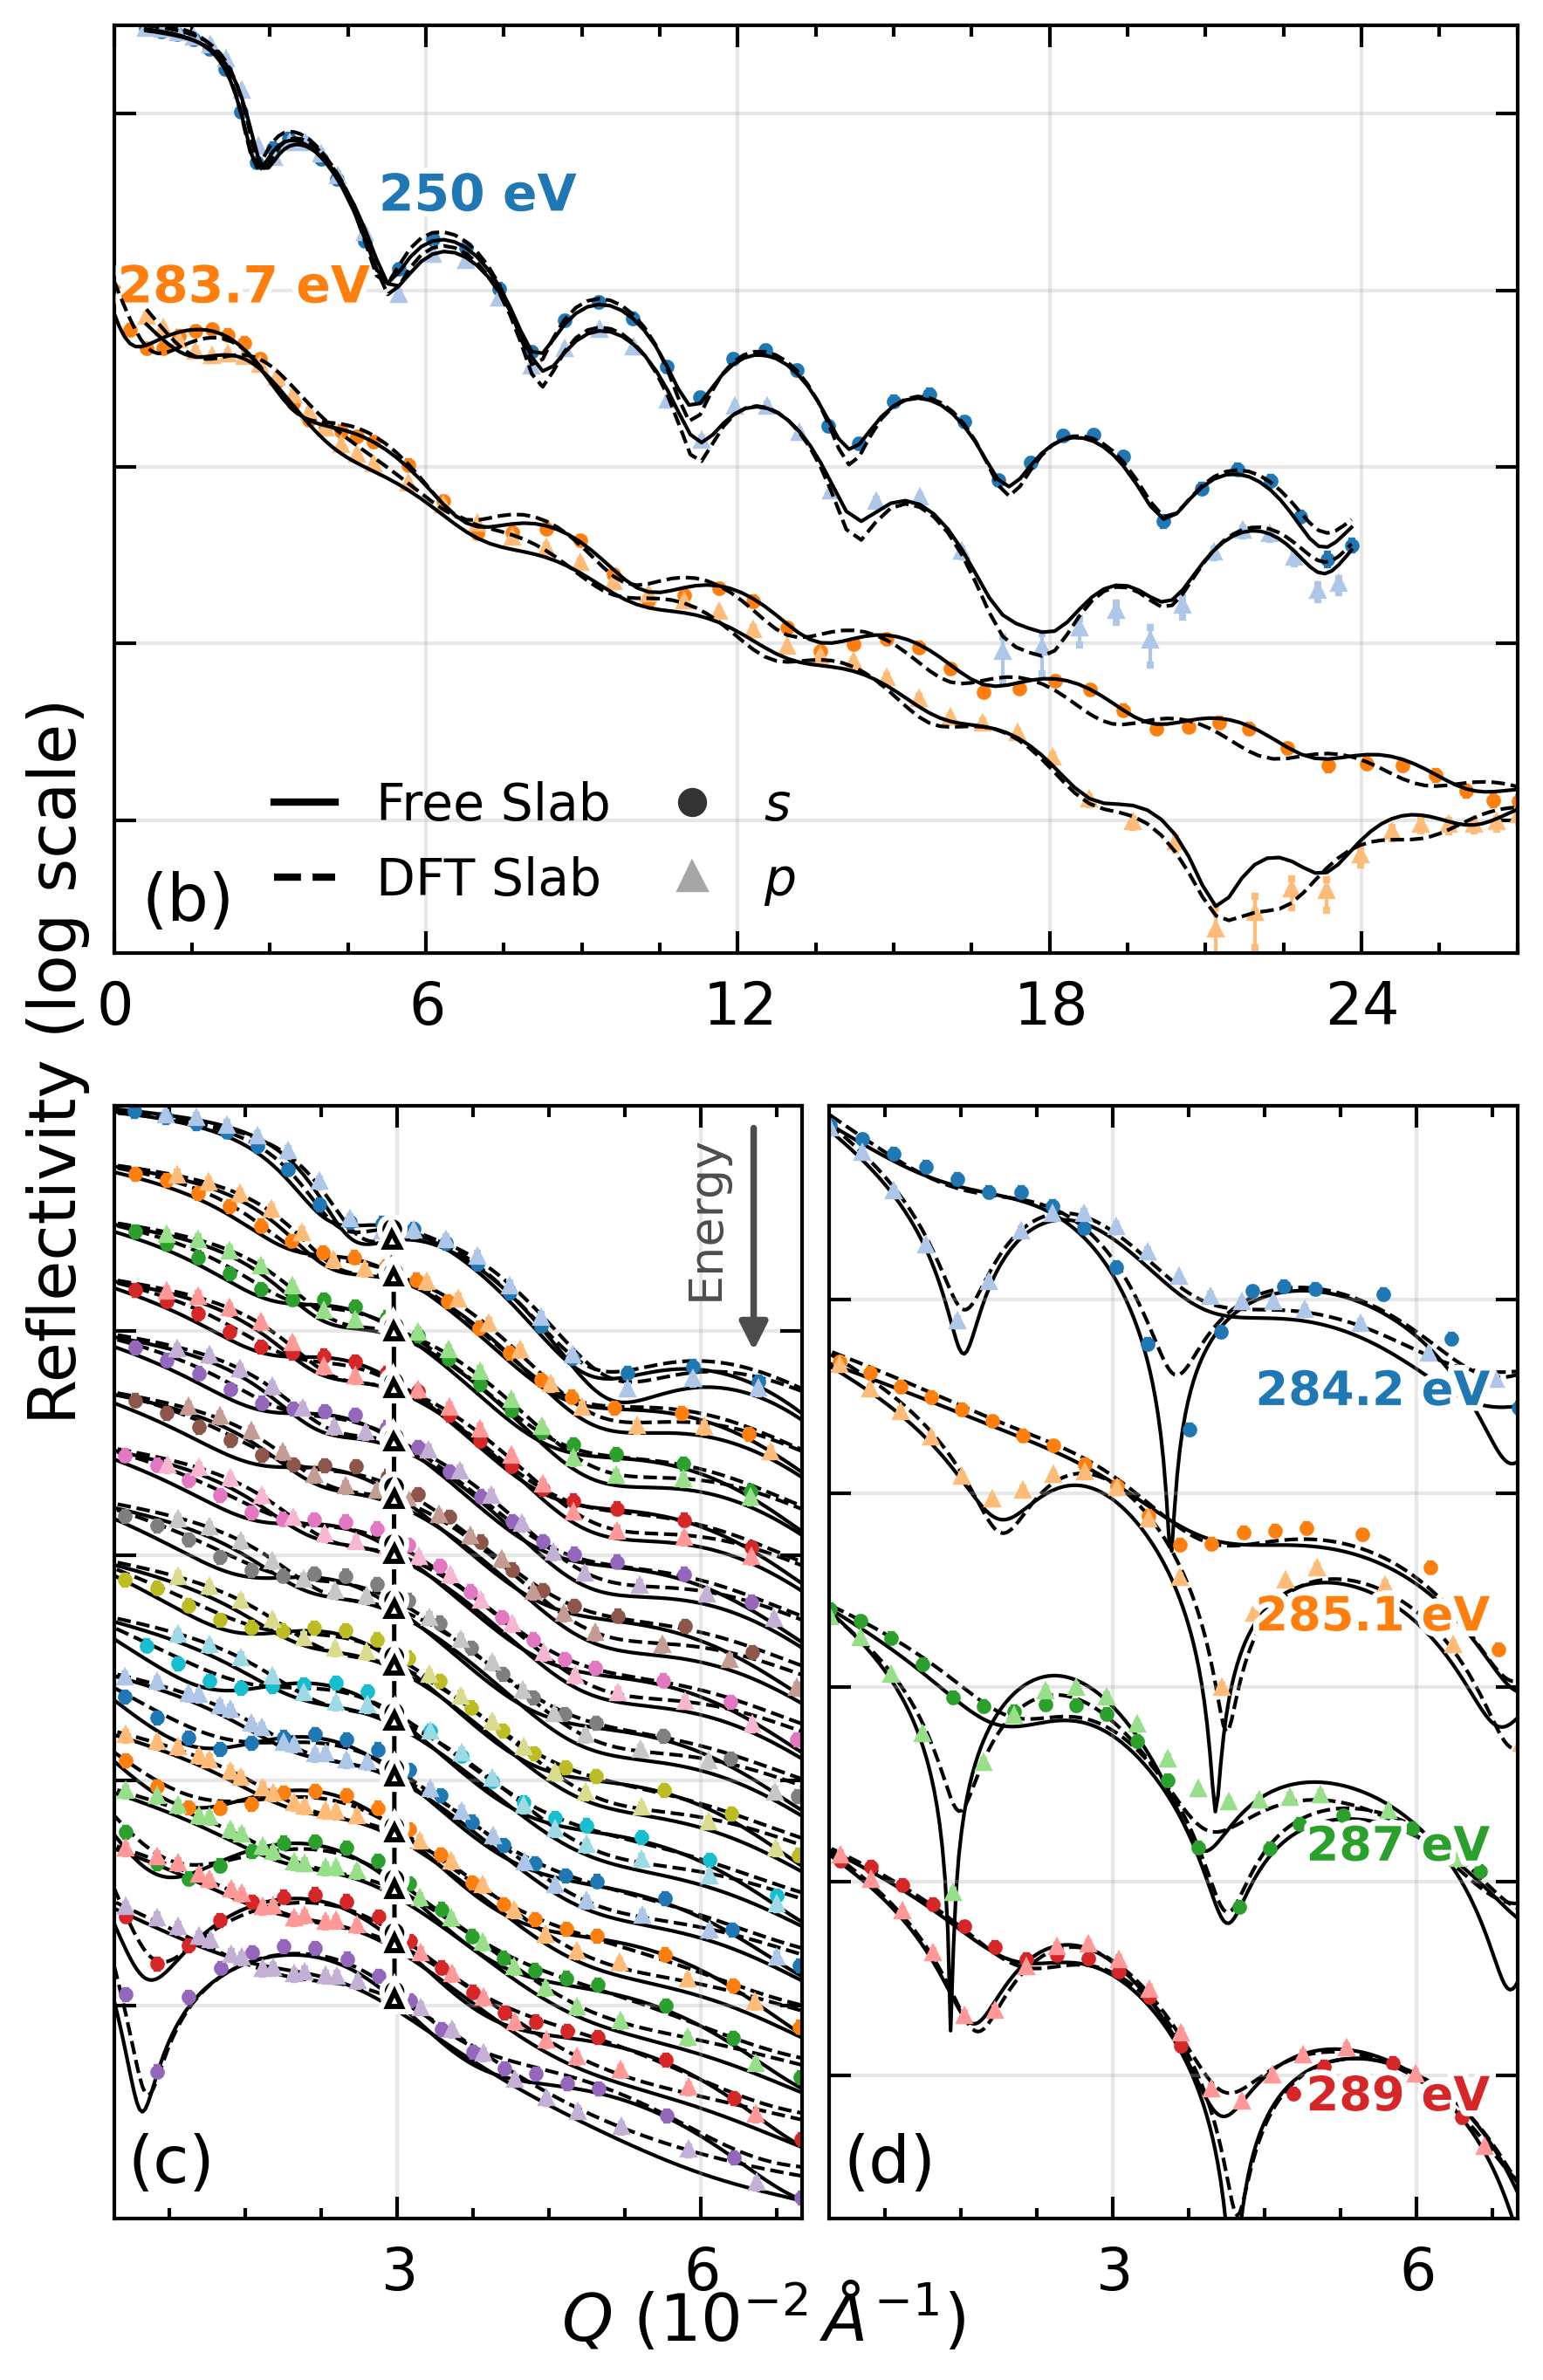

In [17]:
_ = plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path="fig2_xrr_model_comparison.png",
    **_common_kwargs,
)

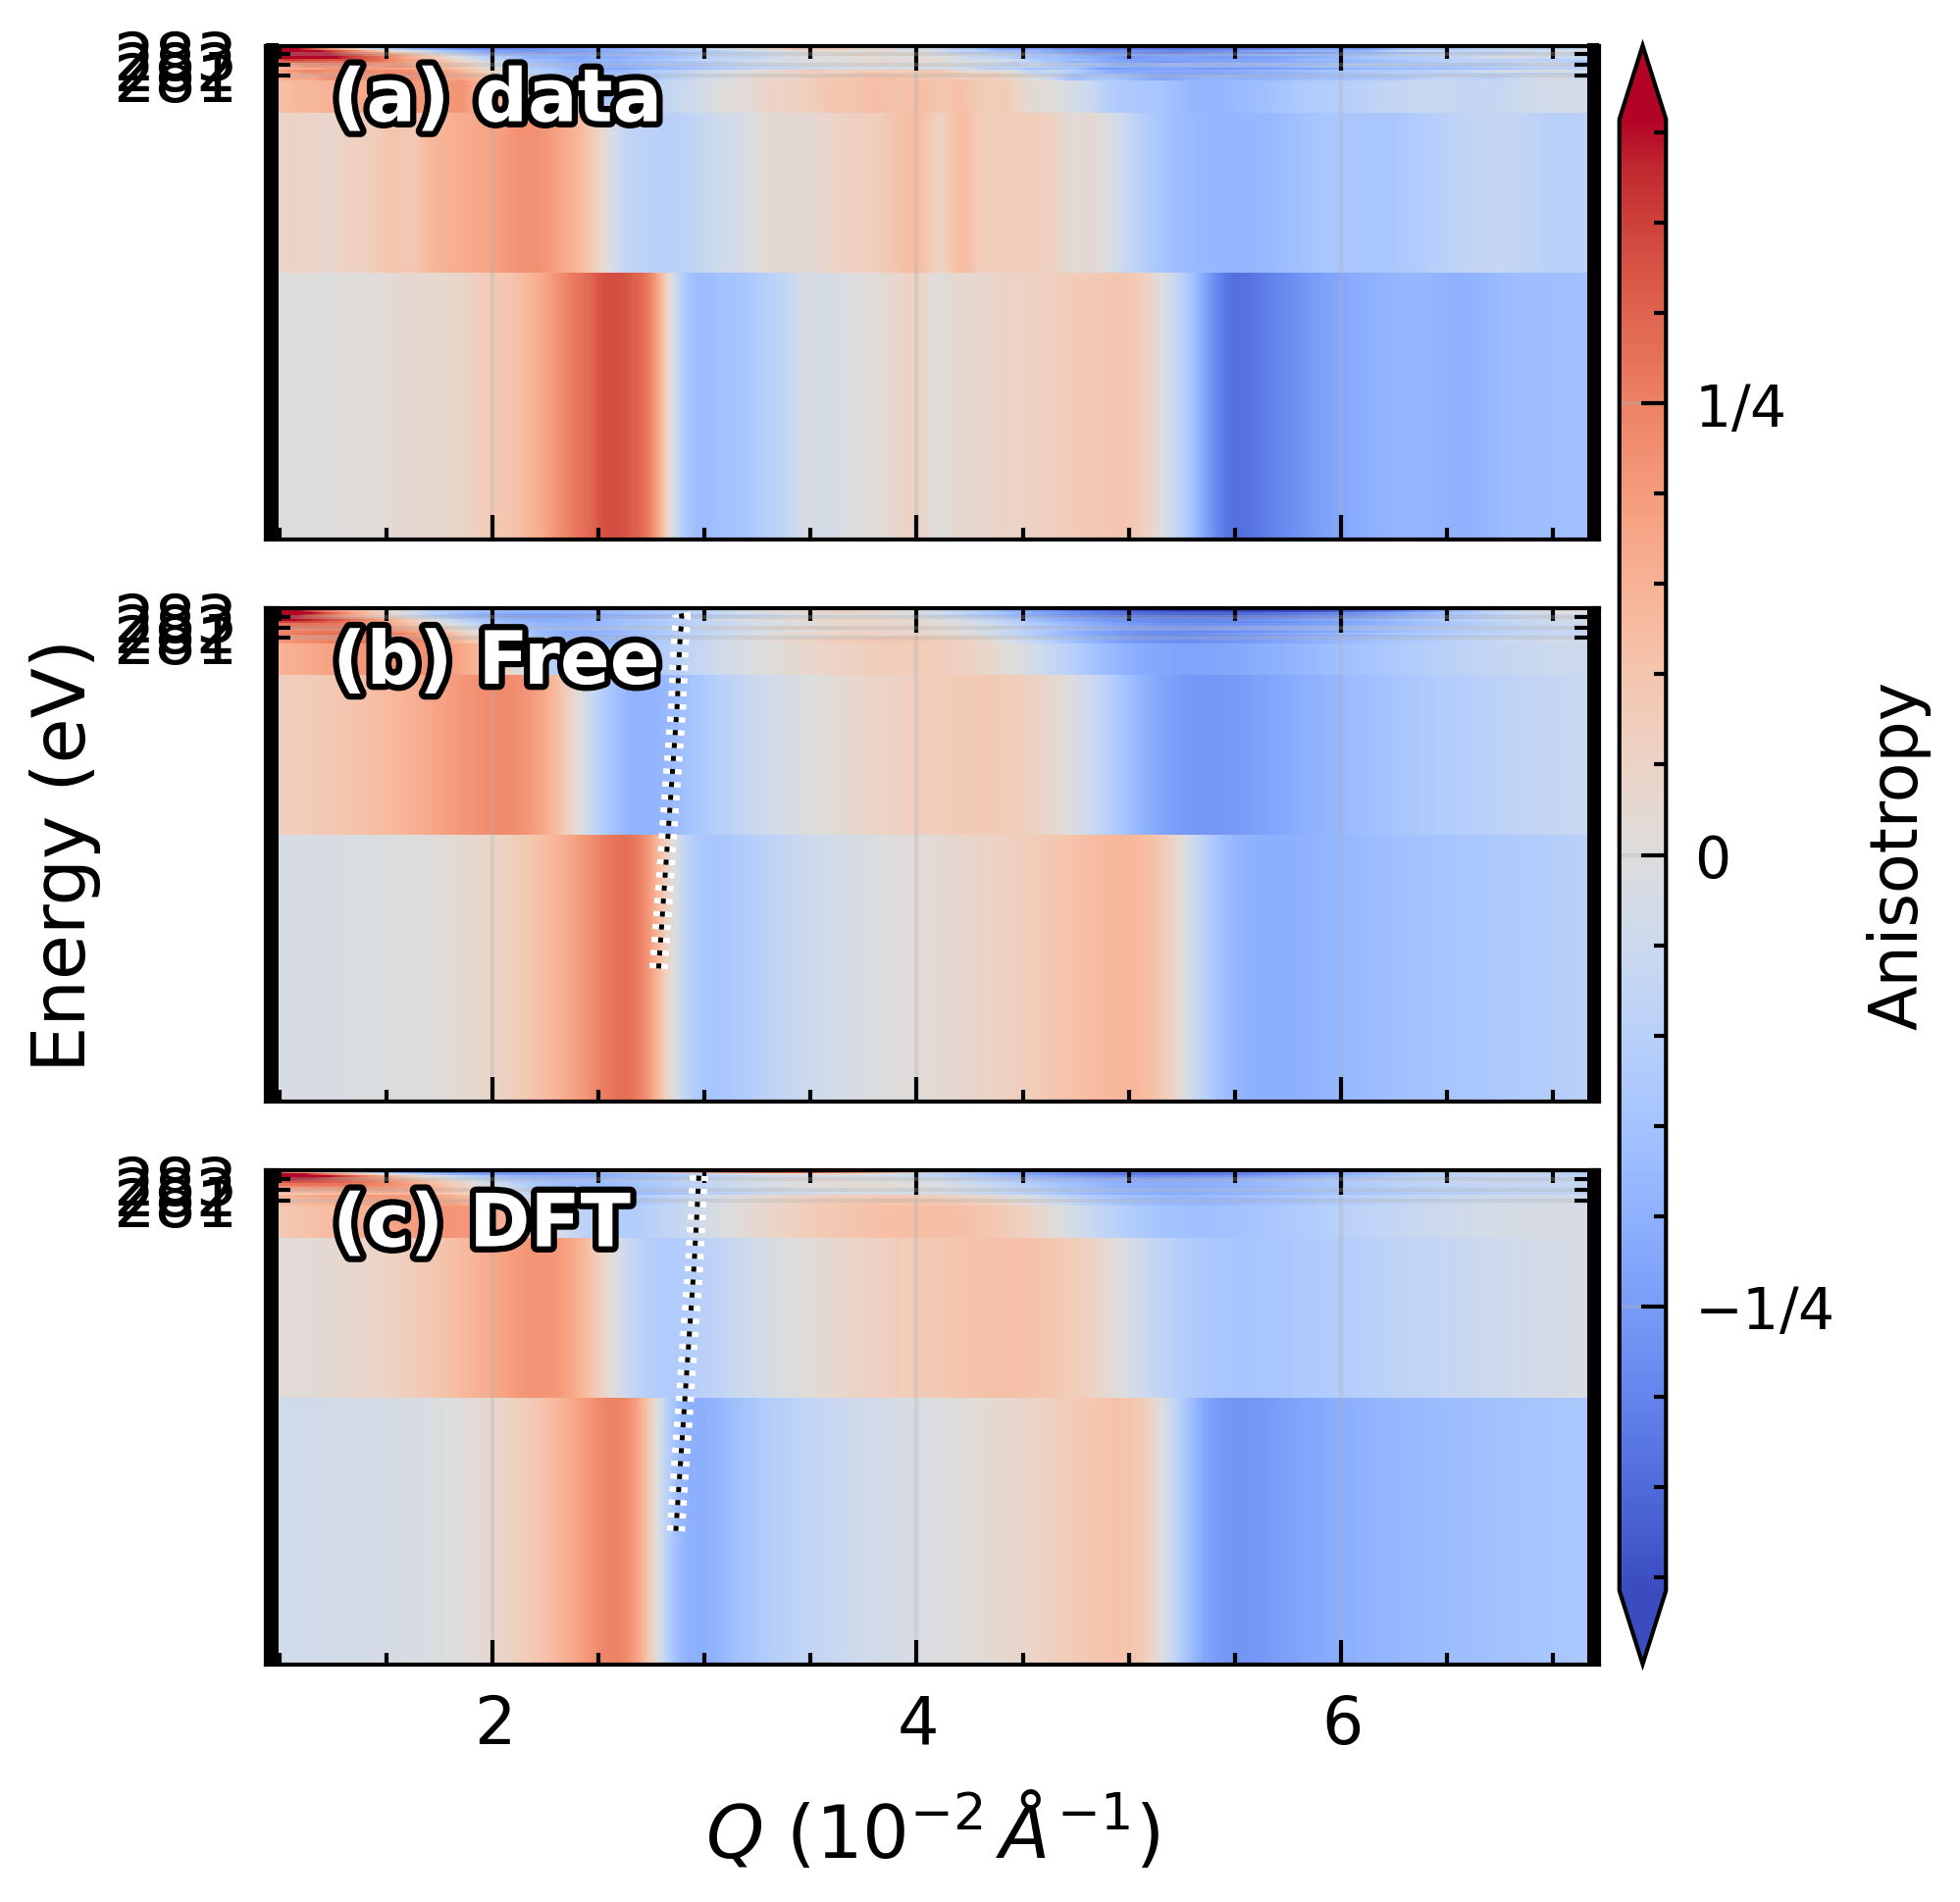

In [18]:
plot_anisotropy_maps_si(
    exp_constrained,
    dft_constrained,
    loaded_data,
    aniso_y_ticks=(281.0, 282.0, 283.0, 284),
    qc_map_markersize=1,
    qc_overlay_style="none",
    # qc_color="blue",
    save_path="fig_si4_anis_maps.pdf"
)

In [19]:
# quickly get the errors on the exp_constrained model since they are missing
import pyref.fitting as fit

# lock down all optical constants and just fit the thickness and roughness
# for the 16th objective

for obj in exp_constrained.objectives:
    obj.model.scale_p.vary = False
    obj.model.scale_s.vary = False
    obj.model.theta_offset_p.vary = False
    obj.model.theta_offset_s.vary = False
    for i, layer in enumerate(obj.model.structure):
        for param in layer.sld.parameters:
            param.constraint = None
            param.vary = False
        if obj.model.energy == 283.7 and i not in (0, len(obj.model.structure) - 1):
            layer.thick.vary = True
            layer.rough.vary = True
        else:
            layer.thick.constraint = None
            layer.rough.constraint = None
            layer.thick.vary = False
            layer.rough.vary = False

print(exp_constrained.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=9.98852          , bounds=[0.0, 11.063088443158598]>
<Parameter:'Surface_283.7_rough', value=6.22017          , bounds=[0.0, 8.823241700973194]>
<Parameter:'ZnPc_283.7_thick', value=180.554          , bounds=[0.0, 366.64515820320634]>
<Parameter:'ZnPc_283.7_rough', value=12.302          , bounds=[0.0, 25.63714312600566]>
<Parameter:'Contamination_283.7_thick', value=11.0031          , bounds=[0.0, 23.004580898001063]>
<Parameter:'Contamination_283.7_rough', value=7.53376          , bounds=[0.0, 8.389984715886504]>
<Parameter:'Oxide_283.7_thick', value=8.83717          , bounds=[5.0, 12.0]>
<Parameter:'Oxide_283.7_rough', value=5.09216          , bounds=[0.0, 8.0]>


In [20]:
fitter_quick = fit.CurveFitter(exp_constrained)
fitter_quick.fit(method="L-BFGS-B")

19.782165331700966: : 28it [00:08,  3.32it/s]


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 19.782165331700966
        x: [ 8.843e+00  7.205e+00  1.744e+02  1.043e+01  1.448e+01
             8.390e+00  1.077e+01  4.847e+00]
      nit: 28
      jac: [ 4.619e-06  7.461e-06  3.553e-07 -7.461e-06 -1.350e-05
            -1.053e-01 -9.805e-05 -6.786e-05]
     nfev: 270
     njev: 30
 hess_inv: <8x8 LbfgsInvHessProduct with dtype=float64>
    covar: [[ 1.866e-01  1.220e-02 ...  1.283e-02 -5.029e-03]
            [ 1.220e-02  7.860e-02 ...  7.507e-03 -1.645e-03]
            ...
            [ 1.283e-02  7.507e-03 ...  3.592e-02 -1.250e-02]
            [-5.029e-03 -1.645e-03 ... -1.250e-02  5.251e-03]]
   stderr: [ 4.320e-01  2.804e-01  4.166e-01  3.080e-01  2.391e-01
             1.528e-01  1.895e-01  7.246e-02]

In [21]:
print(fitter_quick.objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=8.84345 +/- 0.432, bounds=[0.0, 11.063088443158598]>
<Parameter:'Surface_283.7_rough', value=7.20481 +/- 0.28 , bounds=[0.0, 8.823241700973194]>
<Parameter:'ZnPc_283.7_thick', value=174.431 +/- 0.417, bounds=[0.0, 366.64515820320634]>
<Parameter:'ZnPc_283.7_rough', value=10.4349 +/- 0.308, bounds=[0.0, 25.63714312600566]>
<Parameter:'Contamination_283.7_thick', value=14.4787 +/- 0.239, bounds=[0.0, 23.004580898001063]>
<Parameter:'Contamination_283.7_rough', value=8.38998 +/- 0.153, bounds=[0.0, 8.389984715886504]>
<Parameter:'Oxide_283.7_thick', value=10.7655 +/- 0.19 , bounds=[5.0, 12.0]>
<Parameter:'Oxide_283.7_rough', value=4.84669 +/- 0.0725, bounds=[0.0, 8.0]>


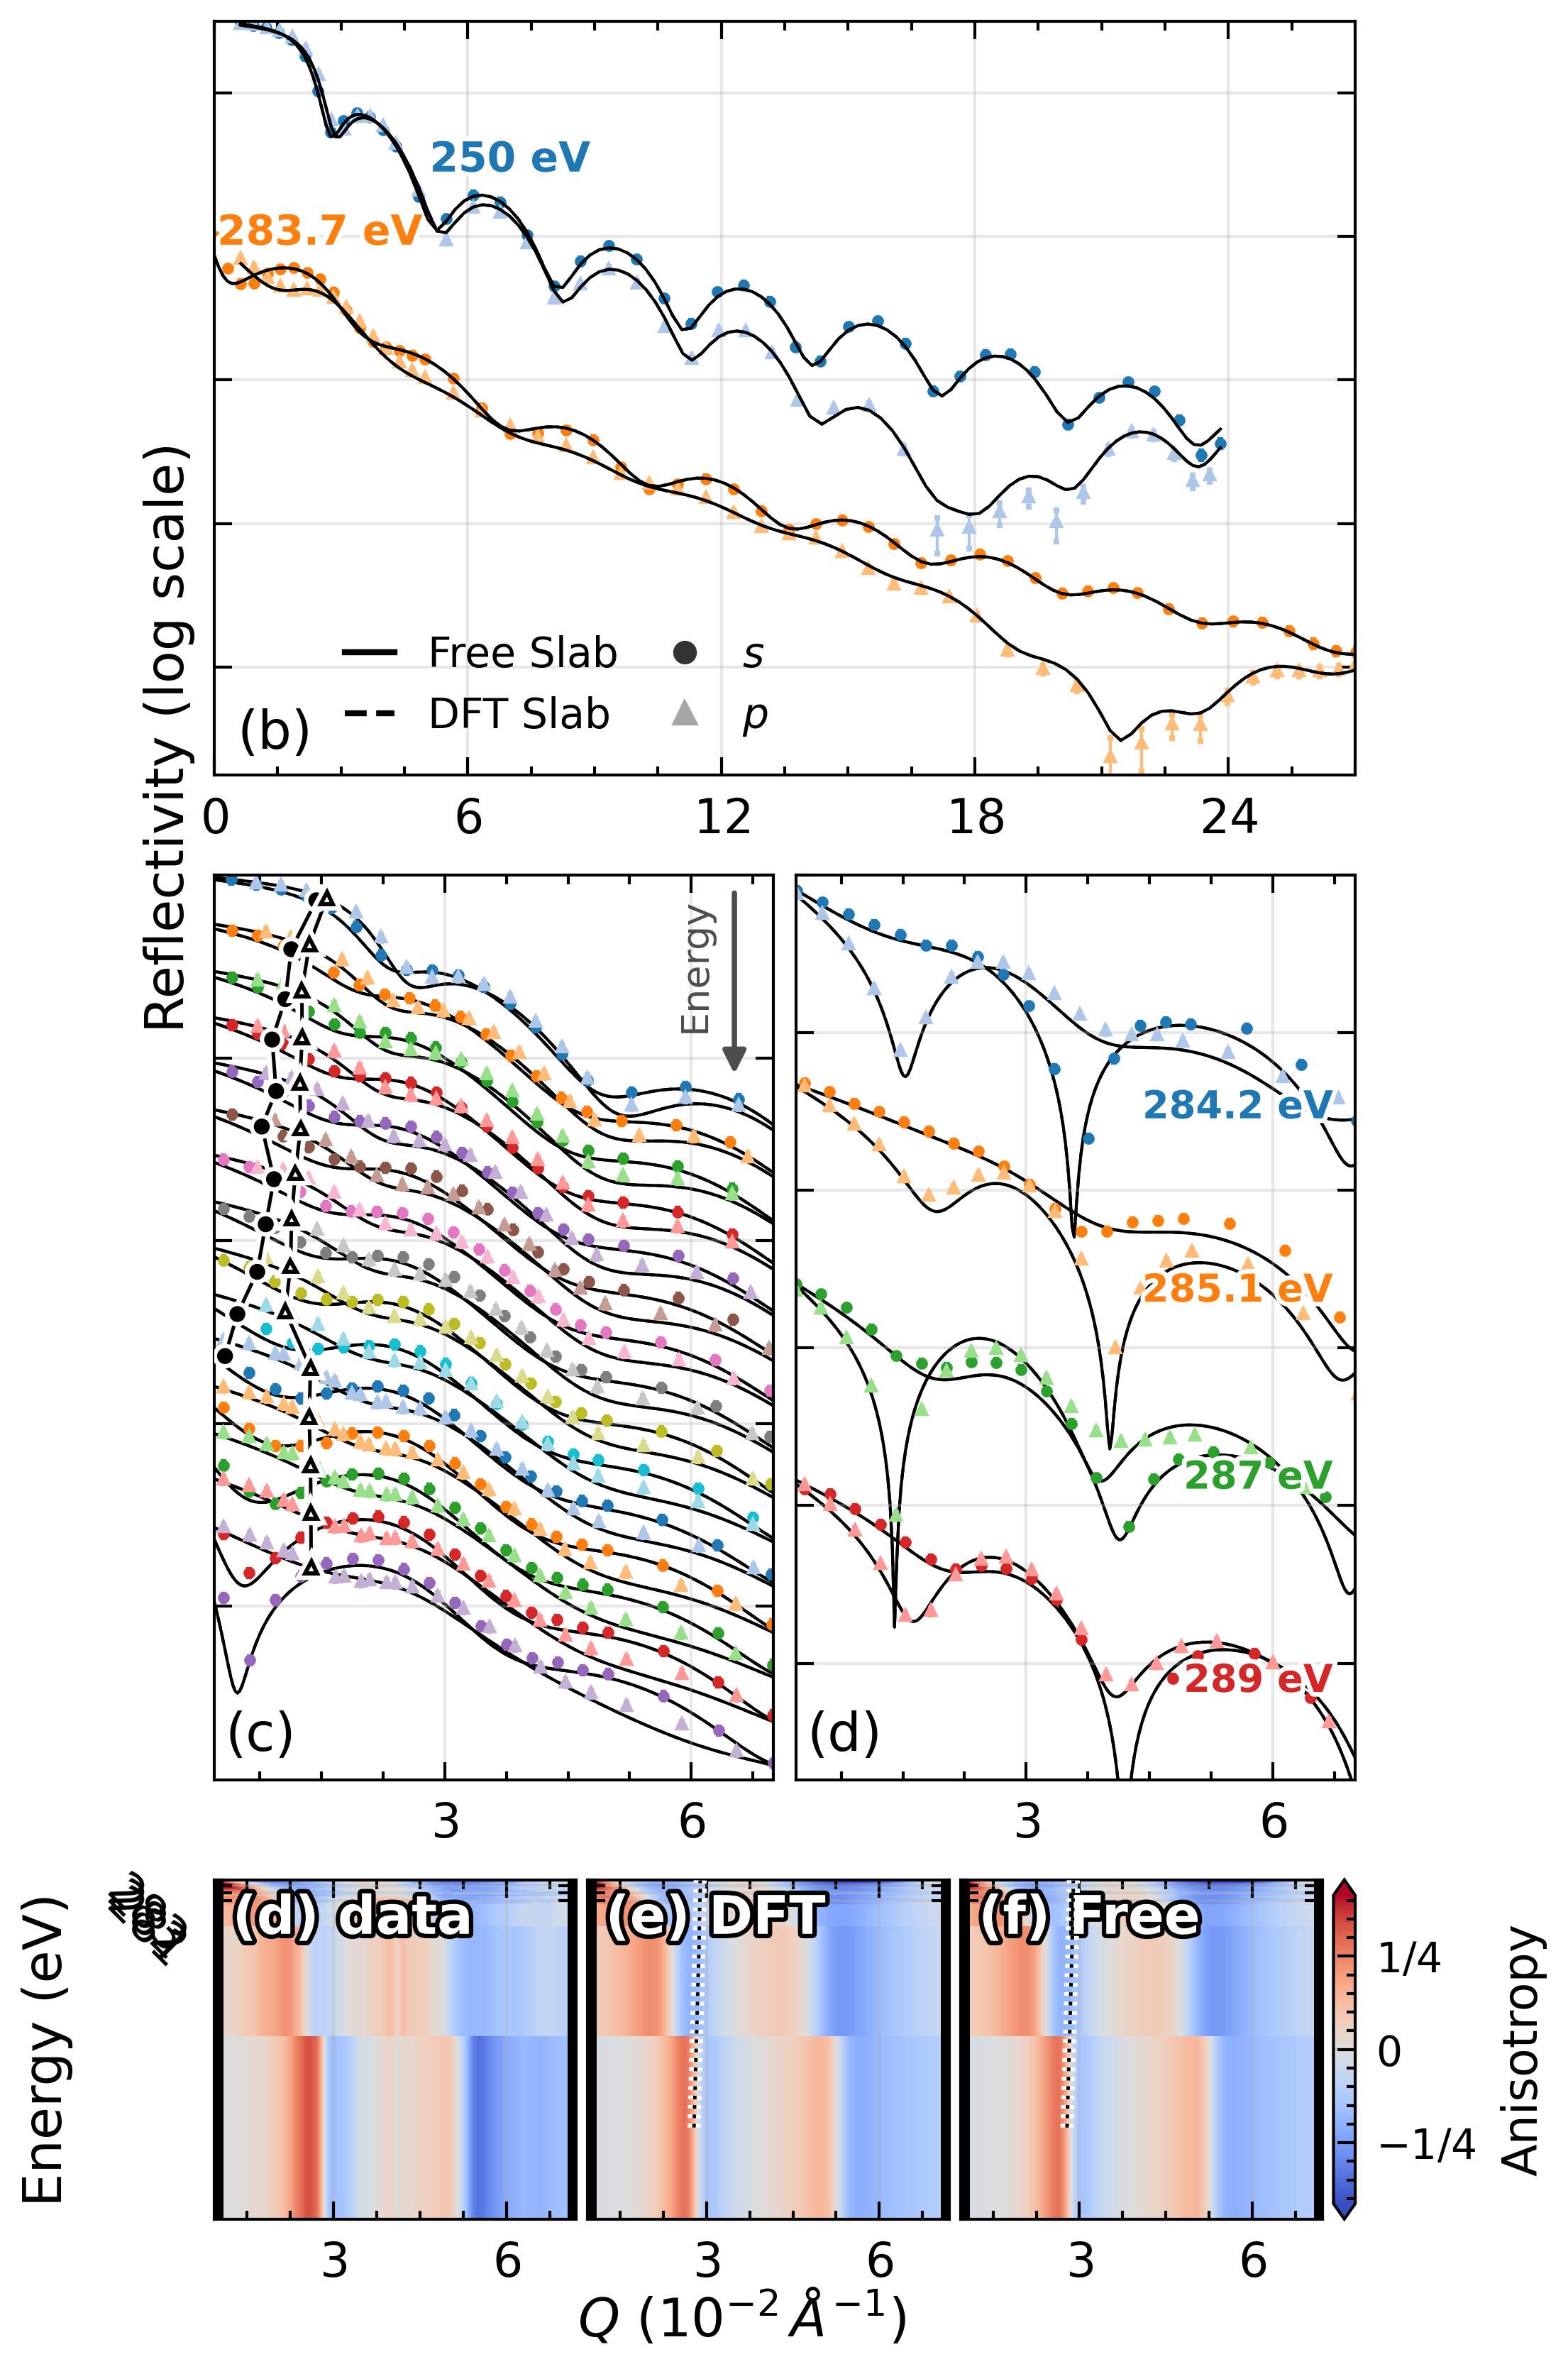

In [22]:
_ = plot_all_results(
    exp_constrained,
    fitter_quick.objective,
    loaded_data,
    show_energy_labels=True,
    aniso_y_ticks=(281.0, 282.0, 283.0, 284),
    show_qc_s_in_b=True,
    show_qc_p_in_b=True,
    show_qc_s_in_c=False,
    show_qc_p_in_c=False,
    qc_s_connect="-",
    qc_p_connect="-",
    qc_connect_linewidth=0.6,
    qc_waterfall_markersize=2,
    qc_map_markersize=1,
    qc_overlay_style="none",
    # qc_color="blue",
    save_path=None, #"fig2_xrr_model_comparison.png"
)

In [23]:
def to_ufloat(param):
    from uncertainties import ufloat
    return ufloat(param.value, param.stderr if param.stderr else 0)

def export_table(obj):
    from uncertainties import ufloat
    dfs = []
    for layer in obj.model.structure:
        df = {
            "name": layer.name,
            "thickness": to_ufloat(layer.thick),
            "rough": to_ufloat(layer.rough),
        }
        dfs.append(df)
    return pd.DataFrame(dfs)


display(export_table(exp_constrained.objectives[16]))
display(export_table(dft_constrained.objectives[16]))

/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,name,thickness,rough
0,Vacuum_283.7,0.0+/-0,0.0+/-0
1,Surface_283.7,8.8+/-0.4,7.20+/-0.28
2,ZnPc_283.7,174.4+/-0.4,10.43+/-0.31
3,Contamination_283.7,14.48+/-0.24,8.39+/-0.15
4,Oxide_283.7,10.77+/-0.19,4.85+/-0.07
5,Substrate_283.7,0.0+/-0,1.2+/-0


/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,name,thickness,rough
0,Vacuum_283.7,0.0+/-0,0.0+/-0
1,Surface_283.7,8.9335+/-0.0004,7.0560+/-0.0011
2,ZnPc_283.7,179.951+/-0.029,13.1363+/-0.0024
3,Contamination_283.7,10.7048+/-0.0031,7.8924+/-0.0005
4,Oxide_283.7,6.87941+/-0.00024,8.1267+/-0.0015
5,Substrate_283.7,0.0+/-0,1.2+/-0


In [24]:
exp_table = export_table(exp_constrained.objectives[16])
dft_table = export_table(dft_constrained.objectives[16])
print(
exp_table["thickness"].sum(),
dft_table["thickness"].sum(),
exp_table["thickness"].sum() - dft_table["thickness"].sum())

208.5+/-0.7 206.469+/-0.029 2.0+/-0.7


/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [25]:
surf = dft_constrained.objectives[16].model.structure[1].sld
bulk = dft_constrained.objectives[16].model.structure[2].sld
inter = dft_constrained.objectives[16].model.structure[3].sld
print(to_ufloat(surf.rotation)*180/np.pi, to_ufloat(bulk.rotation)*180/np.pi, to_ufloat(inter.rotation)*180/np.pi)
print(to_ufloat(surf.density), to_ufloat(bulk.density), to_ufloat(inter.density))

52.208+/-0.007 69.539+/-0.011 47.241+/-0.009
1.80+/-0.35 1.63852+/-0.00027 1.80+/-0.33


In [26]:
# quickly get the errors on the exp_constrained model since they are missing
import pyref.fitting as fit

# lock down all optical constants and just fit the thickness and roughness
# for the 16th objective

for obj in dft_constrained.objectives:
    obj.model.scale_p.vary = False
    obj.model.scale_s.vary = False
    obj.model.theta_offset_p.vary = False
    obj.model.theta_offset_s.vary = False
    obj.model.energy_offset.constraint = None
    obj.model.energy_offset.vary = False
    for i, layer in enumerate(obj.model.structure):
        for param in layer.sld.parameters:
            param.constraint = None
            param.vary = False
        if obj.model.energy == 283.7 and i not in (0, len(obj.model.structure) - 1, len(obj.model.structure) - 2):
            layer.thick.vary = True
            layer.rough.vary = True
            print(layer.sld.rotation)
            print(layer.sld.density)
        elif obj.model.energy == 283.7 and i == len(obj.model.structure) - 2:
            layer.thick.value = exp_constrained.objectives[16].model.structure[i].thick.value
            layer.thick.vary = False
            layer.rough.value = exp_constrained.objectives[16].model.structure[i].rough.value
            layer.rough.vary = False
        else:
            layer.thick.constraint = None
            layer.rough.constraint = None
            layer.thick.vary = False
            layer.rough.vary = False

print(dft_constrained.varying_parameters())

<Parameter:'Surface_283.7_rotation', value=0.911197  (fixed) , bounds=[0.0, 1.5707963267948966]>
<Parameter:'Surface_283.7_density', value=1.8  (fixed) , bounds=[1.0, 1.8]>
<Parameter:'ZnPc_283.7_rotation', value=1.21368  (fixed) , bounds=[0.0, 1.5707963267948966]>
<Parameter:'ZnPc_283.7_density', value=1.63852  (fixed) , bounds=[1.2, 1.8]>
<Parameter:'Contamination_283.7_rotation', value=0.824519  (fixed) , bounds=[0.0, 1.5707963267948966]>
<Parameter:'Contamination_283.7_density', value=1.8  (fixed) , bounds=[1.0, 1.8]>
________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=8.93351 +/- 0.000448, bounds=[0.0, 35.0]>
<Parameter:'Surface_283.7_rough', value=7.05602 +/- 0.00108, bounds=[0.0, 25.0]>
<Parameter:'ZnPc_283.7_thick', value=179.951 +/- 0.0291, bounds=[160.0, 200.0]>
<Parameter:'ZnPc_283.7_rough', value=13.1363 +/- 0.00243, bounds=[0.0, 25.0]>
<Parameter:'Contamination_283.7_thick', va

12.908988617974607: : 14it [00:05,  2.35it/s]


________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=6.89255 +/- 0.306, bounds=[0.0, 35.0]>
<Parameter:'Surface_283.7_rough', value=6.9725 +/- 0.182, bounds=[0.0, 25.0]>
<Parameter:'ZnPc_283.7_thick', value=175.405 +/- 0.343, bounds=[160.0, 200.0]>
<Parameter:'ZnPc_283.7_rough', value=9.67259 +/- 0.207, bounds=[0.0, 25.0]>
<Parameter:'Contamination_283.7_thick', value=8.34156 +/- 0.161, bounds=[0.0, 35.0]>
<Parameter:'Contamination_283.7_rough', value=8.83083 +/- 0.192, bounds=[0.0, 25.0]>


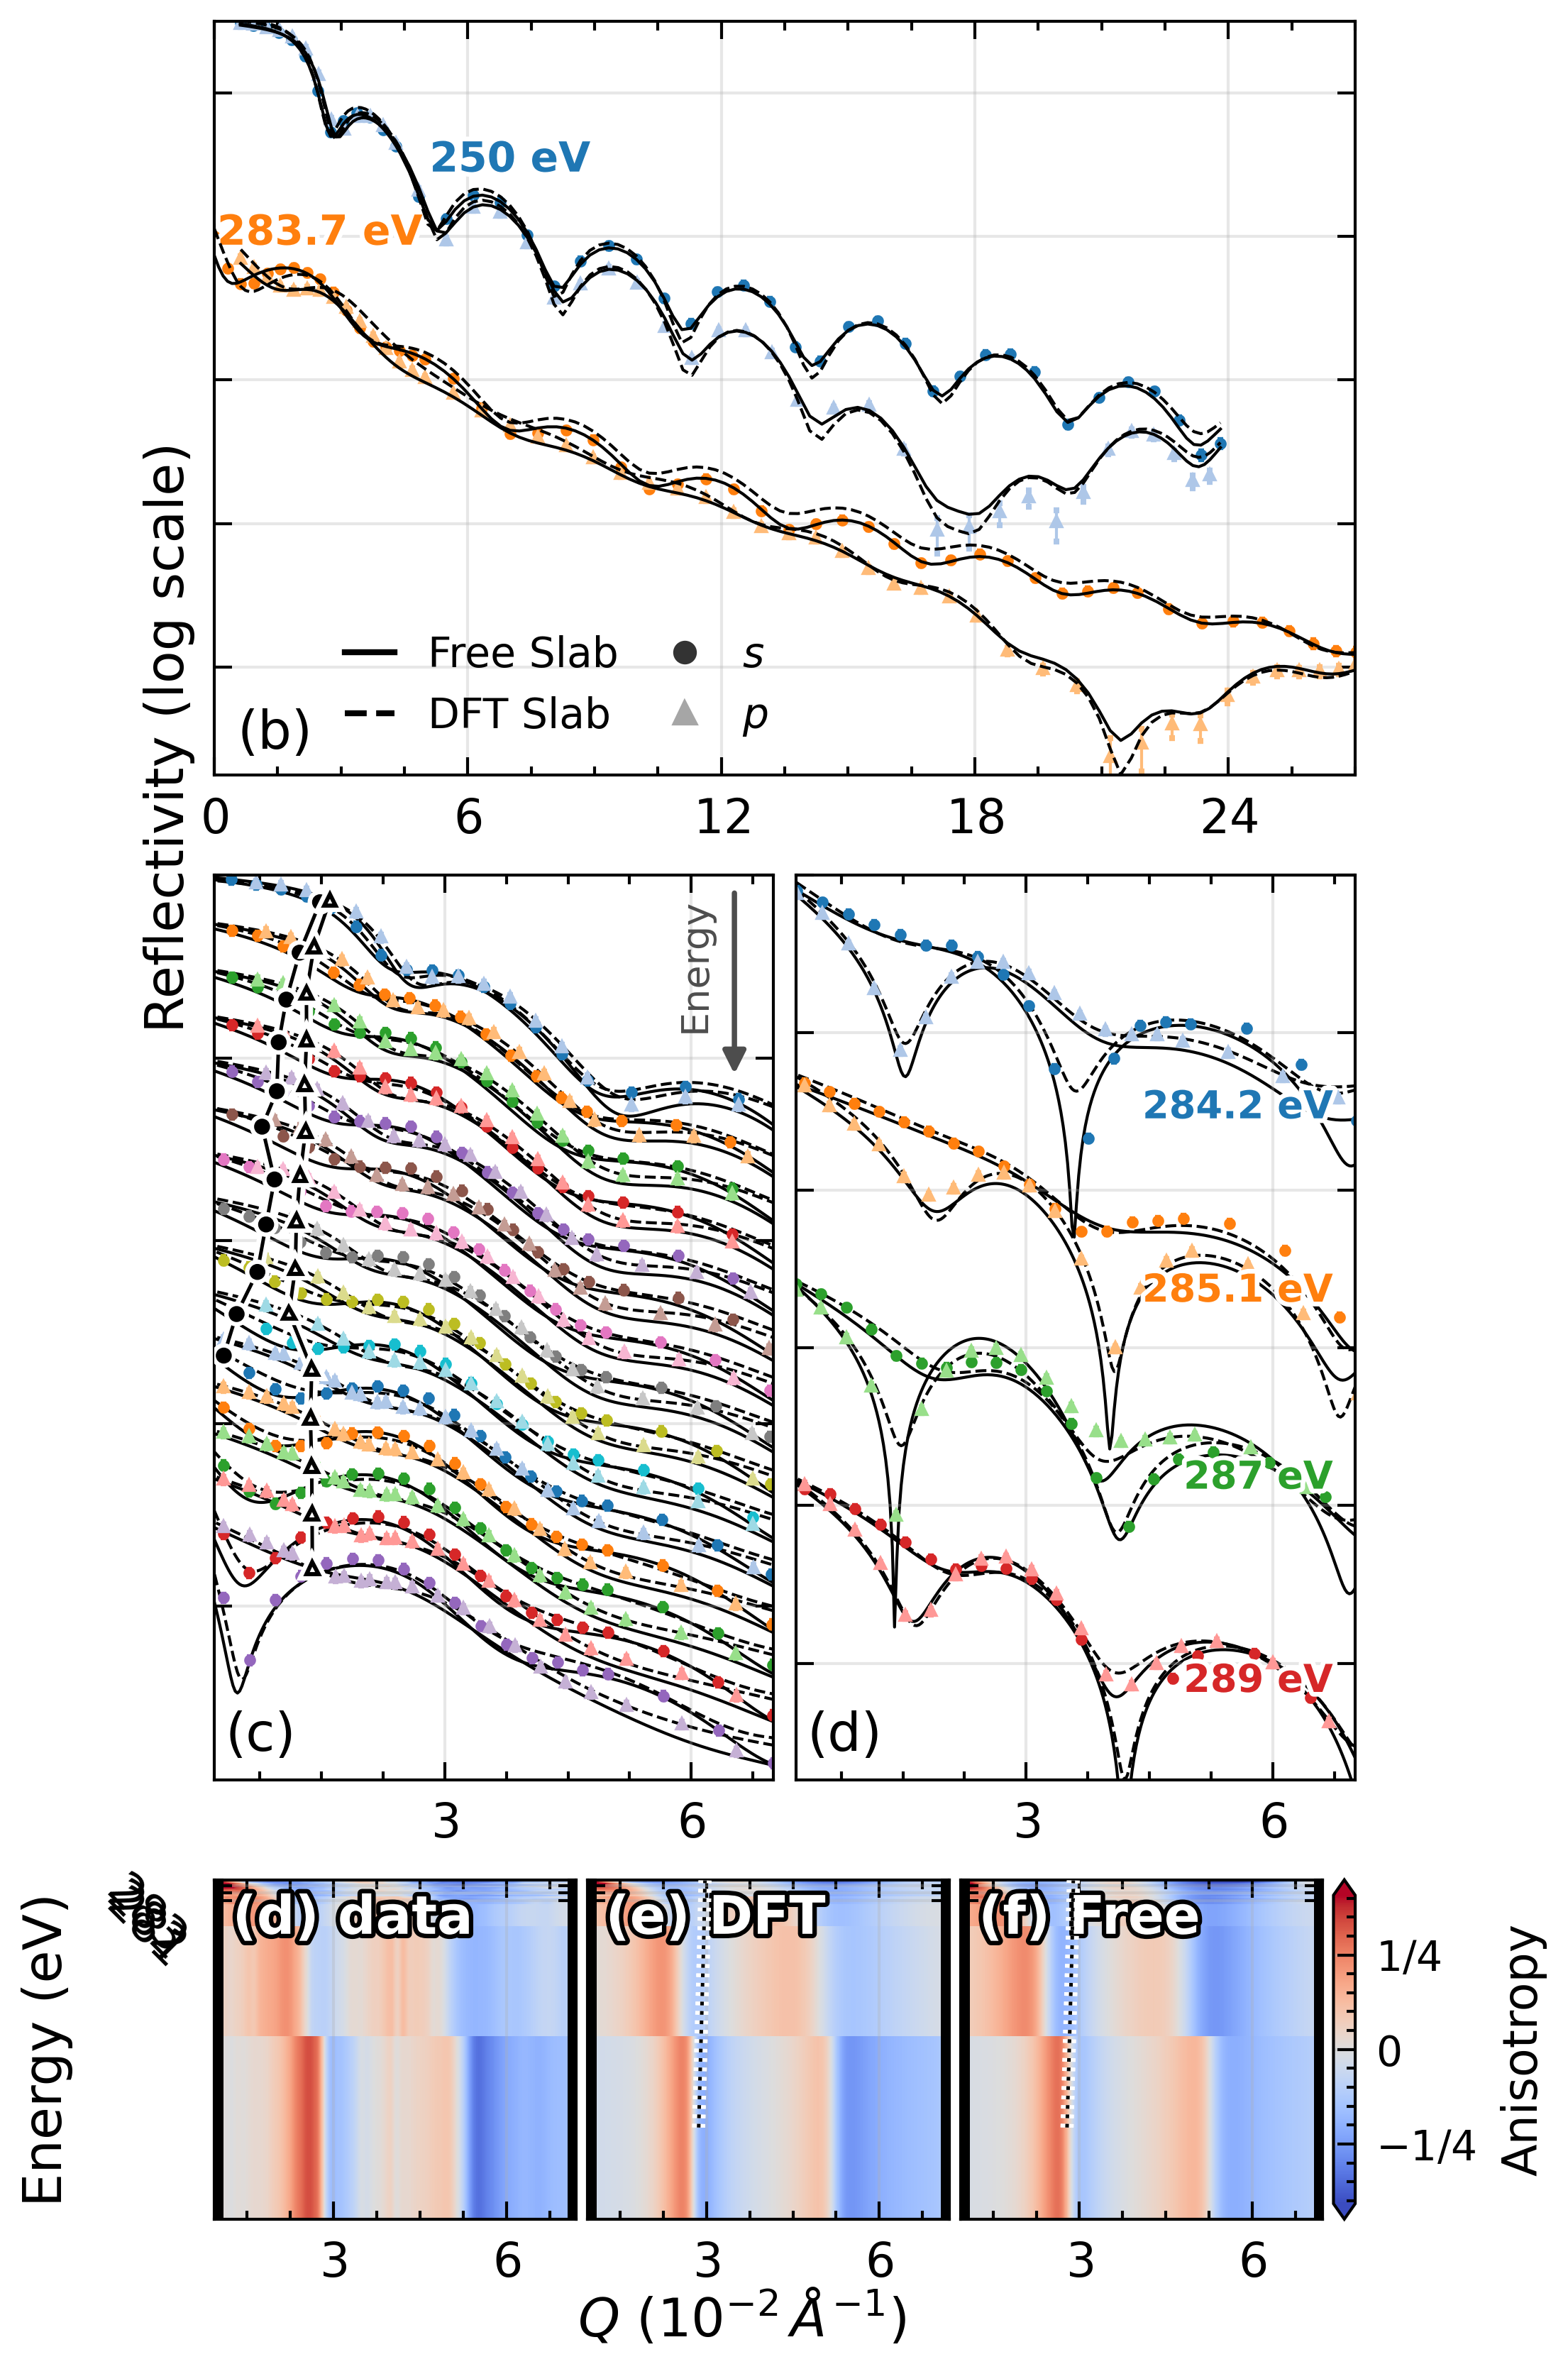

In [27]:
quick_dft = fit.CurveFitter(dft_constrained)
quick_dft.fit(method="L-BFGS-B")
print(quick_dft.objective.varying_parameters())
_ = plot_all_results(
    exp_constrained,
    quick_dft.objective,
    loaded_data,
    show_energy_labels=True,
    aniso_y_ticks=(281.0, 282.0, 283.0, 284),
    show_qc_s_in_b=True,
    show_qc_p_in_b=True,
    show_qc_s_in_c=False,
    show_qc_p_in_c=False,
    qc_s_connect="-",
    qc_p_connect="-",
    qc_connect_linewidth=0.6,
    qc_waterfall_markersize=2,
    qc_map_markersize=1,
    qc_overlay_style="none",
    # qc_color="blue",
    save_path=None, #"fig2_xrr_model_comparison.png"
)

## Refloxide comparison (new)

Adds the refloxide multi-energy UniTensorSLD fit (`refloxide/examples/real_data_repl.py`,
seeded from the free-tensor model's own geometry) as a fourth reflectivity trace at a
few representative energies, using the SAME `rxr(x, model, pol)` helper defined above
via `utils.refloxide_view` -- a small read-only adapter (NOT a full pyref API
replacement, see that module's docstring) that lets this repo's own `rxr` helper treat
the refloxide fit exactly like the pyref-based DFT/Free ones above.

In [28]:
from utils import models_root
from utils.refloxide_view import load_refloxide_fit, objective_view_at

REFLOXIDE_FIT_PATH = models_root / "xrr/znpc/refloxide/refit-refloxide.pkl"
if not REFLOXIDE_FIT_PATH.exists():
    raise FileNotFoundError(
        f"missing {REFLOXIDE_FIT_PATH} -- run refloxide/examples/real_data_repl.py "
        "(through the CurveFitter.fit cell) first to produce this pickle"
    )

refloxide_objective = load_refloxide_fit(REFLOXIDE_FIT_PATH)
print(
    f"loaded refloxide fit: {len(refloxide_objective.varying_parameters())} "
    "varying parameters"
)


def _nearest_objective(bundle, energy):
    """Objective in a pyref GlobalObjective whose model.energy is closest to `energy`."""
    energies = [float(o.model.energy) for o in bundle.objectives]
    idx = min(range(len(energies)), key=lambda i: abs(energies[i] - energy))
    return bundle.objectives[idx]


loaded refloxide fit: 98 varying parameters


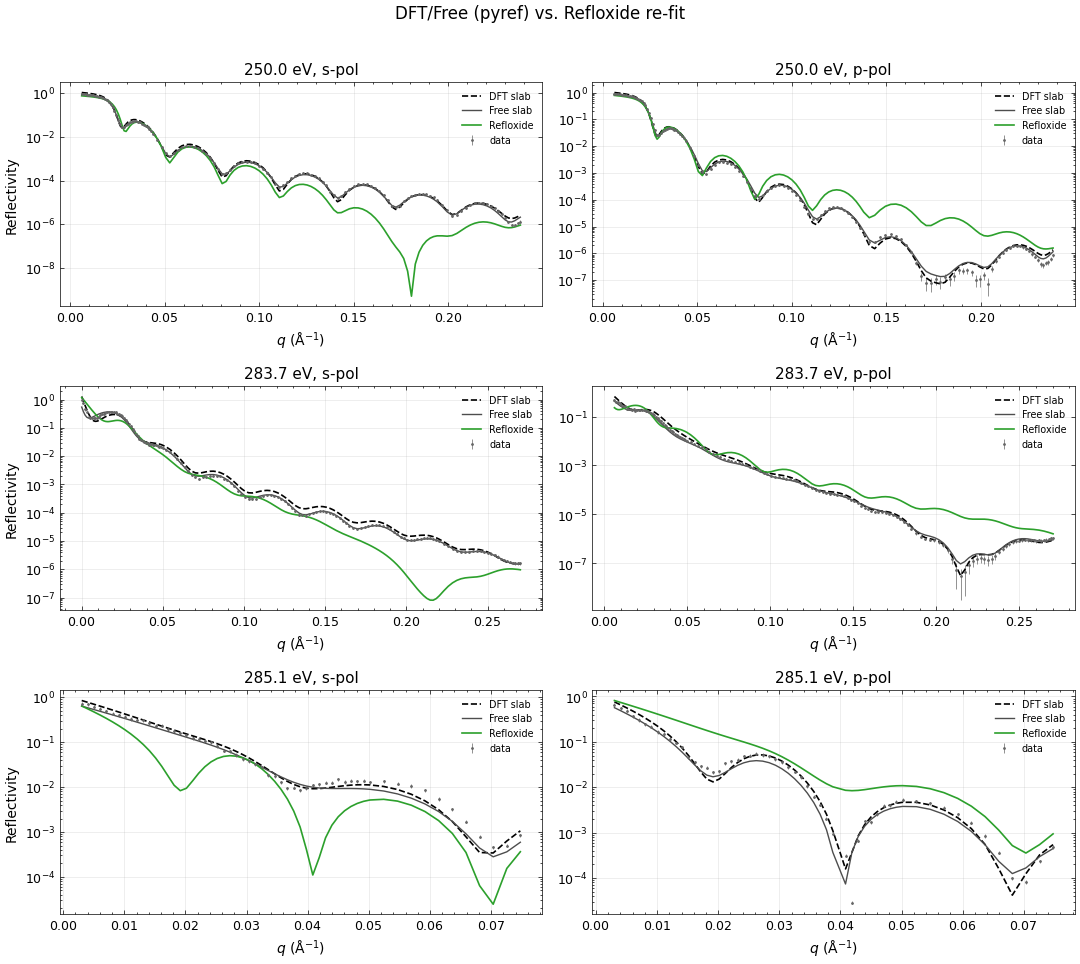

In [29]:
show_energies = (250.0, 283.7, 285.1)
fig, axes = plt.subplots(len(show_energies), 2, figsize=(11, 3.2 * len(show_energies)))
for row, energy in enumerate(show_energies):
    data = loaded_data[str(energy)]
    refloxide_view = objective_view_at(refloxide_objective, energy)
    dft_obj_e = _nearest_objective(dft_constrained, energy)
    free_obj_e = _nearest_objective(exp_constrained, energy)
    for col, pol in enumerate(("s", "p")):
        ax = axes[row, col]
        d = getattr(data, pol)
        ax.errorbar(
            d.x, d.y, yerr=d.y_err, fmt=".", ms=2, lw=0.5, color="0.4", label="data"
        )
        ax.plot(d.x, rxr(d.x, dft_obj_e.model, pol), color="k", ls="--", lw=1.2, label="DFT slab")
        ax.plot(d.x, rxr(d.x, free_obj_e.model, pol), color="0.3", ls="-", lw=1.0, label="Free slab")
        ax.plot(
            d.x, rxr(d.x, refloxide_view.model, pol),
            color="tab:green", lw=1.2, label="Refloxide",
        )
        ax.set_yscale("log")
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
        ax.set_title(f"{energy:.1f} eV, {pol}-pol")
        if col == 0:
            ax.set_ylabel("Reflectivity")
        ax.legend(fontsize="x-small")
fig.suptitle("DFT/Free (pyref) vs. Refloxide re-fit", y=1.01)
fig.tight_layout()
fig.savefig("figures/fig2_with_refloxide.png", dpi=200, bbox_inches="tight")
plt.show()
